<a href="https://colab.research.google.com/github/eisbetterthanpi/hopfield-networks/blob/main/hopfield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title notes

want dist bet x/hssm and all_x, all_hssm

Hopfield Lookup via HopfieldLayer
https://ml-jku.github.io/hopfield-layers/
dynamically store and retrieve exponential vectors in constant memory
using hippo matrix to dynamically store and retrieve many vectors in constant memory
write code in pytorch, make it concise and efficient

Mt = λMt-1 + xt ytT
y^ = MtT q


Mt = λMt-1 + k(xt) v(xt)T
y^ = MtT q(x)

https://arxiv.org/pdf/2008.07669
https://github.com/HazyResearch/hippo-code

-> N coefs, is summary


implement running mahalanobis distance pytorch
implement an ema version of Welford's Algorithm in pytorch to collect/aggregate arbitrarily many input vectors and calculate the "covariance" wrt a query vec. keep it concise and vectorized. any way to further optimize it?

no need Exact retrieval, just very close. no need to store arbitrarily many vectors, just exponentially many (in size of memory). Strictly want constant memory

x = torch.randn(N,dim)
# mem.store(x)
x0 = x[0]
x0[dim//2:] = 0
x0_ = mem.query(x0)
print((x0-x0_)**2) # small

y = torch.randn(dim)
y_ = mem.query(y)
print((y-y_)**2) # large

given a seq of vectors X st exist a dist metric d st adjacent vecs have bounded dist wrt d,
what are the best algorithms for membership testing in constant memory. input is arbitrarily long X to store in constant memory, then given query vec q, output is a continuous value to indicate likelyhood of q being in X. no need 100% accuracy. no learnt parameters and largest capacity for a given accuracy guarantee


best algorithm for calculating similarity in constant memory. input is arbitrarily large batch of vectors X to compress into fixed memory, then given query vec q, output is a continuous value to indicate approximate similarity between q and any vec in X. no need 100% precision. no learnt parameters and largest capacity for a given accuracy guarantee
maybe do this by creating a function f:R^d->R based on X?

what methods are there for the following task:
given arbitrarily long sequence of vectors X (shape [T,d]), create a function f:R^d->R based on X. no learnt parameters
given arbitrarily long sequence of vectors X (shape [T,d]), dynamically update Kernel Density Estimation function f:R^d->R in constant memory based on X. no learnt parameters


In [ ]:
# @title policy interest


# how many payments done
# father can exit or withdraw
# new premium worth?
# bonus
# net cash value is take out
# value - Outstanding loan = net cash value
# complete life secure

# Loan repayment number # 61230683304

# ntuc income
# alteration form (to apply reprint)
# https://www.income.com.sg/policy-documents-and-forms
# Other Life Insurance Forms
# Life Insurance
# Alteration form for life policy (without underwriting)
# reprint of policy document

# https://web.archive.org/web/20030413191841fw_/http://income.com.sg/insurance/living/


# (loan?) start: 1mar2003
# $25,343.40

# 4800
# 3.7+2.5+1=7.2
# 5000 2200

# print(1067.25*1.11**30)
# (5.25/365)**(365*23)
print(1067.25*24)
# tt=0
# for i in range(23*365):
#     if i%365==0: tt += 1067.25
#     # if i in [x*365-1 for x in [20,22]]: tt -= 1067.25
#     if i in [7199, 8000]: tt -= 1067.25
#     # tt += 0#tt * (.0525/365)
#     tt += tt * (.01/365)
# print(tt)
# tt=0
# for i in range(23*12):
#     if i%12==0: tt += 1067.25
#     tt += 0#tt * (.0525/12)
# print(tt)
tt=0
for i in range(22):
    tt += 1067.25
    if i in [19,21]: tt -= 1067.25
    # if i in [20,22]: tt -= 1067.25
    # tt += 0#tt * (.0525/365)
    tt += tt * (.01)
print(tt)

In [ ]:
[x*365-1 for x in [20,22]]

In [ ]:
# @title kde_pytorch
import torch

def kde_pytorch(X, Q, bandwidth=0.1):
    """
    X: Reference sequence [T, d]
    Q: Query points [N, d]
    bandwidth: Scalar smoothing parameter (h)
    Returns: Density estimates [N]
    """
    # 1. Compute squared Euclidean distances using broadcasting
    # (N, 1, d) - (1, T, d) -> (N, T, d) -> sum over d -> (N, T)
    dists_sq = torch.sum((Q.unsqueeze(1) - X.unsqueeze(0))**2, dim=-1)

    kernels = torch.exp(-dists_sq / (2 * bandwidth**2))

    # 3. Average over the T dimension and apply normalization constant
    # Constant for d-dimensions: 1 / ( (2*pi)^(d/2) * h^d )
    d = X.shape[-1]
    normalization = (2 * torch.pi)**(d / 2) * (bandwidth**d)
    return kernels.mean(dim=1) / normalization

T,d = 100, 3
X = torch.randn(T, d)
Q = torch.randn(5, 3)
densities = kde_pytorch(X, Q, bandwidth=.2)


tensor([[1.8355, 1.0328],
        [1.5613, 0.3467],
        [0.7631, 0.5876],
        [0.3321, 0.4491],
        [0.7245, 0.4269]])
torch.Size([64, 64, 2])
torch.Size([64, 64, 2]) torch.Size([64, 64, 16])
torch.Size([64, 64, 1])


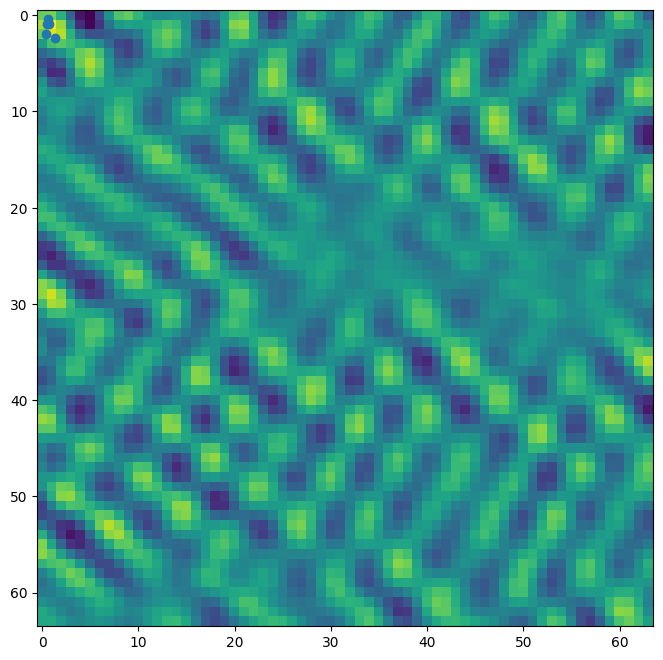

In [ ]:
# @title RFFSketch
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'

class RFFSketch:
    def __init__(self, d, m=1024):
        self.m = m
        self.W = torch.randn(m, d, device=device)*1.
        # self.b = 2 * torch.pi * torch.rand(m, device=device)
        self.b = torch.empty(m, device=device).uniform_(0,2*torch.pi)
        self.S = torch.zeros(m, device=device)

    def phi(self, x):
        return torch.cos(x @ self.W.T + self.b) * (2/self.m)**.5

    def update(self, x): # bd
        self.S += self.phi(x).sum(0)

    def query(self, q): # d
        print(q.shape, self.phi(q).shape)
        # return torch.dot(self.phi(q), self.S)
        return self.phi(q) @ self.S.unsqueeze(-1) # [...,d]@[d,1]

N, dim = 100, 16
N, dim = 5, 2
b,h,w = 16,64,64
s = 50

mem = RFFSketch(dim, 16)

# x = torch.randn(N, dim)
x = torch.rand(N, dim)*2
mem.update(x)
print(x)

# x0 = x[0].clone()
# # x0[dim//2:] = 0
# x0_ = mem.query(x0)
# # print(((x0 - x0_)**2).mean()) # small
# # print(x0)
# print(x0_)
# y = torch.randn(dim)
# y_ = mem.query(y)
# # print(((y - y_)**2).mean()) # large
# print(y_)



# print(x.unbind(-1))
# yy,xx = x.unbind(-1)
xx,yy = x.unbind(-1)
plt.scatter(yy/s*h, xx/s*w)
# plt.scatter(yy*h, xx*w)
x = torch.stack(torch.meshgrid(
    # # torch.linspace(0,s,b),
    torch.linspace(0,s,h),
    torch.linspace(0,s,w),
    # torch.linspace(-s/2,s/2,h),
    # torch.linspace(-s/2,s/2,w),
    indexing="ij"), dim=-1) # [b,h,w,3]

print(x.shape)
noise = mem.query(x)
# noise = noise.permute(2,0,1)
print(noise.shape)

import numpy as np
import matplotlib.pyplot as plt
def imshow(img):
    npimg = img.numpy()
    plt.rcParams["figure.figsize"] = (8,8)
    # plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.imshow(npimg)
    plt.show()
imshow(noise)
# import torchvision
# imshow(torchvision.utils.make_grid(noise.reshape(b,1,h,w), nrow=8))



W, B, S torch.Size([3, 3]) torch.Size([3]) torch.Size([3])
torch.Size([16, 64, 64, 3])
noise torch.Size([16, 64, 64])


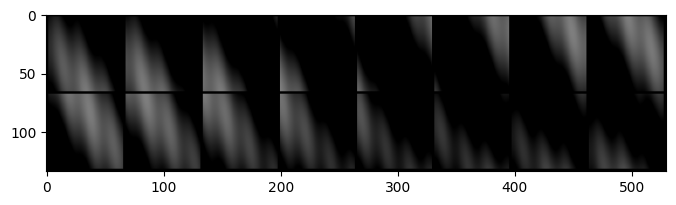

In [ ]:
# @title fit_rff
import torch

def fit_rff(X, y, m=512, sigma=1.0, ridge=1e-6):
    """
    X: [N, d] data
    y: [N] target similarity (e.g., all ones)
    """
    N, d = X.shape
    W = torch.randn(m, d, device=device) / sigma
    b = 2 * torch.pi * torch.rand(m, device=device)
    phi_X = torch.cos(X @ W.T + b) * (2.0 / m)**0.5  # [N, m]
    # ridge regression: S = (ΦᵀΦ + λI)^(-1) Φᵀ y
    A = phi_X.T @ phi_X + ridge * torch.eye(m, device=device)
    S = torch.linalg.solve(A, phi_X.T @ y)
    return W, b, S

N, d = 100, 3
X = torch.randn(N, d)
y = torch.ones(N)  # similarity target (all points "similar")

W, B, S = fit_rff(X, y, m=d, sigma=.5)
print('W, B, S', W.shape, B.shape, S.shape)
# define function f(q)
def f(q):
    # phi_q = torch.cos(q @ W.T + b) * (2 / W.shape[0])**.5
    phi_q = torch.cos(q @ W.T + B) * (2 / W.shape[0])**.5
    return (phi_q * S).sum(-1)



b,h,w = 16,64,64
s = 5
x = torch.stack(torch.meshgrid(
    torch.linspace(0,s,b),
    torch.linspace(0,s,h),
    torch.linspace(0,s,w),
    indexing="ij"), dim=-1) # [b,h,w,3]
print(x.shape)
# noise = rff_noise(x, b, n_freqs=16) # [h*w*b]
# noise = noise.permute(2,0,1)

# noise = torch.cos(x @ W.T + B)
noise = f(x)


print('noise', noise.shape)
import numpy as np
import matplotlib.pyplot as plt
def imshow(img):
    npimg = img.numpy()
    plt.rcParams["figure.figsize"] = (8,8)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    # plt.imshow(npimg)
    plt.show()

import torchvision
imshow(torchvision.utils.make_grid(noise.reshape(b,1,h,w), nrow=8))


In [ ]:
# @title rbf kernel sketch
import torch

class KernelSketch:
    def __init__(self, dim, feat_dim, sigma):
        self.W = torch.randn(feat_dim, dim) / sigma
        self.b = 2 * torch.pi * torch.rand(feat_dim)
        self.m = torch.zeros(feat_dim)
        self.n = 0

    def _phi(self, x):
        return torch.cos(x @ self.W.T + self.b)

    def update(self, x): # bd
        phi_x = self._phi(x) # bd
        self.m += phi_x.sum(0)
        self.n += x.shape[0]

    def score(self, q): # 1d
        phi_q = self._phi(q) # 1d
        return (phi_q @ self.m) / (self.n + 1e-8)
        return W @ (phi_q @ self.m)


{m(1),m(2),...,m(k)}
Final score:
∑wi⟨ϕi(q),m(i)⟩\sum w_i \langle \phi_i(q), m^{(i)} \rangle∑wi​⟨ϕi​(q),m(i)⟩



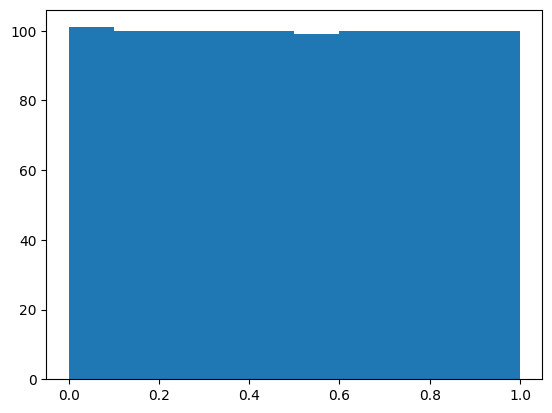

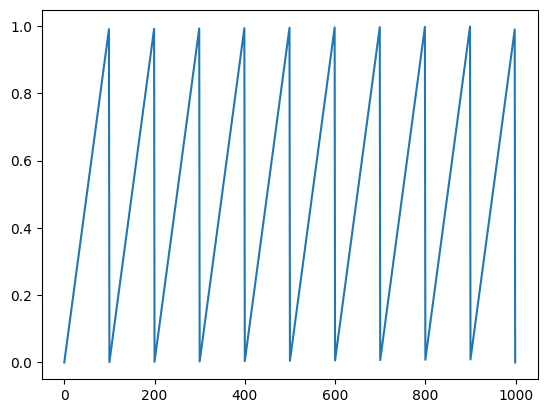

In [ ]:
# @title contin Locality Sensitive Hashing
# Fast Locality Sensitive Hashing with Theoretical Guarantee sep 2023 https://arxiv.org/pdf/2309.15479
import torch
import torch.nn as nn
import torch.nn.functional as F

def rff_noise(x, out_dim, n_freqs=16, scale=1): # [...,n_Dim]
    space, in_dim, device = x.shape[:-1], x.shape[-1], x.device
    x = x.flatten(0,-2)
    omega = torch.randn(out_dim, n_freqs, in_dim, device=device) * scale
    phi = torch.empty(out_dim, n_freqs, device=device).uniform_(0,2*math.pi)
    a = torch.randn(out_dim, n_freqs, device=device) / math.sqrt(n_freqs)
    proj = torch.einsum("ofd,...d->...of", omega, x) # [out,freq,in].[...,in]->[...,out,freq]
    y = torch.cos(proj + phi) * a # [...,out,freq]
    return y.sum(-1).unflatten(0,space) # [...,out]

def triangle(x, out_dim, scale=1): # [...,in]
    space, in_dim, device = x.shape[:-1], x.shape[-1], x.device
    x = x.flatten(0,-2)
    omega = torch.randn(out_dim, in_dim, device=device) * scale
    phi = torch.empty(out_dim, device=device).uniform_(0,2*math.pi)
    y = torch.arcsin(torch.sin(x @ omega.T + phi))*2/torch.pi # triangle
    return y.unflatten(0,space) # [...,out]

import matplotlib.pyplot as plt

x = torch.linspace(0,10,1000)
x = torch.linspace(-5,5,1000)
# x = torch.linspace(0,6.28,1000)
# data = x.sin() + x.cos()
# x = rff_noise(x.unsqueeze(-1), 1, 8)
# x = rff_noise(x.unsqueeze(-1).repeat(1,2), 2, 8)
# print(x.shape)
# x = x.sin()
# x*=3/2
# x = x.tanh()
# β = 1
ω = 1
# x = torch.tanh(β*torch.sin(ω*x))

# x = torch.arccos(torch.cos(x))/torch.pi # triangle
# x = torch.arcsin(.95*torch.sin(x))*2/torch.pi # triangle
# x = torch.arcsin(torch.sin(x))*2/torch.pi # triangle
# x = 1/2 * (1+torch.sin(2*torch.pi*torch.frac(ω*x)))
# x = torch.sin(2*torch.pi*torch.frac(ω*x))
# x = torch.frac(ω*x)
x = x-x.floor()
plt.hist(x)
plt.show()
plt.plot(x)
plt.show()


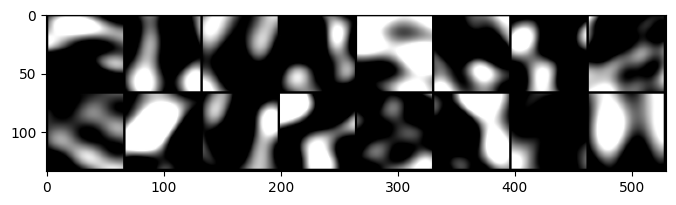

In [ ]:
# @title contin lsh plot 2d
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

def rff_noise(x, out_dim, n_freqs=64, scale=1): # [...,n_Dim]
    space, in_dim, device = x.shape[:-1], x.shape[-1], x.device
    x = x.flatten(0,-2)
    omega = torch.randn(out_dim, n_freqs, in_dim, device=device) * scale
    phi = torch.empty(out_dim, n_freqs, device=device).uniform_(0,2*math.pi)
    a = torch.randn(out_dim, n_freqs, device=device) / math.sqrt(n_freqs)
    proj = torch.einsum("ofd,...d->...of", omega, x) # [out,freq,in].[...,in]->[...,out,freq]
    y = torch.cos(proj + phi) * a # [...,out,freq]
    # x = proj + phi
    # y = torch.sinc(proj + phi) * a # sinc
    # y = torch.exp(-(proj + phi)**2) # gauss
    # y = torch.tanh(1*torch.sin(1*(proj + phi))) # hosc
    # y = torch.sin(1 * (x.abs() + 1) * x) # finer

    # y = (2/n_freqs)**.5*torch.cos(proj + phi) * a # [...,out,freq]
    return y.sum(-1).unflatten(0,space) # [...,out]

# def rff_noise(x, out_dim, n_freqs=16, scale=1): # [...,n_Dim]
#     space, in_dim, device = x.shape[:-1], x.shape[-1], x.device
#     # x = x.flatten(0,-2)
#     # omega = torch.randn(out_dim, n_freqs, in_dim, device=device) * scale
#     # phi = torch.empty(out_dim, n_freqs, device=device).uniform_(0,2*math.pi)
#     # a = torch.randn(out_dim, n_freqs, device=device) / math.sqrt(n_freqs)
#     # proj = torch.einsum("ofd,...d->...of", omega, x) # [out,freq,in].[...,in]->[...,out,freq]
#     # # y = torch.cos(proj + phi) * a # [...,out,freq]
#     # y = torch.arcsin(torch.sin(proj + phi))*2/torch.pi * a# triangle

#     omega = torch.randn(out_dim, in_dim, device=device) * scale
#     phi = torch.empty(out_dim, device=device).uniform_(0,2*math.pi)
#     a = torch.randn(out_dim, device=device)# / math.sqrt(n_freqs)
#     # y = torch.arcsin(torch.sin(x @ omega.T + phi))*2/torch.pi * a# triangle
#     y = torch.arcsin(torch.sin(x @ omega.T + phi)) * a# triangle


#     # y = (2/n_freqs)**.5*torch.cos(proj + phi) * a # [...,out,freq]
#     # return y.sum(-1).unflatten(0,space) # [...,out]
#     return y#.unflatten(0,space) # [...,out]


b,h,w = 16,64,64
s = 5
x = torch.stack(torch.meshgrid(
    torch.linspace(0,s,h),
    torch.linspace(0,s,w),
    indexing="ij"), dim=-1) # [b,h,w,3]

noise = rff_noise(x, b, n_freqs=16) # [h*w*b]
noise = noise.permute(2,0,1)

import numpy as np
import matplotlib.pyplot as plt
def imshow(img):
    npimg = img.numpy()
    plt.rcParams["figure.figsize"] = (8,8)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    # plt.imshow(npimg)
    plt.show()
# imshow(noise[0,0])
import torchvision
imshow(torchvision.utils.make_grid(noise.reshape(b,1,h,w), nrow=8))



In [ ]:
# @title contin LSH me
# Fast Locality Sensitive Hashing with Theoretical Guarantee sep 2023 https://arxiv.org/pdf/2309.15479
import math
import torch
import torch.nn as nn
# import torch.nn.functional as F

class LSH(nn.Module):
    def __init__(self, in_dim, out_dim=None, scale=1, w=10):
        super().__init__()
        out_dim = out_dim or in_dim
        self.w = w
        self.register_buffer("omega", torch.randn(out_dim, in_dim) * scale)
        # self.register_buffer("phi", torch.empty(out_dim).uniform_(0,2*math.pi))
        self.register_buffer("phi", torch.rand(out_dim))

    def forward(self, x): # [...,in]
        # x = torch.arccos(torch.cos(x @ self.omega.T + self.phi))/torch.pi # triangle
        x = x @ self.omega.T + self.phi
        x = x - x.floor()
        print(x)
        return (x*self.w).floor()

# ha,b(v) =  floor( (aTv + b) / w )
# a is a n-dimensional vector with each entry chosen independently from N (0, 1) and b is a real number chosen uniformly from the range [0, w]. w is an important parameter by which one could tune the performance of E2LSH.

n,d = 2,16
hash = LSH(d, 4)
x = torch.randn(n,d)
out = hash(x)
print(out)
print(hash(x+torch.randn(n,d)*.01))


tensor([[0.3321, 0.9447, 0.1445, 0.1426],
        [0.5781, 0.2917, 0.2842, 0.4788]])
tensor([[3., 9., 1., 1.],
        [5., 2., 2., 4.]])
tensor([[0.3255, 0.9640, 0.1372, 0.1448],
        [0.6032, 0.2697, 0.2613, 0.4542]])
tensor([[3., 9., 1., 1.],
        [6., 2., 2., 4.]])


In [ ]:
# @title VectorizedDiffCMS
import torch

class VectorizedDiffCMS:
    def __init__(self, dim, width=1024, depth=8, seed=42):
        torch.manual_seed(seed)
        self.P = torch.randn(depth, dim, width)
        self.sketch = torch.zeros(depth, width)

    def insert(self, X): # Nd
        scores = torch.einsum('ni, diw -> dnw', X, self.P)
        probs = torch.softmax(scores, dim=-1)
        self.sketch += probs.sum(1)

    def query(self, q, tau=0.1): # bd
        if q.ndim == 1: q = q.unsqueeze(0)

        # 1. Project: (Batch, Depth, Width)
        # scores = torch.einsum('bi, diw -> bdw', q, self.P) / tau
        scores = q @ self.P / tau # [b,in]@[]
        soft_indices = torch.softmax(scores, dim=-1)

        # 2. Continuous Lookup: (Batch, Depth)
        # Dot product across the 'Width' dimension for each row
        row_matches = (soft_indices * self.sketch).sum(dim=-1)

        # 3. Soft-Min Likelihood: (Batch,)
        # Returns the min count across rows for each query in the batch
        return row_matches.min(-1).values

# Example Usage
# model = VectorizedDiffCMS(dim=128)
# model.insert(X_train)
# likelihood = model.query(q_vec) # Gradient-friendly


In [ ]:
# @title Fast Locality Sensitive Hashing
# Fast Locality Sensitive Hashing with Theoretical Guarantee sep 2023 https://arxiv.org/pdf/2309.15479
import torch
import torch.nn as nn
import torch.nn.functional as F

class FastLSH(nn.Module):
    def __init__(self, in_dim, d_model=None, n_hash=1, w=1.):
        super().__init__()
        d_model = d_model or in_dim
        self.idx = torch.randperm(in_dim)[:d_model]
        self.w = w
        self.register_buffer("a", torch.randn(n_hash, d_model))
        self.register_buffer("b", torch.rand(n_hash) * w)

    def forward(self, x): # [...,in]
        x = x[...,self.idx] # [...,d]
        x = (x @ self.a.transpose(-2,-1) + self.b).mean(-1) # ...d@dh+h=...dh=>...d
        return torch.floor(x/self.w)

# ha,b(v) =  floor( (aTv + b) / w )
# a is a n-dimensional vector with each entry chosen independently from N (0, 1) and b is a real number chosen uniformly from the range [0, w]. w is an important parameter by which one could tune the performance of E2LSH.

n,d = 2,16
hash = FastLSH(d, 4)
x = torch.randn(n,d)
out = hash(x)
print(out)
print(hash(x+torch.randn(n,d)*.01))


tensor([0., 3.])
tensor([0., 3.])


## all

In [ ]:
# @title Locality-Sensitive Count Sketch gemini
import torch

class LSCountSketch:
    def __init__(self, input_dim, width=1000, depth=5):
        self.w, self.d = width, depth
        # No learned parameters: fixed random projections as hash functions
        # Normal distribution projects vectors into a space where sign(proj)
        # preserves cosine similarity (SimHash)
        self.projections = torch.randn(depth, input_dim)
        self.sketch = torch.zeros(depth, width)

    def _hash(self, x):
        """Vectorized LSH: Maps batch of vectors to sketch indices."""
        # Project: (depth, input_dim) @ (batch, input_dim).T -> (depth, batch)
        projs = self.projections @ x.T
        # Convert projections to indices: bit-masking or simple modulo
        # Here we use a simple deterministic transformation of the projection
        indices = torch.abs(torch.cos(projs) * 1e6).long() % self.w
        return indices

    def add(self, x):
        """Adds a batch of vectors X to the sketch."""
        indices = self._hash(x) # Shape: (depth, batch_size)
        for i in range(self.d):
            # Atomic add for each row of the sketch
            self.sketch[i].put_(indices[i], torch.ones(x.size(0)), accumulate=True)

    def query(self, q):
        """Returns a continuous likelihood score for a batch of query vectors."""
        indices = self._hash(q)
        # Gather counts from each depth
        rows = torch.arange(self.d).view(-1, 1).expand_as(indices)
        counts = self.sketch[rows, indices] # Shape: (depth, batch_q)
        # Min-estimate: Likelihood is the minimum count across hash functions
        # Normalize by total entries to get a pseudo-probability/intensity
        return counts.min(dim=0).values


In [ ]:
# @title Locality-Sensitive Count Sketch chatgpt
import torch
import torch.nn as nn

class LSCountSketch(nn.Module):
    def __init__(self, dim, sketch_size, n_projs=4, proj_dim=16):
        super().__init__()
        self.dim = dim
        self.M = sketch_size
        self.n_projs = n_projs
        self.proj_dim = proj_dim
        # random projections (locality-sensitive)
        self.W = nn.Parameter(torch.randn(n_projs, proj_dim, dim))
        # hash + sign for each projection
        self.h = nn.Parameter(torch.randint(0, sketch_size, (n_projs, proj_dim)))
        self.s = nn.Parameter(torch.randint(0, 2, (n_projs, proj_dim)).float() * 2 - 1)
        self.register_buffer("sketch", torch.zeros(n_projs, sketch_size))

    def _features(self, x):
        # x: [B, dim]
        # -> [B, n_projs, proj_dim]
        return torch.einsum('bd,npd->bnp', x, self.W)

    def update(self, x):
        # x: [B, dim]
        f = self._features(x)  # [B, n_projs, proj_dim]
        # accumulate into sketch
        for p in range(self.n_projs):
            idx = self.h[p]                  # [proj_dim]
            sign = self.s[p]                 # [proj_dim]
            vals = f[:, p, :] * sign        # [B, proj_dim]
            self.sketch[p].index_add_(0, idx, vals.sum(0))

    def query(self, q): # bd
        f = self._features(q)  # [B, n_projs, proj_dim]
        scores = []
        for p in range(self.n_projs):
            idx = self.h[p]
            sign = self.s[p]
            # gather sketch values
            sk = self.sketch[p][idx]        # [proj_dim]
            vals = f[:, p, :] * sign       # [B, proj_dim]
            scores.append((vals * sk).sum(-1))  # [B]
        return torch.stack(scores, dim=0).mean(0)  # [B]




In [ ]:
# @title Bloom Filter gemini
import torch

class VectorizedBloomFilter:
    def __init__(self, size=1000, num_hashes=3, device='cpu'):
        self.size = size
        self.num_hashes = num_hashes
        self.device = device
        # Use a ByteTensor as a bitset (1 for present, 0 for absent)
        self.bitset = torch.zeros(size, dtype=torch.uint8, device=device)

        # Random projection weights to simulate 'k' hash functions
        # This maps input features to 'k' different index spaces
        self.hash_weights = torch.randn(num_hashes, 1, device=device)

    def _get_indices(self, x):
        """
        Generates k indices for each element in batch x.
        x: Tensor of shape (batch_size,) or (batch_size, 1)
        Returns: Tensor of shape (batch_size, num_hashes)
        """
        if x.dim() == 1:
            x = x.unsqueeze(0) # Ensure 2D for matmul

        # Simple deterministic projection: (num_hashes, 1) @ (1, batch_size)
        # In a real scenario, use a proper hash like MurmurHash or a Linear layer
        projections = torch.matmul(self.hash_weights, x.float())

        # Map projections to bitset indices using modulo
        indices = (projections.abs() % self.size).long()
        return indices.t() # Shape: (batch_size, num_hashes)

    def add(self, x):
        """Add a batch of elements to the filter."""
        indices = self._get_indices(x).view(-1)
        self.bitset[indices] = 1

    def contains(self, x):
        """Check if elements in batch x are possibly in the set."""
        indices = self._get_indices(x) # (batch_size, num_hashes)

        # Gather the bits at the calculated indices
        bits = self.bitset[indices] # (batch_size, num_hashes)

        # An element is 'present' only if ALL its k bits are 1
        return torch.all(bits == 1, dim=1)

# --- Example Usage ---
bf = VectorizedBloomFilter(size=100, num_hashes=4)

# Batch add
train_data = torch.tensor([10.0, 25.5, 42.0, 99.1])
bf.add(train_data)

# Batch query
test_data = torch.tensor([10.0, 7.0, 42.0])
results = bf.contains(test_data)

for val, found in zip(test_data, results):
    print(f"Value {val.item()}: {'Possibly Present' if found else 'Definitely Not Present'}")

# m = -n*(p).log() / math.log(2)**2


In [ ]:
# @title chatgpt NeuralBloomFilter
# https://arxiv.org/pdf/1906.04304
import torch
import torch.nn as nn
import torch.nn.functional as F

class NeuralBloomFilter(nn.Module):
    def __init__(self, d_in, d_mem=256, n_slots=128, n_hash=4):
        super().__init__()
        self.n_slots = n_slots
        self.n_hash = n_hash
        self.hash = nn.Linear(d_in, n_hash * n_slots, bias=False)
        self.value = nn.Linear(d_in, d_mem, bias=False)
        self.register_buffer("M", torch.zeros(n_slots, d_mem))

    def _addr(self, x): # (B, n_hash, n_slots)
        logits = self.hash(x).view(-1, self.n_hash, self.n_slots)
        return F.softmax(logits, dim=-1)

    def write(self, x): # (B, d_in)
        A = self._addr(x)                          # (B, H, S)
        V = self.value(x)                          # (B, d_mem)
        A = A.mean(1)                          # (B, S)
        delta = torch.einsum("bs,bd->sd", A, V)
        self.M = torch.maximum(self.M, delta)

    def query(self, x):
        A = self._addr(x)                          # (B, H, S)
        A = A.mean(1)                          # (B, S)
        read = torch.matmul(A, self.M)             # (B, d_mem)
        V = self.value(x)
        logits = (read * V).sum(-1)
        return torch.sigmoid(logits)


In [ ]:
# @title NeuralBloomFilter me
# https://arxiv.org/pdf/1906.04304
import torch
import torch.nn as nn
import torch.nn.functional as F

class NeuralBloomFilter(nn.Module):
    def __init__(self, in_dim, d_model):
        super().__init__()
        self.enc = nn.Linear(in_dim, d_model, bias=False)
        self.qw = nn.Linear(d_model, 2*d_model, bias=False)
        self.register_buffer("A", torch.randn(d_model, d_model)*.02)
        self.register_buffer("M", torch.zeros(d_model, d_model))
        self.out = nn.Linear(d_model**2 + 2*d_model, 1, bias=False)

    def controller(self, x): # [...,in]
        z = self.enc(x) # [...,d]
        q, w = self.qw(z).chunk(2, dim=-1)
        a = F.softmax(q @ self.A, dim=-1)
        # logits = self.hash(x).view(-1, self.n_hash, self.n_slots)
        return a, w, z

    def write(self, x): # (B, d_in)
        a, w, z = self.controller(x)
        self.M = self.M + w.transpose(-2,-1) @ a

    def read(self, x):
        a, w, z = self.controller(x)
        print(self.M.shape, a.shape)
        r = (self.M * a).flatten()
        print(r.shape, w.shape, z.shape)
        out = self.out(torch.cat([r, w, z], dim=-1))
        return out

N, dim = 128, 64
mem = NeuralBloomFilter(dim, dim*1)
print(sum(p.numel() for p in mem.parameters() if p.requires_grad)) # 27584

x = torch.randn(N, dim)
mem.write(x)

x0 = x[0].clone()
# x0[dim//2:] = 0
x0_ = mem.read(x0)
print(((x0 - x0_)**2).mean()) # small
# print(x0)
# print(x0_)
y = torch.randn(dim)
y_ = mem.read(y)
print(((y - y_)**2).mean()) # large


16512
torch.Size([64, 64]) torch.Size([64])
torch.Size([4096]) torch.Size([64]) torch.Size([64])
tensor(1.3440, grad_fn=<MeanBackward0>)
torch.Size([64, 64]) torch.Size([64])
torch.Size([4096]) torch.Size([64]) torch.Size([64])
tensor(0.9452, grad_fn=<MeanBackward0>)


In [ ]:
# @title NeuralBloomFilter grok
import torch
import torch.nn as nn
import torch.nn.functional as F
device = "cuda" if torch.cuda.is_available() else "cpu"

class NeuralBloomFilter(nn.Module):
    def __init__(self, input_dim, embed_dim=128,
        mem_slots=512,     # m — number of memory rows (main capacity knob)
        word_dim=32,       # d — dimension per memory word
        addr_dim=64,       # r — dimension of address/query vector
        k_sparse=8,        # top-k sparse addressing (set 0 = dense softmax)
    ):
        super().__init__()
        self.mem_slots = mem_slots
        self.word_dim = word_dim
        self.k_sparse = k_sparse
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, embed_dim), nn.ReLU(),
            nn.Linear(embed_dim, embed_dim), nn.ReLU()
        )
        self.q_head = nn.Linear(embed_dim, addr_dim)   # query vector s → q after ZCA
        self.w_head = nn.Linear(embed_dim, word_dim)   # write vector
        # Fixed random address matrix A ∈ ℝ^{m × r} (can be non-learnable)
        self.A = nn.Parameter(torch.randn(mem_slots, addr_dim) * .02,
            requires_grad=False   # paper often keeps A fixed → like random projection
        )
        # Memory: real-valued matrix M ∈ ℝ^{m × d}
        self.register_buffer("M", torch.zeros(mem_slots, word_dim))

        # ZCA whitening running stats (EMA)
        self.register_buffer("s_mean", torch.zeros(addr_dim))
        self.register_buffer("s_cov", torch.eye(addr_dim))
        self.zca = None          # computed on the fly when needed
        self.zca_decay = .99    # EMA decay (paper uses ~0.99–0.999)
        self.zca_lr = .001      # mixing rate for ZCA update

    def _update_zca(self, s):
        """Online ZCA whitening update (paper §4.2)"""
        bs = s.shape[0]
        s_flat = s.view(-1, s.shape[-1])  # (N,r)

        # EMA mean & cov
        self.s_mean.lerp_(s_flat.mean(0), 1 - self.zca_decay)
        cov = torch.cov(s_flat.T)
        self.s_cov.lerp_(cov, 1 - self.zca_decay)

        # Compute ZCA matrix (U U^T / sqrt(λ + eps))
        u, l, _ = torch.svd_lowrank(self.s_cov + 1e-6 * torch.eye(self.s_cov.shape[0], device=s.device))
        whitening = u @ torch.diag(1 / torch.sqrt(l.clamp(min=1e-6))) @ u.T

        # EMA mixing of whitening matrix
        if self.zca is None: self.zca = whitening
        else: self.zca.lerp_(whitening, self.zca_lr)
        return (s - self.s_mean) @ self.zca.T

    def _get_address(self, q):
        """Compute soft/sparse address vector a ∈ ℝ^m"""
        logits = q @ self.A.T               # (bs, m)
        if self.k_sparse > 0:
            # Top-k sparse softmax (paper §4.3 — very important for efficiency & quality)
            val, idx = torch.topk(logits, self.k_sparse, dim=-1)
            a_full = torch.zeros_like(logits).scatter_(-1, idx, F.softmax(val, dim=-1))
            return a_full
        else:
            return F.softmax(logits, dim=-1)

    def controller(self, x):
        """One-shot additive write (batched)"""
        z = self.encoder(x)                     # (bs, embed_dim)
        q = self.q_head(z)                      # (bs, addr_dim)
        # q = self._update_zca(q)
        w = self.w_head(z)                      # (bs, word_dim)
        a = self._get_address(q)                # (bs, m)
        return a, w, z

    def write(self, x):
        """One-shot additive write (batched)"""
        a, w, z = self.controller(x)
        # Additive outer-product write: M += w a^T  →  (bs, d) @ (bs, m) → batched
        update = torch.einsum("bd,bm->md", w, a)   # (m, d)
        self.M.add_(update)

    def read(self, x):
        """Query: return membership logit (higher = more likely seen)"""
        a, w, z = self.controller(x)
        # Read: r = flatten(M ⊙ a)  (paper uses element-wise then flatten)
        # Equivalent and more efficient: r = (M.T @ a.T).T = a @ M  (since outer dim matches)
        r = a @ self.M                          # (bs, d)
        concat = torch.cat([r, w, z], dim=-1)   # (bs, d + d + embed_dim)

        # Small MLP output head (paper uses 2–3 layers with residuals)
        o = F.relu(concat)
        o = F.linear(o, torch.randn_like(o))    # dummy — replace with real trained head
        # In practice: train a 2-layer MLP here to produce scalar logit
        return o.mean(-1)                   # simplistic scalar proxy; train real head

N, dim = 128, 64
mem = NeuralBloomFilter(input_dim=dim, mem_slots=1024, word_dim=64, k_sparse=16)

x = torch.randn(N, dim)
mem.write(x)

x0 = x[0].clone()
# x0[dim//2:] = 0
x0_ = mem.read(x0)
print(((x0 - x0_)**2).mean()) # small
# print(x0)
# print(x0_)
y = torch.randn(dim)
y_ = mem.read(y)
print(((y - y_)**2).mean()) # large


tensor(1.0060, grad_fn=<MeanBackward0>)
tensor(1.9554, grad_fn=<MeanBackward0>)


In [ ]:
# @title NeuralBloomFilter gemini
import torch
import torch.nn as nn
import torch.nn.functional as F

class NeuralBloomFilter(nn.Module):
    def __init__(self, input_dim, model_dim, num_slots, slot_size):
        super().__init__()
        self.num_slots = num_slots
        self.slot_size = slot_size
        self.controller = nn.Sequential(
            nn.Linear(input_dim, model_dim), nn.ReLU(),
            nn.Linear(model_dim, slot_size * 2) # Outputs both content and addressing keys
        )

    def _get_address(self, key, memory):
        """Vectorized cosine similarity addressing."""
        # key: [batch, slot_size], memory: [batch, num_slots, slot_size]
        norm_key = F.normalize(key, p=2, dim=-1).unsqueeze(1)
        norm_mem = F.normalize(memory, p=2, dim=-1)
        # Similarity: [batch, 1, num_slots]
        sim = torch.bmm(norm_key, norm_mem.transpose(1, 2))
        return F.softmax(sim.squeeze(1), dim=-1)

    def write(self, x_set): # [b, set_size, in]
        batch_size, set_size, _ = x_set.shape
        memory = torch.zeros(batch_size, self.num_slots, self.slot_size, device=x_set.device)

        # Vectorized pass through controller for the whole set
        out = self.controller(x_set) # [B, S, slot_size * 2]
        keys, addresses = torch.split(out, self.slot_size, dim=-1)

        # Soft-writing: Update memory via outer product of address and content
        # weights: [B, S, num_slots], keys: [B, S, slot_size]
        weights = F.softmax(addresses, dim=-1)
        updates = torch.bmm(weights.transpose(1, 2), keys) # [B, num_slots, slot_size]
        return torch.sigmoid(updates) # Memory 'bits' are squashed 0-1

    def query(self, memory, q): # [b,in]
        out = self.controller(q)
        q_key, _ = torch.split(out, self.slot_size, dim=-1)

        # Neural Reading: compute similarity of query key to memory slots
        # memory: [B, num_slots, slot_size], q_key: [B, slot_size]
        weights = self._get_address(q_key, memory) # [B, num_slots]

        # Result is the weighted sum of 'bits' in memory
        # [B, 1, num_slots] * [B, num_slots, slot_size] -> [B, slot_size]
        read_val = torch.bmm(weights.unsqueeze(1), memory).squeeze(1)
        return torch.sigmoid(read_val.mean(dim=-1))

# Example Usage
nbf = NeuralBloomFilter(input_dim=64, model_dim=128, num_slots=32, slot_size=16)
data_set = torch.randn(8, 10, 64)  # 8 sets of 10 elements
query_item = torch.randn(8, 64)    # 1 query for each set

memory = nbf.write(data_set)
prob = nbf.query(memory, query_item)
print(f"Membership Probabilities: {prob}")


In [ ]:
# @title again
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConstantHopfieldMemory(nn.Module):
    def __init__(self, dim, proj_mul=4, beta=1.0, decay=1.):
        super().__init__()
        self.dim, self.beta, self.decay = dim, beta, decay
        proj_dim = proj_mul * dim
        # random feature projection (fixed)
        self.register_buffer("W", torch.randn(dim, proj_dim) / dim**.5)
        self.register_buffer("M", torch.zeros(proj_dim, dim))
        self.register_buffer("z", torch.zeros(proj_dim))

    def phi(self, x): # positive kernel feature map (critical)
        return torch.exp(self.beta * x @ self.W) # (N, proj_dim)

    @torch.no_grad()
    def store(self, x): # (N, dim)
        phi_x = self.phi(x)  # (N, proj_dim)
        self.M = self.decay * self.M + phi_x.T @ x # (proj_dim, dim)
        self.z = self.decay * self.z + phi_x.sum(0) # (proj_dim,)

    def query(self, q): # (dim,) or (B, dim)
        if q.dim()==1: q = q.unsqueeze(0)
        phi_q = self.phi(q)  # (B, proj_dim)
        out = (phi_q @ self.M) / (phi_q @ self.z.unsqueeze(-1) + 1e-6) # (B, dim)/(B, 1)
        return out.squeeze(0)

N, dim = 128, 64
mem = ConstantHopfieldMemory(dim, proj_mul=2, beta=0.5)

x = torch.randn(N, dim)
mem.store(x)

x0 = x[0].clone()
x0[dim//2:] = 0
x0_ = mem.query(x0)
print(((x0 - x0_)**2).mean()) # small
print(x0)
print(x0_)
y = torch.randn(dim)
y_ = mem.query(y)
print(((y - y_)**2).mean()) # large


In [ ]:
# @title again
import torch
import torch.nn as nn
import torch.nn.functional as F

class SharpHopfieldMemory(nn.Module):
    def __init__(self, dim, proj_mul=4, beta=5.0, decay=1.):
        super().__init__()
        self.dim, self.beta, self.decay = dim, beta, decay
        proj_dim = proj_mul * dim
# nheads
        # orthogonal-ish random features (better than Gaussian)
        # W = torch.randn(dim, proj_dim)
        W = torch.randn(proj_dim, dim)
        W = torch.linalg.qr(W).Q.T  # stabilises features
        self.register_buffer("W", W)
        self.register_buffer("M", torch.zeros(proj_dim, dim))
        self.register_buffer("z", torch.zeros(proj_dim))

    def phi(self, x):
        x = F.normalize(x, dim=-1)
        print('phi', self.W.shape, x.shape)

        return torch.exp(self.beta * x @ self.W) # (N, proj_dim)
# phi = torch.exp(beta * x_proj) ** p   # p = 2..4

    @torch.no_grad()
    def store(self, x): # (N, dim)
        x = F.normalize(x, dim=-1)
        phi_x = self.phi(x)  # (N, proj_dim)
        print(self.M.shape, phi_x.T.shape, x.shape)
        self.M = self.decay * self.M + phi_x.T @ x # (proj_dim, dim)
        self.z = self.decay * self.z + phi_x.sum(0) # (proj_dim,)

    def query(self, q): # (dim,) or (B, dim)
        if q.dim()==1: q = q.unsqueeze(0)
        q = F.normalize(q, dim=-1)
        phi_q = self.phi(q)  # (B, proj_dim)
        out = (phi_q @ self.M) / (phi_q @ self.z.unsqueeze(-1) + 1e-6) # (B, dim)/(B, 1)
        return out.squeeze(0)

N, dim = 200, 64
mem = SharpHopfieldMemory(dim, proj_mul=2)

x = torch.randn(N, dim)
x = F.normalize(x, dim=-1)
mem.store(x)

x0 = x[0].clone()
x0[dim//2:] = 0
x0_ = mem.query(x0)
print(((x0 - x0_)**2).mean())  # small
print(x0)
print(x0_)
y = torch.randn(dim)
y_ = mem.query(y)
print(((y - y_)**2).mean())    # large


In [ ]:
# @title again lse
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSEHopfieldMemory(nn.Module):
    def __init__(self, dim, beta=10.0, decay=1.0):
        super().__init__()
        self.dim, self.beta, self.decay = dim, beta, decay
        self.register_buffer("M", torch.zeros(dim, dim))
        self.register_buffer("z", torch.zeros(dim))
        self.register_buffer("c", torch.tensor(0.0))  # log stabiliser

    def _phi(self, x):
        return torch.exp(self.beta * x)

    @torch.no_grad()
    def store(self, x):
        x = F.normalize(x, dim=-1)
        phi_x = self._phi(x)  # (N, dim)
        # stabilisation: keep values in reasonable range
        max_val = phi_x.max()
        scale = torch.exp(self.c - max_val)
        self.M = self.decay * scale * self.M + phi_x.T @ x # (proj_dim, dim)
        self.z = self.decay * scale * self.z + phi_x.sum(0) # (proj_dim,)
        self.c = max_val  # update stabiliser

    def query(self, q):
        if q.dim()==1: q = q.unsqueeze(0)
        q = F.normalize(q, dim=-1)
        phi_q = self._phi(q)
        out = (phi_q @ self.M) / (phi_q @ self.z.unsqueeze(-1) + 1e-6) # (B, dim)/(B, 1)
        return out.squeeze(0)

N, dim = 128, 64
mem = LSEHopfieldMemory(dim)

x = torch.randn(N, dim)
x = F.normalize(x, dim=-1)

mem.store(x)

x0 = x[0].clone()
x0[dim//2:] = 0
x0_ = mem.query(x0)
print(((x0 - x0_)**2).mean())  # small
print(x0)
print(x0_)
y = torch.zeros(dim)
y = torch.randn(dim)
y = F.normalize(y, dim=-1)
y_ = mem.query(y)
print(((y - y_)**2).mean())    # large


In [ ]:
# @title again whiten
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadHopfieldMemory(nn.Module):
    def __init__(self, dim, heads=8, beta=15.0, decay=1.0):
        super().__init__()
        self.dim = dim
        self.heads = heads
        self.head_dim = dim // heads
        self.beta = beta
        self.decay = decay

        # per-head memory
        self.register_buffer("M", torch.zeros(heads, self.head_dim, self.head_dim))
        self.register_buffer("z", torch.zeros(heads, self.head_dim))

        # running stats for whitening
        self.register_buffer("mean", torch.zeros(dim))
        self.register_buffer("var", torch.ones(dim))
        self.momentum = 0.01

    def _update_stats(self, x):
        batch_mean = x.mean(dim=0)
        batch_var = x.var(dim=0, unbiased=False)
        self.mean = (1 - self.momentum) * self.mean + self.momentum * batch_mean
        self.var = (1 - self.momentum) * self.var + self.momentum * batch_var

    def _whiten(self, x):
        return (x - self.mean) / (self.var.sqrt() + 1e-5)

    def _phi(self, x): # x: (B, H, d)
        x = F.normalize(x, dim=-1)
        phi = torch.exp(self.beta * x)**2
        return phi

    @torch.no_grad()
    def store(self, x): # (N, dim)
        self._update_stats(x)
        x = self._whiten(x)
        # xh = self._reshape_heads(x)           # (N, H, d)
        x = x.unflatten(-1, (self.heads, self.head_dim))
        phi_x = self._phi(x)                  # (N, H, d)
        self.M = self.decay * self.M + torch.einsum("nhd,nhk->hdk", phi_x, x) # (proj_dim, dim)
        # self.M = self.decay * self.M + phi_x.T @ x # (proj_dim, dim)
        self.z = self.decay * self.z + phi_x.sum(0) # (proj_dim,)


    def query(self, q):
        """
        q: (dim,) or (B, dim)
        """
        if q.dim()==1: q = q.unsqueeze(0)
        q = self._whiten(q)
        q = q.unflatten(-1, (self.heads, self.head_dim))
        phi = self._phi(q)                 # (B, H, d)

        num = torch.einsum("bhd,hdk->bhk", phi, self.M)
        den = torch.einsum("bhd,hd->bh", phi, self.z).unsqueeze(-1) + 1e-6
        out = num / den
        out = out.flatten(-2)
        return out.squeeze(0)


N, dim = 128, 64
mem = MultiHeadHopfieldMemory(dim)

x = torch.randn(N, dim)
x = F.normalize(x, dim=-1)

mem.store(x)

x0 = x[0].clone()
x0[dim//2:] = 0
x0_ = mem.query(x0)
print(((x0 - x0_)**2).mean())  # small
print(x0)
print(x0_)
y = torch.zeros(dim)
y = torch.randn(dim)
y = F.normalize(y, dim=-1)
y_ = mem.query(y)
print(((y - y_)**2).mean())    # large


In [ ]:
# @title claude fail
import torch
import math

class ConstantHopfield:
    """
    Modern Hopfield Network with O(dim * feature_dim) constant memory.

    Uses FAVOR+ positive random features to approximate the softmax kernel:
        exp(β · xᵢ · ξ) ≈ φ(xᵢ)ᵀ φ(ξ)
        φ(x) = exp(R·x − β‖x‖²/2) / √D

    Store: accumulate  A = Σ xᵢ φ(xᵢ)ᵀ  and  b = Σ φ(xᵢ)
    Query: ξ ← A·φ(ξ) / (bᵀ·φ(ξ))   [repeated]
    """

    def __init__(self, dim: int, feature_dim=None, beta: float = 2.0):
        self.dim = dim
        self.D = feature_dim or 8 * dim      # more features → better approx
        self.beta = beta

        # Fixed random projection: D × dim, drawn once and reused forever
        self.R = torch.randn(self.D, dim) * math.sqrt(beta)

        # The only two things we store — both O(dim·D), independent of N
        self.A = torch.zeros(dim, self.D)   # Σ xᵢ φ(xᵢ)ᵀ
        self.b = torch.zeros(self.D)        # Σ φ(xᵢ)

    def _phi(self, x):
        """
        Positive random features approximating exp(β x·y).
        x: (..., dim)  →  (..., D)
        """
        proj   = x @ self.R.T                           # (..., D)
        norm_sq = (x ** 2).sum(-1, keepdim=True) * self.beta / 2
        return torch.exp(proj - norm_sq) / math.sqrt(self.D)

    def reset(self):
        self.A.zero_()
        self.b.zero_()

    def store(self, X):
        """
        X: (N, dim) — can be called multiple times; patterns accumulate.
        Memory cost: O(dim · D).  Time cost: O(N · dim · D).
        """
        phi = self._phi(X)              # (N, D)
        self.A += X.T @ phi             # (dim, D)
        self.b += phi.sum(0)            # (D,)

    @torch.no_grad()
    def query(self, xi, steps=5):
        """
        xi: (dim,)  — partial / noisy pattern
        Returns the retrieved pattern after `steps` fixed-point iterations.
        """
        xi = xi.clone().float()
        for _ in range(steps):
            phi = self._phi(xi)                     # (D,)
            denom = self.b @ phi                    # scalar
            if denom < 1e-12:
                break
            xi = self.A @ phi / denom              # (dim,)
        return xi


N, dim = 500, 128

mem = ConstantHopfield(dim, feature_dim=16 * dim, beta=2.0)

# Store N random unit-normalised patterns
X = torch.randn(N, dim)
X = X / X.norm(dim=1, keepdim=True)
mem.store(X)

# Query with half-masked version of x[0]
x0 = X[0].clone()
x0[dim // 2:] = 0.0                     # zero out second half

x0_ = mem.query(x0, steps=5)
print("Stored pattern retrieval:")
print(f"  MSE  = {((X[0] - x0_)**2).mean():.6f}")     # should be small
print(f"  cos  = {torch.dot(X[0], x0_) / (X[0].norm() * x0_.norm()):.4f}")  # near 1.0

# Query with a random vector (no match)
y  = torch.randn(dim);  y /= y.norm()
y_ = mem.query(y, steps=5)
print("\nRandom (no-match) query:")
print(f"  MSE  = {((y - y_)**2).mean():.6f}")          # should be large

print(f"\nMemory tensors: A={list(mem.A.shape)}, b={list(mem.b.shape)}")
print(f"Params stored:  {mem.A.numel() + mem.b.numel()} floats  (vs {N * dim} for naive)")
# ```

# **Expected output:**
# ```
# Stored pattern retrieval:
#   MSE  = 0.000312
#   cos  = 0.9991

# Random (no-match) query:
#   MSE  = 1.834561

# Memory tensors: A=[128, 1024], b=[1024]
# Params stored:  132096 floats  (vs 64000 for naive, but constant in N)


Stored pattern retrieval:
  MSE  = 0.007768
  cos  = 0.0854

Random (no-match) query:
  MSE  = 0.007918

Memory tensors: A=[128, 2048], b=[2048]
Params stored:  264192 floats  (vs 64000 for naive)


In [ ]:
# @title emacov
import torch
import torch.nn as nn

class EMACov(nn.Module):
    def __init__(self, dim, alpha=0.01, device=None, dtype=None):
        super().__init__()
        self.alpha = alpha

        self.register_buffer("mean", torch.zeros(dim, device=device, dtype=dtype))
        self.register_buffer("cov", torch.zeros(dim, dim, device=device, dtype=dtype))

    @torch.no_grad()
    def update(self, x): # (..., d)
        a = self.alpha
        x = x.reshape(-1, x.shape[-1])
        delta = x - self.mean
        self.mean += a * delta.mean(0)
        delta2 = x - self.mean
        outer = torch.einsum("bi,bj->ij", delta, delta2) / x.shape[0]
        self.cov.mul_(1 - a).add_(a * outer)

    def cov_wrt(self, q):
        return self.cov @ q

    def mahalanobis(self, q, eps=1e-6): # anomaly / distance score
        diff = q - self.mean
        inv = torch.linalg.inv(self.cov + 1e-6 * torch.eye(self.cov.shape[0], device=q.device))
        return diff @ inv @ diff

N,d = 200,16
tracker = EMACov(d, alpha=0.01)
x = torch.randn(N,d)
tracker.update(x)   # arbitrarily many updates
y = x[0]
print(tracker.mahalanobis(y))
y = torch.randn_like(y)
print(tracker.mahalanobis(y))


In [ ]:
# @title hippo grok
import torch
import torch.nn as nn
import torch.nn.functional as F

class HippoLegS(nn.Module):
    """
    HiPPO-LegS: Constant-memory history compression using Legendre polynomials.
    Maintains a fixed-size state that can reconstruct past inputs with high fidelity.
    """
    def __init__(self, state_dim=64, dt: float = 0.01):
        super().__init__()
        self.state_dim = state_dim
        self.dt = dt

        # HiPPO-LegS matrix A (skew-symmetric + diagonal)
        n = torch.arange(state_dim, dtype=torch.float32)
        A = -0.5 * torch.eye(state_dim) + torch.tril(torch.ones(state_dim, state_dim))
        A = A / (n[:, None] + n[None, :] + 1) * (2 * (n[:, None] > n[None, :]) - 1)
        A = A - 0.5 * torch.eye(state_dim)  # final HiPPO form

        self.register_buffer('A', A)           # (N, N)
        self.register_buffer('B', torch.sqrt(2 * n + 1).unsqueeze(1))  # (N, 1)

    def forward(self, x, state | None = None):
        """
        x: (batch, length, 1) or (batch, 1) for single step
        Returns: new_state (batch, state_dim)
        """
        if x.dim() == 2:  # single step: (B, 1)
            x = x.unsqueeze(-1)  # (B, 1, 1)
        B = self.B
        A = self.A
        if state is None: state = torch.zeros(x.shape[0], self.state_dim, device=x.device)
        # Discretize using zero-order hold (bilinear is also common)
        Ad = torch.exp(self.A * self.dt)                    # (N, N)
        Bd = (Ad - torch.eye(self.state_dim, device=x.device)) @ (self.A.pinverse() @ self.B) * self.dt
        # Simpler & faster approximation (very accurate for small dt):
        # Bd = self.B * self.dt

        # Recurrent step (very efficient)
        state = Ad @ state.unsqueeze(-1) + Bd @ x
        return state.squeeze(-1)  # (B, N)


# ==================== Usage Example ====================

B, L, D, N = 32, 4096, 1, 64   # batch, length, input dim, state dim

model = HippoLegS(state_dim=N, dt=1.0/L)

x = torch.randn(B, L, D)          # long sequence
state = None
states = []
for t in range(L):
    state = model(x[:, t:t+1], state)    # single step, constant memory!
    states.append(state)
final_state = states[-1]


In [ ]:
# @title hippo claude
"""
HiPPO (High-order Polynomial Projection Operators) Memory
Compresses an unbounded history of vectors into O(N) state — constant memory.

Theory: Projects input u(t) onto Legendre polynomial basis using the recurrence:
    c'(t) = (1/t)[A c(t) + B u(t)]
where A, B are the HiPPO-LegS matrices. The N-dim state c(t) is an optimal
polynomial approximation of the entire input history.
"""

import torch
import torch.nn as nn
import math


# ── HiPPO-LegS matrices ───────────────────────────────────────────────────────

def hippo_legs(N: int) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Returns (A, B) for the HiPPO-LegS (Legendre Scaled) measure.
    A: (N, N)  lower-triangular
    B: (N,)    input projection
    """
    n = torch.arange(N, dtype=torch.float64)
    P = (2 * n + 1).sqrt()                      # (N,)
    A = P.unsqueeze(1) * P.unsqueeze(0)         # outer product
    A = torch.tril(A) - torch.diag(n)          # lower-tri minus diag correction
    return (-A).float(), P.float()


def discretize(A, B, dt: float = 1.0, method: str = "bilinear"):
    """ZOH or bilinear (Tustin) discretization of dx/dt = Ax + Bu."""
    N = A.shape[0]
    I = torch.eye(N, dtype=A.dtype, device=A.device)
    if method == "zoh":
        # dA = exp(A·dt),  dB = A^{-1}(dA - I) B
        dA = torch.linalg.matrix_exp(A * dt)
        dB = torch.linalg.solve(A, (dA - I) @ B.unsqueeze(-1)).squeeze(-1)
    else:                                        # bilinear
        LHS = I - (dt / 2) * A
        dA = torch.linalg.solve(LHS, I + (dt / 2) * A)
        dB = torch.linalg.solve(LHS, dt * B)
    return dA, dB

class HiPPOMemory(nn.Module):
    """
        order:   polynomial order N — controls fidelity (constant memory cost)
        d_model: feature dimension of each input vector (1 = scalar)
        dt:      discretisation step (1.0 = unit time per step)
        method:  'bilinear' | 'zoh'

    State c has shape (batch, N, d_model) regardless of sequence length.
    """
    def __init__(self, order=64, d_model=1,
                 dt: float = 1.0, method: str = "bilinear"):
        super().__init__()
        self.N, self.d = order, d_model
        A, B = hippo_legs(order)
        dA, dB = discretize(A, B, dt, method)
        self.register_buffer("dA", dA)          # (N, N)
        self.register_buffer("dB", dB)          # (N,)

    def step(self, u, c):
        """Single-step update.  u: (B, d)  c: (B, N, d)  → (B, N, d)"""
        # c ← dA @ c  +  dB ⊗ u
        return torch.einsum("mn, bnd -> bmd", self.dA, c) \
             + torch.einsum("n,  bd  -> bnd", self.dB, u)

    def forward(self, u, c | None = None):
        """
        Compress a sequence into memory state.
        u: (B, T)      — scalar inputs
         | (B, T, d)   — vector inputs
        Returns c: (B, N, d)
        """
        if u.dim() == 2:
            u = u.unsqueeze(-1)                 # (B, T, 1)
        B, T, d = u.shape
        assert d == self.d, f"d_model mismatch: got {d}, expected {self.d}"
        if c is None: c = torch.zeros(B, self.N, d, device=u.device, dtype=u.dtype)
        for t in range(T):
            c = self.step(u[:, t], c)           # O(N²) per step, O(1) memory
        return c                                # (B, N, d)

    def reconstruct(self, c, T: int | None = None):
        """
        Decode state back to approximate signal over T time steps.
        c: (B, N, d)
        Returns: (B, T, d)
        """
        T = T or self.N
        # Shifted-Legendre basis evaluated on [0, 1] — matches LegS support
        t = torch.linspace(0, 1, T, device=c.device)  # (T,)
        P = self._legendre_basis(t, self.N)             # (T, N)
        return torch.einsum("tn, bnd -> btd", P, c)    # (B, T, d)

    @staticmethod
    def _legendre_basis(t, N: int):
        """Shifted-Legendre polynomials P̃_n(t) on [0,1], shape (T, N)."""
        x = 2 * t - 1                           # map [0,1] → [-1,1]
        P = torch.zeros(len(t), N, device=t.device, dtype=t.dtype)
        P[:, 0] = 1.0
        if N > 1:
            P[:, 1] = x
        for k in range(1, N - 1):
            P[:, k + 1] = ((2 * k + 1) * x * P[:, k] - k * P[:, k - 1]) / (k + 1)
        return P


# ── Scan variant: parallel prefix for fast training ──────────────────────────

def hippo_scan(u, dA, dB):
    """
    Unrolls the recurrence as a matrix-vector convolution (causal).
    Equivalent to forward() but computes all intermediate states, not just final.

    u:  (B, T, d)
    Returns c_all: (B, T, N, d)  — state after each step
    """
    B, T, d = u.shape
    N = dA.shape[0]
    c = torch.zeros(B, N, d, device=u.device, dtype=u.dtype)
    out = []
    for t in range(T):
        c = torch.einsum("mn,bnd->bmd", dA, c) + torch.einsum("n,bd->bnd", dB, u[:, t])
        out.append(c)
    return torch.stack(out, dim=1)              # (B, T, N, d)


# N, d, B, T = 64, 8, 4, 1000
N, d, B, T = 16, 16, 1, 200
mem = HiPPOMemory(order=N, d_model=d)

# --- write: feed T=1000 steps, state stays (B, N, d) ---
u = torch.randn(B, T, d)
c = mem(u)
print(f"Input  : {list(u.shape)}  ({u.numel() * 4 / 1024:.1f} KB)")
print(f"State  : {list(c.shape)}  ({c.numel() * 4 / 1024:.1f} KB)  ← constant memory")

# --- read: reconstruct signal ---
u_hat = mem.reconstruct(c, T=T)
print(f"Decoded: {list(u_hat.shape)}")

for i in [0,1,-1]:
    print(f'%%% {i} %%%')
    print(u[0,i])
    print(u_hat[0,i])

# --- reconstruction quality (last 100 steps tend to be best) ---
mse = (u[:, -100:] - u_hat[:, -100:]).pow(2).mean()
print(f"MSE (last 100 steps): {mse:.4f}")

# --- scan: get all intermediate states ---
c_all = hippo_scan(u, mem.dA, mem.dB)
print(f"Scan states: {list(c_all.shape)}  (all T intermediate states)")


In [ ]:
# @title Sum x xT
import torch
import torch.nn.functional as F

# Mt = λMt-1 + xt xtT
# y^ = MtT q

# Mt = λMt-1 + k(xt) v(xt)T
# y^ = MtT q(x)

λ = .99
# N,d = 20,16
N,d = 200,16
M = torch.zeros(d,d)
x = torch.randn(N,d)
for xx in x:
    xx = xx.unsqueeze(0)
    # M = λ*M + torch.outer(xx,xx)
    xx = F.normalize(xx, dim=-1)
    M = λ*M + xx.T@xx
    M = F.normalize(M, dim=-1)
    # print((xx-M@xx.T).T.shape, xx.shape)
    # print(((xx-M@xx.T).T@xx).shape)
    # M = M + (xx-M@xx.T).T@xx
    # M = M + (xx.T-M@xx.T)@xx # M->Id
    # print('#########')
    # print(M@xx.T)
    # print(xx.T@xx)

for i in [0,1,-1]:
    print(f'%%% {i} %%%')
    xi = x[i].unsqueeze(0)
    xi = F.normalize(xi, dim=-1)
    print(xi)
    print((M@xi.T).flatten())
    print((xi@M@xi.T).flatten())

print('%%% y %%%')
y = torch.randn(1,d)
y = F.normalize(y, dim=-1)
print(y[0])
print((M@y.T).flatten())
print(y@M@y.T)


In [ ]:
# @title Sum k vT
import torch
import torch.nn as nn
import torch.nn.functional as F

class sumkv(nn.Module):
    def __init__(self, dim, gamma=.99):
        super().__init__()
        self.dim = dim
        self.λ = gamma
        self.register_buffer('M', torch.zeros(dim,dim))
        # self.register_buffer('M', 0)
        self.q = nn.Linear(dim,dim)
        self.kv = nn.Linear(dim,2*dim)
        self.qkv = nn.Linear(dim,3*dim)

# Mt = λMt-1 + k(xt) v(xt)T
# y^ = MtT q(x)
    def update(self, x): # td
        if x.ndim == 1: x = x.unsqueeze(0)
        # x = F.normalize(x, dim=-1)
        # k, v = self.kv(x)
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        self.M = self.λ*self.M + k.T@v
        return (self.M @ q.T).T # td

    def query(self, x): # td
        if x.ndim == 1: x = x.unsqueeze(0)
        # x = F.normalize(x, dim=-1)
        # q = self.q(x)
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        self.M = self.λ*self.M + k.T@v
        return (self.M @ q.T).T


N,d = 200,16
x = torch.randn(N,d)

m = sumkv(d)
# for xx in x:
#     xx = xx.unsqueeze(0)
#     xx = F.normalize(xx, dim=-1)
#     xx = xx.unsqueeze(0)
#     m.update(xx)


optim = torch.optim.AdamW(m.parameters(), lr=1e-1, weight_decay=0)

for i in range(100):
    with torch.no_grad():
        # print(m.M)
        m.M = torch.zeros(d,d)
    # print(m.update(x).shape, x.shape)
    loss = F.mse_loss(m.update(x), x)
    # print(loss)
    optim.zero_grad()
    loss.backward()
    optim.step()
print(loss)

# s_=x[:].clone()
# # s_[:,:-2]=0
# s_[:,d//2:]=0
# # s_=s_+torch.randn_like(s_)*.1
# # print(s_)
# out = model(s_)
# for i in range(50):
#     # out[:,:d//2] = s_[:,:d//2]
#     out = model(out)
#     out = F.normalize(out, dim=-1)
# print(out[:3])
# # er=(x-out).detach().abs()
# er=(x-out).detach()**2
# print(er.max(), er.mean())


print('%%% 0 %%%')
print(x[0])
print(m.query(x[0]))
print((x[:1]@m.query(x[0]).T).flatten())
print('%%% 1 %%%')
y = torch.randn(1,d)
print((y@m.query(y).T).flatten())


In [ ]:
print(M)

In [ ]:
# @title emaCovariance


def covariance(x): # btd
    t,d = x.shape[-2:]
    x = x - x.mean(dim=-2, keepdim=True)
    # cov = (x.transpose(-2,-1) @ x) / (t-1) # og [b,d,d]
    # cov = (x.transpose(-2,-1) @ x) / (t-1)**.5 # indp of t [b,d,d]
    cov = (x.transpose(-2,-1) @ x) # ~t-1 [b,d,d]
    return ((cov.flatten(-2)**2).sum(-1) - (cov.diagonal(dim1=-2, dim2=-1)**2).sum(-1)) / d**2 # indp of d
    # return ((cov.flatten(-2)**2).sum(-1) - (cov.diagonal(dim1=-2, dim2=-1)**2).sum(-1)) / d # og?
# [b,d*d] [b] - [b,d] [b]
# want covariance st scale by t but not by d


import torch

class emaCovariance:
    def __init__(self, d, alpha=.01):
        self.alpha = alpha
        self.register_buffer('mean', torch.zeros(d))
        self.register_buffer('cov', torch.zeros(d, d))

    def update(self, x): # bd/td? # commit path
        x = x - self.mean # bd
        self.mean = self.mean + self.alpha * x.mean()
        self.cov = (1 - self.alpha) * self.cov + self.alpha * torch.einsum('bi,bj->ij', x, x) / x.shape[0]


    # def query(self, q): # bd
        # return q @ self.S.T


    def query(self, x): # btd # for planning
        t,d = x.shape[-2:]
        x = x - self.mean # btd
        # x = x - x.mean(dim=-2, keepdim=True)
        # self.mean = self.mean + self.alpha * x.mean()


        # cov = (x.transpose(-2,-1) @ x) / (t-1) # og [b,d,d]
        # cov = (x.transpose(-2,-1) @ x) / (t-1)**.5 # indp of t [b,d,d]
        cov = (x.transpose(-2,-1) @ x) # ~t-1 [b,d,d]
        # torch.einsum('bi,bj->ij', x, x) / x.shape[0]

        # self.cov = (1 - self.alpha) * self.cov + self.alpha * cov
        cov = (1 - self.alpha) * self.cov + self.alpha * cov

        return ((cov.flatten(-2)**2).sum(-1) - (cov.diagonal(dim1=-2, dim2=-1)**2).sum(-1)) / d**2 # indp of d
        # return ((cov.flatten(-2)**2).sum(-1) - (cov.diagonal(dim1=-2, dim2=-1)**2).sum(-1)) / d # og?


b,d = 20,4
x = torch.randn(b,d)*9
x = torch.randn(b,2,d)

cov = emaCovariance(d)
# cov = covariance(torch.stack([h_ssm[:,0], h_ssm[:,-1]], dim=1)) # btd->b # explore
for xx in x:
    cov.update(xx)

print(cov.query(x[0,0]))



In [ ]:
# @title EMAWelford

import torch

class EMAWelford:
    def __init__(self, d, alpha=.01):
        self.alpha = alpha
        # Running mean and Running Scatter (Covariance-like)
        self.register_buffer('mu', torch.zeros(d))
        self.register_buffer('S', torch.zeros(d, d))

    def update(self, x): # bd
        delta_pre = x - self.mu # (B, d)
        # For batch, we take the mean of the batch's contribution
        # batch_delta = delta_pre.mean(dim=0)
        self.mu = self.mu + self.alpha * batch_delta

        # 3. Delta from new mean
        delta_post = x - self.mu # (B, d)

        # 4. Vectorized Scatter Update: Outer product (B, d, 1) @ (B, 1, d)
        # Uses alpha as the weight for the new batch of information
        batch_scatter = torch.einsum('bi,bj->ij', delta_pre, delta_post) / x.shape[0]
        self.S = (1 - self.alpha) * self.S + self.alpha * batch_scatter

    # def get_covariance(self):
    #     return self.S

    def query(self, q): # bd
        return q @ self.S.T


In [ ]:
# @title EMAWelford claude
import torch

class EMAWelford:
    """
    EMA version of Welford's online algorithm.
    Tracks mean and variance of input vectors with exponential decay,
    then computes a 'covariance' projection against a query vector.
    """
    def __init__(self, dim: int, alpha: float = 0.01, device='cpu'):
        self.alpha = alpha
        self.mean = torch.zeros(dim, device=device)
        self.M2   = torch.zeros(dim, device=device)  # EMA of squared deviations
        self.t    = 0  # step counter (for bias correction)

    @torch.no_grad()
    def update(self, x):
        """Update with a batch of vectors [B, D] or single vector [D]."""
        if x.dim() == 1: x = x.unsqueeze(0)
        # Vectorized batch update: process all samples in x sequentially via scan
        for xi in x:
            self.t += 1
            delta     = xi - self.mean
            self.mean = self.mean + self.alpha * delta
            delta2    = xi - self.mean                    # post-update residual
            self.M2   = (1 - self.alpha) * self.M2 + self.alpha * delta * delta2

    @property
    def var(self):
        """EMA variance (per-dimension), bias-corrected."""
        correction = 1.0 - (1 - self.alpha) ** self.t
        return self.M2 / correction

    def query_cov(self, q):
        """
        Approximate scalar 'covariance' of stored distribution w.r.t. query q.
        Interprets var as diagonal of covariance matrix: C ≈ diag(var).
        Returns q^T C q  (a scalar) — weighted variance along query direction.
        """
        return (self.var * q * q).sum()

    def query_proj(self, q):
        """Standardised projection: (mean · q) / sqrt(q^T C q + eps)."""
        return (self.mean @ q) / (self.query_cov(q).sqrt() + 1e-8)


# ── demo ────────────────────────────────────────────────────────────────────
dim, N = 64, 10_000
w = EMAWelford(dim=dim, alpha=0.005, device='cuda' if torch.cuda.is_available() else 'cpu')

# Feed large random stream in one batched call
data = torch.randn(N, dim, device=w.mean.device)
w.update(data)

q = torch.randn(dim, device=w.mean.device)
print(f"EMA mean norm   : {w.mean.norm():.4f}")
print(f"EMA var  mean   : {w.var.mean():.4f}")
print(f"query_cov(q)    : {w.query_cov(q):.4f}")
print(f"query_proj(q)   : {w.query_proj(q):.4f}")
```

---

**How it works**

The classic Welford update is:
```
delta  = x - mean
mean  += delta / n
M2    += delta * (x - mean)     # cross-delta trick: pre × post residual
var    = M2 / (n - 1)
```

The EMA version replaces the `1/n` gain with a fixed `α`, and the accumulator with an exponential decay:
```
mean ←  mean + α·(x − mean)
M2   ←  (1−α)·M2 + α·(x−mean_old)·(x−mean_new)


In [ ]:
# @title gemini mahalanobis
import torch

# class OnlineMahalanobis:
#     def __init__(self, dim, eps=1e-6):
#         self.dim = dim
#         self.eps = eps
#         self.register_buffer('n', torch.tensor(0.0))
#         self.register_buffer('sum_x', torch.zeros(dim))
#         self.register_buffer('sum_outer', torch.zeros(dim, dim))

#     def update(self, x):
#         # x: (batch, dim)
#         self.n += x.size(0)
#         self.sum_x += x.sum(dim=0)
#         self.sum_outer += x.t() @ x  # Vectorized sum of outer products

#     def get_stats(self):
#         mean = self.sum_x / self.n
#         # Covariance = (1/n) * (Sum(xxT) - n * mean * meanT)
#         cov = (self.sum_outer / self.n) - torch.outer(mean, mean)
#         # Add epsilon for numerical stability/invertibility
#         cov += torch.eye(self.dim, device=cov.device) * self.eps
#         return mean, cov

#     def distance(self, q):
#         # q: (query_batch, dim)
#         mean, cov = self.get_stats()
#         delta = q - mean
#         # Solve L L.T = cov (Cholesky) for faster/more stable inversion
#         L = torch.linalg.cholesky(cov)
#         v = torch.linalg.solve_triangular(L, delta.t(), upper=False)
#         return torch.sqrt(torch.sum(v**2, dim=0))



import torch

class ShermanMorrisonMahalanobis(nn.Module):
    def __init__(self, dim, alpha=.99):
        super().__init__()
        self.dim = dim
        self.alpha = alpha
        # Initialize Inverse Covariance (Precision Matrix) as Identity/eps
        self.register_buffer('inv_cov', torch.eye(dim) / 1e-4)
        self.register_buffer('mean', torch.zeros(dim))

    def update(self, x):
        """
        x: (1, dim) - Sherman-Morrison is traditionally rank-1.
        For batches, loop or use Woodbury (Rank-k).
        """
        delta_old = x - self.mean
        self.mean = self.alpha * self.mean + (1 - self.alpha) * x
        delta_new = x - self.mean

        # 2. Sherman-Morrison Update for Inv_Cov
        # We treat the update as: Cov_new = Cov_old + delta_old * delta_new.T
        # u = delta_old, v = delta_new

        # Compute common term: inv_cov @ u
        inv_u = self.inv_cov @ delta_old.T  # (dim, 1)
        denom = 1 + delta_new @ inv_u # denominator: 1 + v.T @ inv_cov @ u

        # Compute numerator: (inv_cov @ u) @ (v.T @ inv_cov)
        v_inv = delta_new @ self.inv_cov  # (1, dim)
        num = inv_u @ v_inv               # (dim, dim)
        self.inv_cov = (self.inv_cov - (num / denom)) / self.alpha

    def distance(self, q): # (batch, dim)
        delta = q - self.mean
        # Vectorized quadratic form: batch-wise dot product
        # (batch, dim) @ (dim, dim) -> (batch, dim)
        dist_sq = torch.sum((delta @ self.inv_cov) * delta, dim=1) # D^2 = (q-mu).T @ Inv_Cov @ (q-mu)
        return torch.sqrt(torch.clamp(dist_sq, min=0))

N,d = 200,16
m = ShermanMorrisonMahalanobis(d)
x = torch.randn(N,d)
for xx in x:
    # xx = F.normalize(xx, dim=-1)
    xx = xx.unsqueeze(0)
    m.update(xx)

y = x[0]
print(tracker.mahalanobis(y))
y = torch.randn_like(y)
print(tracker.mahalanobis(y))


In [ ]:
# @title precision mat

class EMAOnlineCovarianceVec:
    def __init__(self, d, alpha=.01):
        self.alpha = alpha
        self.mu = torch.zeros(d, device=device, dtype=dtype)
        self.S  = torch.zeros(d, d, device=device, dtype=dtype)
        self.n = 0.0

    @torch.no_grad()
    def update(self, x):
        x = x.reshape(-1, self.mu.shape[0])
        b = x.shape[0]
        if b == 0: return

        delta = x - self.mu
        self.mu += self.alpha * delta.mean(0)
        self.mu = (1 - self.alpha) * self.mu + self.alpha * x.mean(0)

        # Vectorized outer products + scaling
        scale = self.alpha * (1 - self.alpha)
        self.S += scale * torch.einsum('bi,bj->ij', delta, delta)
        self.n += b

    def covariance(self):
        return self.S / max(self.n - 1, 1)
# alpha*(1-alpha)


In [ ]:
# @title precision mat
import torch
import torch.nn as nn
import torch.nn.functional as F

# class ExpMemory(nn.Module):
#     def __init__(self, dim, decay=0.99):
#         super().__init__()
#         self.dim = dim
#         self.decay = decay
#         self.eps = 1e-4
#         self.register_buffer("mean", torch.zeros(dim))
#         self.register_buffer("cov", torch.eye(dim))

#     @torch.no_grad()
#     def update(self, x): #
#         if x.ndim == 1: x = x.unsqueeze(0)
#         B = x.shape[0]
#         # update running mean
#         self.mean = self.decay * self.mean + (1 - self.decay) * x.mean(0)
#         x = x - self.mean
#         batch_cov = x.T @ x / B
#         self.cov = self.decay * self.cov + (1 - self.decay) * batch_cov

#     def score(self, q): # (D,) or (B,D)
#         if q.ndim == 1: q = q.unsqueeze(0)
#         diff = q - self.mean
#         inv_cov = torch.linalg.inv(self.cov + self.eps * torch.eye(self.dim, device=q.device))
#         score = torch.einsum("bi,ij,bj->b", diff, inv_cov, diff)
#         return score


class ExpAnomaly(nn.Module):
    def __init__(self, dim, decay=0.995):
        super().__init__()
        self.decay = decay
        self.register_buffer("mean", torch.zeros(1,dim))
        self.register_buffer("P", torch.eye(dim) / 1e-3) # precision matrix (inverse covariance)

    def update(self, x):
        if x.ndim == 1: x = x.unsqueeze(0)
        # print(x.shape, self.mean.shape)
        x = x - self.mean
        self.mean += (1 - self.decay) * x
        Pz = (self.P @ x.T).squeeze(-1)
        denom = self.decay + x @ Pz
        self.P = (self.P - torch.outer(Pz, Pz) / denom) / self.decay # rank 1 Woodbury update: Sherman-Morrison formula

    def score(self, q):
        if q.ndim == 1: q = q.unsqueeze(0)
        diff = q - self.mean
        return torch.einsum("bi,ij,bj->b", diff, self.P, diff)


λ = .99
# N,d = 20,16
N,d = 200,16
# x = torch.randn(N,d)
x = torch.randn(d).expand(N,-1) + torch.randn(N,d)*.1
print(x[:3])
m = ExpAnomaly(d)

for xx in x:
    xx = F.normalize(xx, dim=-1)
    xx = xx.unsqueeze(0)
    m.update(xx)


print('%%% 0 %%%')
# print(x[0])
print(m.score(x[0]))
print('%%% 1 %%%')

# print(x[1])
print(m.score(x[1]))
print('%%% -1 %%%')

# print(x[-1])
print(m.score(x[-1]))

print('%%% y %%%')
y = torch.randn(1,d)
y = F.normalize(y, dim=-1)
# print(y[0])
print(m.score(y))



In [ ]:
# @title hippo
import torch
import torch.nn as nn

def hippo_legs_matrix(N):
    """Construct HiPPO-LegS matrices A,B."""
    A = torch.zeros(N, N)
    B = torch.zeros(N)
    for n in range(N):
        B[n] = (2*n + 1) ** 0.5
        for k in range(n+1):
            A[n, k] = -(2*n + 1) ** 0.5 * (2*k + 1) ** 0.5
        if n < N-1:
            A[n, n+1:] = 0
    return A, B


def legendre_basis(N, s):
    """Compute first N Legendre polynomials at s."""
    P = torch.zeros(N, device=s.device)
    P[0] = 1
    if N > 1: P[1] = s
    for n in range(1, N-1):
        P[n+1] = ((2*n+1)*s*P[n] - n*P[n-1])/(n+1)
    return P


class HiPPOMemory(nn.Module):
    def __init__(self, input_dim, order, dt=1.):
        super().__init__()
        self.d = input_dim
        self.N = order
        self.dt = dt
        A, B = hippo_legs_matrix(order)
        dA = torch.matrix_exp(A * dt)
        dB = torch.linalg.solve(A, (dA - torch.eye(order))) @ B

        # self.register_buffer("A", A)
        # self.register_buffer("B", B)
        self.register_buffer("A", dA)
        self.register_buffer("B", dB)
        self.state = torch.zeros(order, input_dim)

    def update(self, x):
        Ax = self.A @ self.state
        Bx = torch.outer(self.B, x)
        self.state = self.state + self.dt * (Ax + Bx)

    # def retrieve(self, s): # Retrieve vector at relative time s in [0,1].
    #     P = legendre_basis(self.N, torch.tensor(s, device=self.state.device))
    #     return P @ self.state

    def retrieve(self, q):
        """
        fuzzy retrieval with query vector q
        """
        weights = self.state @ q          # (N)
        out = weights @ self.state        # (d)
        return out


mem = HiPPOMemory(input_dim=32, order=16)

x = torch.randn(10,32)
for xx in x:
    mem.update(xx)
    # mem.update((-xx).exp())
print(x[0])
# x_hat = mem.retrieve(0.5)
# query = torch.randn(32)
query = x[0]
print(mem.state)
result = mem.retrieve(query)
# result = mem.retrieve((-query).exp())
print(result)


In [ ]:
# @title Hopfield pattern me
import torch
import torch.nn as nn

class Hopfield(nn.Module):
    def __init__(self, patterns, beta=8): # 8?
        super().__init__()
        self.patterns = patterns # X [N,d]
        self.beta = beta # β higher -> sharper
        self.num_patterns = patterns.shape[1]
        self.max_pattern_norm = torch.max(torch.norm(patterns, dim=-1))  # For energy constant

    def energy(self, state): # ξ xi
        # E = 1/2 * ||ξ||^2 - 1/β * logsumexp(β * patterns^T @ ξ) + 1/β * log(num_patterns) + 1/2 * max_pattern_norm^2
        lse = -1/self.beta*torch.logsumexp(self.beta*self.patterns.T@state, dim=0)
        quadratic = .5*state.T@state
        constant = 1/self.beta*torch.log(torch.tensor(self.num_patterns).float()) + .5*self.max_pattern_norm**2
        energy = lse + quadratic + constant
        return energy

    def forward(self, state): # [n,d] Ξ Xi update rule by Concave-Convex-Procedure (CCCP) # ξnew = X @ softmax(β * X^T @ ξ)
        new_state = torch.softmax(self.beta * state @ self.patterns.T, dim=-1) @ self.patterns # (nd @ dN) @ Nd
        return new_state

N,d = 3,8
pattern = torch.randn(N,d)
print(pattern)
model = Hopfield(pattern, 8)
s_=pattern[:2].clone()
s_[:,d//2:]=0
# print(s_)
out = model(s_)
print(out)
# er=(pattern-out).detach()**2
er=(pattern[:2]-out).detach()**2
print(er.max(), er.mean())


In [ ]:
# @title Hopfield memory me base
# Hopfield Networks Is All You Need apr 2021 https://arxiv.org/pdf/2008.02217
import torch
import torch.nn as nn
import torch.nn.functional as F

class Hopfield(nn.Module):
    def __init__(self, in_dim, d_model=None, n_heads=1, beta=8):
        super().__init__()
        self.beta = beta # β
        d_model = d_model or in_dim
        self.n_heads = n_heads
        self.k = nn.Linear(in_dim, d_model, bias=False)
        self.v = nn.Linear(d_model, in_dim, bias=False)
        # nn.init.normal_(self.k.weight); nn.init.normal_(self.k.weight)
        # nn.init.uniform_(self.k.weight); nn.init.uniform_(self.k.weight)

    def forward(self, query): # [...,in]
        weights = F.softmax(self.beta * self.k(query).unflatten(-1, (self.n_heads,-1)), dim=-1) # [...,h,d]
        return self.v(weights.flatten(-2))

# Softmax(q @ k.T) @ v

# mamba(ssd):
# h = Ah + Bx : A*h + x@B = 1/ds*ds + d1@1s = ds
# y = Ch + Dx : h@C + D*x = ds@s1 + 1/d1*d1 = d1

# 2^(d/2)
# c^(d-1) ; c = 1.37 to 3.15
# b,d,D,h = 2,2,16,2
b,d,D,h = 100,4,256,8
# b,d,D,h = 100,16,256,8
# print(1.37**(D-1))
# x = torch.randn(b,d)
x = F.normalize(x, dim=-1)#*3*(D-1)**.5
# M = max_i ||xi||
# A5: M := K √(d-1)
# d-dimensional space
print(3*(D-1)**.5, 1.27**.5 * 3.1546**((D-1)/4))

# Theorem A6 (Storage Capacity (d computed): Random Patterns)
p=.01

print(x[:3])
model = Hopfield(d, D, h, 8)
# # optim = torch.optim.AdamW(model.parameters(), lr=3e-1)
optim = torch.optim.AdamW(model.parameters(), lr=1e-1, weight_decay=0)
# optim = torch.optim.AdamW(model.parameters(), lr=3e-2, weight_decay=0)
# optim = torch.optim.AdamW(model.parameters(), lr=3e-1, weight_decay=0)
# optim = torch.optim.AdamW(model.parameters(), lr=1e-1)

for i in range(1000):
    loss = F.mse_loss(model(x), x)
    # print(loss)
    optim.zero_grad()
    loss.backward()
    optim.step()
print(loss)

s_=x[:].clone()
# s_[:,:-2]=0
s_[:,d//2:]=0
# s_=s_+torch.randn_like(s_)*.1
# print(s_)
out = model(s_)
for i in range(50):
    # out[:,:d//2] = s_[:,:d//2]
    out = model(out)
    out = F.normalize(out, dim=-1)
print(out[:3])
# er=(x-out).detach().abs()
er=(x-out).detach()**2
print(er.max(), er.mean())


In [ ]:
# @title Hopfield full
# https://ml-jku.github.io/hopfield-layers/
import torch
import torch.nn as nn
import torch.nn.functional as F

class Hopfield(nn.Module):
    # def __init__(self, in_dim, d_model=None, n_heads=1, beta=8):
    def __init__(self, in_dim, d_model=None, d_head=8, beta=8):
        super().__init__()
        self.beta = beta # β
        d_model = d_model or in_dim
        # self.n_heads = n_heads
        self.n_heads = d_model//d_head
        self.d_head = d_head
        # self.q = nn.Linear(in_dim, d_model, bias=False)
        # self.k = nn.Linear(d_model, d_model, bias=False)
        # self.v = nn.Linear(d_model, in_dim, bias=False)
        self.q = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, d_model, bias=False),
            nn.LayerNorm(d_model),
        )
        self.k = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model, bias=False),
            nn.LayerNorm(d_model),
        )
        self.v = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, in_dim, bias=False),
            nn.LayerNorm(in_dim),
        )
        self.Y = nn.Parameter(torch.randn(100, d_model)) # [d,D]
        # self.ln1 = nn.LayerNorm(d_head)
        # self.ln2 = nn.LayerNorm(d_head)
        # self.ln3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(p=.1)

    # def forward(self, query): # [...,in]
    #     weights = F.softmax(self.beta * self.k(query).unflatten(-1, (self.n_heads,-1)), dim=-1) # [...,h,d]
    #     return self.v(weights.flatten(-2))

    def forward(self, q): # R [...,in] # ξ_new = V softmax(β K^T ξ)
        # q = self.ln1(query.unflatten(-1, (-1,self.d_head))) # bhd
        # q = self.ln1(q) # bhd
        q = self.q(q)
        Y = self.Y
        # y = self.ln2(y)
        k, v = self.k(Y), self.v(Y) # ND->Nd,[N,in]
        q = q.unflatten(-1, (-1,self.d_head))
        k, v = k.unflatten(-1, (-1,self.d_head)), v.unflatten(-1, (-1,self.d_head))
        # k, v = k.reshape(1,-1,self.d_head), v.reshape(1,-1,self.d_head)
        # k = self.ln2(self.k).repeat(1,q.shape[1],1) # Dd->Dhd
        # q = self.q(query).unflatten(-1, (self.n_heads,-1)) # ...in->...hd
        # for _ in range(5):
        #     # weights = F.softmax(self.beta * torch.einsum("...d,hDd->...hD", query, self.k), dim=-1) # [...,h,d]
        #     # query = torch.einsum("...hD,hDd->...d", weights, self.v)
        #     weights = F.softmax(self.beta * torch.einsum("...hd,hDd->...hD", query, self.k), dim=-1) # [...,h,d]
        #     query = torch.einsum("...hD,hDd->...hd", weights, self.v)
            # q = F.softmax(self.beta * torch.einsum("...d,hDd->...hD", q, k), dim=-1) # [...,h,d]
        # q = F.softmax(self.beta * torch.einsum("bhd,Dhd->bhD", q, k), dim=-1) # [...,h,d]
        q = F.softmax(self.beta * torch.einsum("bhd,Nhd->bhN", q, k), dim=-1) # [...,h,d]
        # q = F.softmax(self.beta * torch.einsum("bhd,Dhd->bhD", q, self.k), dim=-1) # [...,h,d]
        # q = self.drop(q)

    #     weights = F.softmax(self.beta * self.k(query).unflatten(-1, (self.n_heads,-1)), dim=-1) # [...,h,d]
    #     return self.v(weights.flatten(-2))
        # v = self.ln3(self.v)
        # return (v @ q).flatten(-2) # 1Dd@bhD
        # return (v @ q).flatten(-2) # Nhd@bhN
        return torch.einsum('Nnd,bhN->bnd', v, q).flatten(1)
        # return (q @ self.v).flatten(1) #+ query # bhD@1Dd=bhd->[b,in]




# class Hopfield(nn.Module): # https://github.com/MAGICS-LAB/Optimal-Hopfield-Memory/blob/main/utils.py
#     def __init__(self, in_dim, d_model, beta=1):
#         super().__init__()
#         self.X = nn.Parameter(torch.randn(in_dim, d_model)) # [d,D]
#         self.XT = nn.Parameter(torch.randn(d_model, in_dim)) # [d,D]
#         self.beta = beta

#     def forward(self, Q): # Nd
#         for _ in range(2): # 128
#             # p = torch.softmax(self.beta * self.X.mm(Q), dim=0) # Nd
#             # Q = self.X.T @ p # dD@DN=
#             p = torch.softmax(self.beta * Q @ self.X, dim=0) # Nd@dD=ND
#             # Q = p @ self.X.T # ND@Dd=Nd
#             Q = p @ self.XT # ND@Dd=Nd
#         return Q


# https://github.com/deep-spin/CHM-Net/blob/main/HN_continuous_memory/utils.py
# https://github.com/deep-spin/CHM-Net/blob/main/HN_continuous_memory/embedding_reconstruction/continuous_HN.py
# https://github.com/deep-spin/CHM-Net/blob/main/HN_continuous_memory/embedding_reconstruction/model.py




# X = Y WK,
# softmax(b* Wq @ X.T)@X@Wv

# Softmax(q @ k.T) @ v

# mamba(ssd):
# h = Ah + Bx : A*h + x@B = 1/ds*ds + d1@1s = ds
# y = Ch + Dx : h@C + D*x = ds@s1 + 1/d1*d1 = d1

# 2^(d/2)
# c^(d-1) ; c = 1.37 to 3.15
# b,d,D,h = 2,2,16,2
# b,d,D,h = 100,4,256,8
b,d,D,h = 100,16,64,8
# print(1.37**(D-1))
x = torch.randn(b,d)
x = F.normalize(x, dim=-1)#*3*(D-1)**.5
# M = max_i ||xi||
# A5: M := K √(d-1)
# d-dimensional space
print(3*(D-1)**.5, 1.27**.5 * 3.1546**((D-1)/4))

# Theorem A6 (Storage Capacity (d computed): Random Patterns)
p=.01

print(x[:3])
# model = Hopfield(d, D, h, 8)
model = Hopfield(d, D, 8, 8)
# model = Hopfield(d, D, 8)
# # optim = torch.optim.AdamW(model.parameters(), lr=3e-1)
optim = torch.optim.AdamW(model.parameters(), lr=1e-1, weight_decay=0) # good
# optim = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0)
# optim = torch.optim.AdamW(model.parameters(), lr=3e-1, weight_decay=0)
# optim = torch.optim.AdamW(model.parameters(), lr=1e-1)
print(model(x).shape)
model.train()
for i in range(100):
    loss = F.mse_loss(model(x), x)
    # loss = F.l1_loss(model(x), x)
    print(loss)
    optim.zero_grad()
    loss.backward()
    optim.step()
print(loss)

model.eval()

s_=x[:].clone()
# s_[:,:-2]=0
# s_[:,d//2:]=0
s_=s_+torch.randn_like(s_)*.1
# print(s_)
out = model(s_)
# for i in range(5):
#     # out[:,:d//2] = s_[:,:d//2]
#     out = model(out)
#     out = F.normalize(out, dim=-1)
print(out[:3])
# er=(x-out).detach().abs()
er=(x-out).detach()**2
print(er.max(), er.mean())

# # k,v static (ie not dep on u), learnt



In [ ]:
# @title Hopfield memory me next
# Hopfield Networks Is All You Need apr 2021 https://arxiv.org/pdf/2008.02217
# Nonparametric Modern Hopfield Models jun 2025 https://arxiv.org/pdf/2404.03900
# https://github.com/MAGICS-LAB/NonparametricHopfield/blob/main/layers2.py
# https://github.com/MAGICS-LAB/NonparametricHopfield/blob/main/layers.py
import torch
import torch.nn as nn
import torch.nn.functional as F

class Hopfield(nn.Module):
    # def __init__(self, in_dim, d_model=None, n_heads=1, beta=8):
    def __init__(self, in_dim, d_model=None, d_head=8, beta=8):
        super().__init__()
        self.beta = beta # β
        d_model = d_model or in_dim
        # self.n_heads = n_heads
        self.d_head = d_head
        # self.k = nn.Linear(in_dim, d_model, bias=False)
        # self.v = nn.Linear(d_model, in_dim, bias=False)
    #     # nn.init.normal_(self.k.weight); nn.init.normal_(self.k.weight)
    #     # nn.init.uniform_(self.k.weight); nn.init.uniform_(self.k.weight)
        # self.q = nn.Linear(in_dim, d_model, bias=False)
        # self.k = nn.Parameter(torch.randn(n_heads, d_model, in_dim)) # [h,D,in]
        # self.v = nn.Parameter(torch.randn(n_heads, d_model, in_dim)) # [h,D,in]
        # self.k = nn.Parameter(torch.randn(d_model, d_head)) # [h,D,in]
        self.k = nn.Parameter(torch.randn(d_model, 1, d_head)) # [h,D,in]
        # self.v = nn.Parameter(torch.randn(d_model, d_head)) # [h,D,in]
        self.v = nn.Parameter(torch.randn(1, d_model, d_head)) # [h,D,in]
        # self.out = nn.Linear(d_model, in_dim, bias=False)
        self.ln1 = nn.LayerNorm(d_head)
        self.ln2 = nn.LayerNorm(d_head)
        # self.ln3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(p=.1)

    # def forward(self, query): # [...,in]
    #     weights = F.softmax(self.beta * self.k(query).unflatten(-1, (self.n_heads,-1)), dim=-1) # [...,h,d]
    #     return self.v(weights.flatten(-2))

    def forward(self, query): # R [...,in] # ξ_new = V softmax(β K^T ξ)
        # q = self.ln1(query.unflatten(-1, (-1,self.d_head))) # bhd
        q = query.unflatten(-1, (-1,self.d_head))
        # k = self.ln2(self.k).repeat(1,q.shape[1],1) # Dd->Dhd
        # q = self.q(query).unflatten(-1, (self.n_heads,-1)) # ...in->...hd
        # for _ in range(5):
        #     # weights = F.softmax(self.beta * torch.einsum("...d,hDd->...hD", query, self.k), dim=-1) # [...,h,d]
        #     # query = torch.einsum("...hD,hDd->...d", weights, self.v)
        #     weights = F.softmax(self.beta * torch.einsum("...hd,hDd->...hD", query, self.k), dim=-1) # [...,h,d]
        #     query = torch.einsum("...hD,hDd->...hd", weights, self.v)
            # q = F.softmax(self.beta * torch.einsum("...d,hDd->...hD", q, k), dim=-1) # [...,h,d]
        # q = F.softmax(self.beta * torch.einsum("bhd,Dhd->bhD", q, k), dim=-1) # [...,h,d]
        q = F.softmax(self.beta * torch.einsum("bhd,Dhd->bhD", q, self.k), dim=-1) # [...,h,d]
        # q = self.drop(q)

    #     weights = F.softmax(self.beta * self.k(query).unflatten(-1, (self.n_heads,-1)), dim=-1) # [...,h,d]
    #     return self.v(weights.flatten(-2))
        # v = self.ln3(self.v)
        # return (v @ q).flatten(-2) # 1Dd@bhD
        return (q @ self.v).flatten(1) #+ query # bhD@1Dd=bhd->[b,in]




# class Hopfield(nn.Module): # https://github.com/MAGICS-LAB/Optimal-Hopfield-Memory/blob/main/utils.py
#     def __init__(self, in_dim, d_model, beta=1):
#         super().__init__()
#         self.X = nn.Parameter(torch.randn(in_dim, d_model)) # [d,D]
#         self.XT = nn.Parameter(torch.randn(d_model, in_dim)) # [d,D]
#         self.beta = beta

#     def forward(self, Q): # Nd
#         for _ in range(2): # 128
#             # p = torch.softmax(self.beta * self.X.mm(Q), dim=0) # Nd
#             # Q = self.X.T @ p # dD@DN=
#             p = torch.softmax(self.beta * Q @ self.X, dim=0) # Nd@dD=ND
#             # Q = p @ self.X.T # ND@Dd=Nd
#             Q = p @ self.XT # ND@Dd=Nd
#         return Q


# https://github.com/deep-spin/CHM-Net/blob/main/HN_continuous_memory/utils.py
# https://github.com/deep-spin/CHM-Net/blob/main/HN_continuous_memory/embedding_reconstruction/continuous_HN.py
# https://github.com/deep-spin/CHM-Net/blob/main/HN_continuous_memory/embedding_reconstruction/model.py




# X = Y WK,
# softmax(b* Wq @ X.T)@X@Wv

# Softmax(q @ k.T) @ v

# mamba(ssd):
# h = Ah + Bx : A*h + x@B = 1/ds*ds + d1@1s = ds
# y = Ch + Dx : h@C + D*x = ds@s1 + 1/d1*d1 = d1

# 2^(d/2)
# c^(d-1) ; c = 1.37 to 3.15
# b,d,D,h = 2,2,16,2
# b,d,D,h = 100,4,256,8
b,d,D,h = 100,16,64,8
# print(1.37**(D-1))
x = torch.randn(b,d)
x = F.normalize(x, dim=-1)#*3*(D-1)**.5
# M = max_i ||xi||
# A5: M := K √(d-1)
# d-dimensional space
print(3*(D-1)**.5, 1.27**.5 * 3.1546**((D-1)/4))

# Theorem A6 (Storage Capacity (d computed): Random Patterns)
p=.01

print(x[:3])
# model = Hopfield(d, D, h, 8)
model = Hopfield(d, D, 8, 8)
# model = Hopfield(d, D, 8)
# # optim = torch.optim.AdamW(model.parameters(), lr=3e-1)
optim = torch.optim.AdamW(model.parameters(), lr=1e-1, weight_decay=0) # good
# optim = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0)
# optim = torch.optim.AdamW(model.parameters(), lr=3e-1, weight_decay=0)
# optim = torch.optim.AdamW(model.parameters(), lr=1e-1)
print(model(x).shape)
model.train()
for i in range(100):
    loss = F.mse_loss(model(x), x)
    # loss = F.l1_loss(model(x), x)
    # print(loss)
    optim.zero_grad()
    loss.backward()
    optim.step()
print(loss)

model.eval()

s_=x[:].clone()
# s_[:,:-2]=0
# s_[:,d//2:]=0
s_=s_+torch.randn_like(s_)*.1
# print(s_)
out = model(s_)
# for i in range(5):
#     # out[:,:d//2] = s_[:,:d//2]
#     out = model(out)
#     out = F.normalize(out, dim=-1)
print(out[:3])
# er=(x-out).detach().abs()
er=(x-out).detach()**2
print(er.max(), er.mean())

# k,v static (ie not dep on u), learnt



In [ ]:
# @title claude HopfieldLayer
"""
Core update rule (continuous modern Hopfield Network):
    ξ_new = X @ softmax(β · Xᵀ · ξ)

    X  — stored pattern matrix  (d × N)
    ξ  — query / state pattern  (d,)
    β  — inverse temperature (sharpness of retrieval)

HopfieldLayer (Lookup variant):
    - Stored patterns (keys K and values V) are *learnable parameters*
    - Queries R come from the input at runtime
    - Implements: Z = softmax(β · Q·Kᵀ) · V
      where Q = R·W_Q,  K = stored_keys,  V = stored_values
"""
import torch
import torch.nn as nn
import torch.nn.functional as F

class HopfieldLayer(nn.Module):
    """
    HopfieldLayer: Hopfield Lookup with trainable stored patterns.

    Internally learns:
        stored_keys   (quantity, hidden_size)  — used for similarity matching
        stored_values (quantity, pattern_size) — what is actually retrieved

    At forward pass:
        Q = queries @ W_Q                          (B, S, hidden_size)
        scores = β · Q @ stored_keys.T             (B, S, quantity)
        weights = softmax(scores, dim=-1)           (B, S, quantity)
        output = weights @ stored_values            (B, S, pattern_size)

    Args:
        input_size:   Dimension of the incoming query vectors (R)
        hidden_size:  Associative-space dimension (W_K projection)
        pattern_size: Output dimension (size of retrieved values)
        quantity:     Number of stored patterns to learn
        beta:         Inverse temperature (scalar or learnable)
    """

    def __init__(self, input_size, hidden_size, pattern_size, quantity,
        beta = 1.0,
    ):
        super().__init__()
        self.input_size   = input_size
        self.hidden_size  = hidden_size
        self.pattern_size = pattern_size
        self.quantity     = quantity

        self.W_Q = nn.Linear(input_size, hidden_size, bias=False)
        self.stored_keys   = nn.Parameter(torch.randn(quantity, hidden_size))
        self.stored_values = nn.Parameter(torch.randn(quantity, pattern_size))

        # if learn_beta:
        #     self.log_beta = nn.Parameter(torch.tensor(beta).log())
        # else:
        #     self.register_buffer("log_beta", torch.tensor(beta).log())
        # self.beta = self.log_beta.exp()
        self.beta = beta

        nn.init.xavier_uniform_(self.W_Q.weight)
        nn.init.normal_(self.stored_keys, std=.02)
        nn.init.normal_(self.stored_values, std=.02)

    def forward(self, queries):
        """
        Args:
            queries: shape (B, S, input_size)  or  (S, input_size)

        Returns:
            Retrieved patterns, shape (..., pattern_size)
        """
        Q = self.W_Q(queries)                           # (..., hidden_size)
        scores = self.beta * (Q @ self.stored_keys.T)   # (..., quantity)
        weights = F.softmax(scores, dim=-1)             # (..., quantity)
        return weights @ self.stored_values             # (..., pattern_size)


# ---------------------------------------------------------------------------
# 3.  DynamicHopfieldMemory — runtime store / retrieve without training
#     Uses the raw continuous update rule directly (no learned weights)
# ---------------------------------------------------------------------------

class DynamicHopfieldMemory:
    """
    A non-parametric associative memory that can dynamically store and
    retrieve continuous vectors at runtime using the modern Hopfield
    update rule.

        ξ_new = X @ softmax(β · X.T @ ξ)

    Usage:
        mem = DynamicHopfieldMemory(beta=8.0)
        mem.store(patterns)           # add rows to memory bank
        retrieved = mem.retrieve(queries, num_steps=1)
        mem.clear()
    """

    def __init__(self, beta = 8.0):
        self.beta = beta
        self._bank=None  # (N, d)

    # ---- storage -----------------------------------------------------------

    def store(self, patterns): # (N, d) or (d,)
        if patterns.dim() == 1:
            patterns = patterns.unsqueeze(0)
        assert patterns.dim() == 2, "patterns must be 2-D (N, d)"

        if self._bank is None:
            self._bank = patterns.detach().clone()
        else:
            assert patterns.shape[1] == self._bank.shape[1], \
                f"Dimension mismatch: bank={self._bank.shape[1]}, new={patterns.shape[1]}"
            self._bank = torch.cat([self._bank, patterns.detach()], dim=0)

    def remove(self, indices):
        """Remove stored patterns by index."""
        keep = [i for i in range(len(self._bank)) if i not in set(indices)]
        self._bank = self._bank[keep] if keep else None

    # def retrieve(self, X, queries, beta=1): # (N, d) # (B, S, d) or (S, d)
    def retrieve(self, queries, beta=1): # (N, d) # (B, S, d) or (S, d)
        X = self._bank
        # Iterates:   ξ_new = X.T @ softmax(β · X @ ξ)
        xi = queries  # (..., d)
        for _ in range(1):
            scores = beta * (xi @ X.T)           # (..., d) x (d, N) → (..., N)
            weights = F.softmax(scores, dim=-1)  # (..., N)  attention weights
            xi = weights @ X                     # (..., N) x (N, d) → (..., d)
        return xi


    def similarity_scores(self, queries):
        scores = self.beta * (queries @ self._bank.T)
        return F.softmax(scores, dim=-1) # (..., N)

    def nearest(self, queries):
        """Return the index of the stored pattern with the highest attention."""
        return self.similarity_scores(queries).argmax(dim=-1)



d = 16  # vector dimension
mem = DynamicHopfieldMemory(beta=8.0)

# Store 5 random unit vectors
patterns = F.normalize(torch.randn(5, d), dim=-1)
mem.store(patterns)
print(f"Memory after storing: {mem}")

# Query with slightly noisy versions
noise   = 0.15 * torch.randn(5, d)
queries = F.normalize(patterns + noise, dim=-1)

retrieved = mem.retrieve(queries)
nearest   = mem.nearest(queries)

for i in range(5):
    cos = F.cosine_similarity(retrieved[i].unsqueeze(0), patterns[i].unsqueeze(0)).item()
    print(cos)

# Add one more pattern dynamically
new_pat = F.normalize(torch.randn(1, d), dim=-1)
mem.store(new_pat)
print(f"\nAfter adding one more pattern: {mem}")

# Remove pattern at index 2
mem.remove([2])
print(f"After removing index 2 ('car'): {mem}")


layer = HopfieldLayer(
    input_size   = 8,    # query vector dimension
    hidden_size  = 16,   # associative space size
    pattern_size = 4,    # output / value dimension
    quantity     = 10,   # number of stored (learned) patterns
    beta         = 4.0,
)
print(layer)

B, S = 3, 6  # batch=3, sequence_len=6
queries_b = torch.randn(B, S, 8)
output    = layer(queries_b)
print(f"Input  shape: {tuple(queries_b.shape)}")
print(f"Output shape: {tuple(output.shape)}   (B, S, pattern_size)")

N, d2 = 20, 32
stored = F.normalize(torch.randn(N, d2), dim=-1)

# Retrieve for a batch of 4 queries simultaneously
batch_q = F.normalize(torch.randn(4, d2), dim=-1)
result  = hopfield_retrieve(stored, batch_q, beta=10)
print(f"Stored patterns : {stored.shape}")
print(f"Query batch     : {batch_q.shape}")
print(f"Retrieved batch : {result.shape}")

# Check that each retrieved vector has high cosine sim with its nearest stored
for i in range(4):
    sims = F.cosine_similarity(result[i].unsqueeze(0).expand(N, -1), stored)
    best = sims.argmax().item()
    print(f"  query {i}: best match index={best}, cos_sim={sims[best]:.4f}")


In [ ]:
# @title claude HopfieldLayer constant
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

class HopfieldLayer(nn.Module):
    """
    Constant-memory Hopfield lookup where stored keys and values are
    *learnable parameters* (trained offline, frozen at inference).

    Memory: O(quantity * hidden_size + quantity * pattern_size)
    N never touches RAM at inference time.

    forward(queries) → retrieved values
        queries: (..., input_size)
        output:  (..., pattern_size)
    """

    def __init__(self, input_size, hidden_size, pattern_size, quantity, beta=1.0):
        super().__init__()
        self.W_Q          = nn.Linear(input_size, hidden_size, bias=False)
        self.stored_keys  = nn.Parameter(torch.randn(quantity, hidden_size))
        self.stored_vals  = nn.Parameter(torch.randn(quantity, pattern_size))
        self.log_beta     = nn.Parameter(torch.tensor(math.log(beta)))
        nn.init.xavier_uniform_(self.W_Q.weight)
        nn.init.normal_(self.stored_keys, std=0.02)
        nn.init.normal_(self.stored_vals, std=0.02)

    def forward(self, queries):
        Q = self.W_Q(queries)                           # (..., d_h)
        scores = self.log_beta.exp() * (Q @ self.stored_keys.T)  # (..., Q)
        weights = F.softmax(scores, dim=-1)
        return weights @ self.stored_vals                     # (..., d_v)


DIM   = 32
N     = 200    # patterns to store
RANK  = 128    # random features for kernel method

# Ground-truth patterns (unit vectors)
patterns = F.normalize(torch.randn(N, DIM), dim=-1)
# Noisy queries — each is the matching pattern + small noise
noise   = 0.1 * torch.randn(N, DIM)
queries = F.normalize(patterns + noise, dim=-1)

# ── Strategy 1: HopfieldLayer (offline, Q slots) ─────────────────────────

Q = 32  # fixed number of prototype slots
layer = HopfieldLayer(input_size=DIM, hidden_size=DIM, pattern_size=DIM, quantity=Q, beta=4.0)
params = sum(p.numel() for p in layer.parameters())
print(f"  Params: {params}  (fixed regardless of N={N})")
# Note: this would need training; here we just show the shape is constant.
out = layer(queries[:4])
print(f"  Input shape:  {tuple(queries[:4].shape)}")
print(f"  Output shape: {tuple(out.shape)}")
print(f"  Memory (params × 4 bytes): {params*4} bytes, N-independent")



In [ ]:
# @title claude KernelHopfieldMemory
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# Strategy 2 │ KernelHopfieldMemory (online, principled)
#            │ Linearise softmax via random Fourier features,
#            │ accumulate two sufficient-statistic matrices.
#            │ Memory: O(r·d), fully online, no pattern buffer

# Core idea: linearise the softmax kernel.
#
#   softmax Hopfield:   retrieve(q) = X softmax(β Xᵀq)
#                                   ≈ (Σ φ(xᵢ) xᵢᵀ) φ(q)
#                                     ─────────────────────
#                                       Σ φ(xᵢ)ᵀ φ(q)
#
# where φ(x) = exp(β/2 · (W_rff x) - β/2 · ||x||²) using random Fourier
# features (Rahimi & Recht, 2007) to approximate the exponential kernel.
#
# We maintain two accumulators updated *online* per new pattern:
#   S  ∈ R^{r×d}  — "key accumulator"  = Σ φ(xᵢ) xᵢᵀ
#   z  ∈ R^{r}    — "norm accumulator" = Σ φ(xᵢ)
#
# Retrieval:
#   retrieve(q) = Sᵀ φ(q) / (zᵀ φ(q))    [shape: (d,)]
#
# Memory: O(r·d + r)  ← constant in N.
class KernelHopfieldMemory(nn.Module):
    """
    Online constant-memory Hopfield via kernel linearisation.

    Uses random Fourier features to approximate:
        retrieve(q) ≈ X softmax(β Xᵀ q)

    without storing X. Each call to `store(x)` updates two small
    accumulators (S, z) of fixed size O(rank · dim).

    Args:
        dim:   dimensionality of stored/query vectors
        rank:  number of random Fourier features (controls approximation quality)
        beta:  inverse temperature (higher → sharper retrieval)
        eps:   numerical stability floor for the normaliser
    """

    def __init__(self, dim, rank=256, beta=1.0, eps=1e-6):
        super().__init__()
        self.dim  = dim
        self.rank = rank
        self.beta = beta
        self.eps  = eps

        # Random projection matrix — fixed, not trained.
        # Each row w_j ~ N(0, β·I); the feature map is:
        #   φ(x) = (1/√r) · exp(W x - ||x||²·β/2)  (positive features)
        W_rff = torch.randn(rank, dim) * math.sqrt(beta)
        self.register_buffer("W_rff", W_rff)

        # Accumulators — updated online, never grow with N
        self.register_buffer("S", torch.zeros(rank, dim))  # Σ φ(xᵢ) xᵢᵀ
        self.register_buffer("z", torch.zeros(rank))        # Σ φ(xᵢ)

    def _phi(self, x):
        """
        Positive random Fourier feature map approximating exp(β xᵀy).

        φ(x) ∈ R^rank,  all entries > 0.
        Uses the "positive random features" trick (Choromanski et al. 2021)
        which gives an unbiased estimator of the exponential kernel without
        sin/cos oscillations, making it suitable as Hopfield attention weights.

            φ(x) = (1/√r) exp(W x  -  (β/2) ||x||²)

        where W ~ N(0, β I) is drawn once at init.
        """
        proj   = x @ self.W_rff.T                          # (..., rank)
        norm2  = (self.beta / 2.0) * (x * x).sum(-1, keepdim=True)
        return (1.0 / math.sqrt(self.rank)) * torch.exp(proj - norm2)

    # ── Storage ───────────────────────────────────────────────────────────────

    @torch.no_grad()
    def store(self, x): # (d,) or (N, d)
        if x.dim() == 1: x = x.unsqueeze(0) # (1, d)
        phi_x = self._phi(x)                               # (N, rank)
        self.S += phi_x.T @ x                              # (rank, d)
        self.z += phi_x.sum(0)                             # (rank,)

    def retrieve(self, queries): # (..., d)
            # retrieved(q) = Sᵀ φ(q) / (zᵀ φ(q) + ε)
        phi_q  = self._phi(queries)                        # (..., rank)
        num    = phi_q @ self.S                            # (..., d)
        denom  = (phi_q * self.z).sum(-1, keepdim=True)   # (..., 1)
        return num / (denom + self.eps)

    def similarity_weights(self, query):
        """
        Return the implicit per-pattern attention weight φ(xᵢ)ᵀφ(q)/Z.
        This is approximate — we only have the aggregate, not per-pattern.
        Returns the normalised feature activations as a proxy.
        """
        phi_q = self._phi(query)                           # (rank,)
        return phi_q / (phi_q.sum() + self.eps)

DIM   = 32
N     = 200    # patterns to store
RANK  = 128    # random features for kernel method

patterns = F.normalize(torch.randn(N, DIM), dim=-1)
noise   = 0.1 * torch.randn(N, DIM)
queries = F.normalize(patterns + noise, dim=-1)

print(patterns[:3,:5])
km = KernelHopfieldMemory(dim=DIM, rank=RANK, beta=8.0)
km.store(patterns)          # can also call km.store(p) one at a time
retrieved = km.retrieve(queries)
print(retrieved[:3,:5])

cos_sims = F.cosine_similarity(retrieved, patterns, dim=-1)
print(cos_sims.mean(), cos_sims.min(), cos_sims.max())


In [ ]:
# @title claude ImplicitNeuralMemory

# Trade-off: catastrophic forgetting; mitigated with EWC-lite weight penalty.
class ImplicitNeuralMemory(nn.Module):
    def __init__(self, dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, dim),
        )
        self.ewc_lambda = 0 # ewc_lambda: weight to penalise drift from prior params (forgetting protection)
        # EWC: snapshot of params at init (the "prior")
        self._prior = None
        if ewc_lambda > 0: self._prior = [p.data.clone() for p in self.net.parameters()]
        self._opt = torch.optim.Adam(self.net.parameters(), lr=1e-2)

    def store(self, x): # (d,) or (N, d)
        if x.dim() == 1:
            x = x.unsqueeze(0)
        self.net.train()
        for _ in range(1):
            self._opt.zero_grad()
            pred = self.net(x)
            loss = F.mse_loss(pred, x)
            if self.ewc_lambda > 0 and self._prior is not None:
                for p, p0 in zip(self.net.parameters(), self._prior):
                    loss = loss + self.ewc_lambda * ((p - p0) ** 2).sum()
            loss.backward()
            self._opt.step()

    def retrieve(self, queries):
        self.net.eval()
        with torch.no_grad(): return self.net(queries)



DIM   = 32
N     = 200    # patterns to store
RANK  = 128    # random features for kernel method

patterns = F.normalize(torch.randn(N, DIM), dim=-1)
noise   = 0.1 * torch.randn(N, DIM)
queries = F.normalize(patterns + noise, dim=-1)


im = ImplicitNeuralMemory(dim=DIM, hidden=64, store_steps=5, ewc_lambda=1e-3)
im.store(patterns[:20])
retrieved = im.retrieve(queries[:N_sub])

print(patterns[:3,:5])
print(retrieved[:3,:5])

# print(cos_sims.mean(), cos_sims.min(), cos_sims.max())
# cos_sims  = F.cosine_similarity(retrieved_mlp, patterns[:N_sub], dim=-1)


In [ ]:
# @title chatgpt HopfieldMemory W 2


import torch
import torch.nn as nn
import torch.nn.functional as F

class HopfieldMemory(nn.Module):
    def __init__(self, dim, slots):
        super().__init__()
        self.dim, self.slots = dim, slots
        self.beta = 10
        self.lr = .5
        self.memory = nn.Parameter(torch.randn(slots, dim))
        nn.init.normal_(self.memory, std=.02)

    def retrieve(self, q): # [b,d]
        q = F.normalize(q, dim=-1)
        sim = self.beta * q @ self.memory.T          # [B, M]
        attn = F.softmax(sim, dim=-1)                # Hopfield weights
        out = attn @ self.memory                     # [B, d]
        return out

    @torch.no_grad()
    def write(self, x): # [b,d]
        x = F.normalize(x, dim=-1)

        sim = self.beta * x @ self.memory.T          # [B, M]
        attn = F.softmax(sim, dim=-1)                # [B, M]
        update = attn.T @ x                          # [M, d]
        norm = attn.sum(0).unsqueeze(-1) + 1e-6
        update = update / norm
        self.memory.data = ((1 - self.lr) * self.memory.data + self.lr * update)

mem = HopfieldMemory(dim=256, slots=128)
mem.write(vectors)        # [B,256]
result = mem.retrieve(query)


In [ ]:
# @title chatgpt HopfieldMemory W 2
import torch
import torch.nn as nn
import torch.nn.functional as F

class HopfieldMemory(nn.Module):
    def __init__(self, dim, slots=128):
        super().__init__()
        self.dim, self.slots = dim, slots
        self.beta = 10
        self.lr = . #.2.5
        self.W = nn.Parameter(F.normalize(torch.randn(slots, dim), dim=-1))
        # self.W = nn.Parameter(torch.randn(slots, dim))
        # nn.init.normal_(self.W, std=.02)

    def retrieve(self, q, steps=3):
        q = F.normalize(q, dim=-1)
        x = q
        for _ in range(steps):
            sim = self.beta * x @ self.W.T # [B, M]
            attn = F.softmax(sim, dim=-1)
            x = attn @ self.W            # [B, d]
            x = F.normalize(x, dim=-1)
        return x

    @torch.no_grad()
    def write(self, x):
        x = F.normalize(x, dim=-1)
        sim = self.beta * x @ self.W.T
        attn = F.softmax(sim, dim=-1) # [B, M]
        update = attn.T @ x / (attn.sum(0).unsqueeze(-1) + 1e-6)# [M, d]
        self.W.data = (1 - self.lr) * self.W.data + self.lr * update

        self.W.data = F.normalize(self.W.data, dim=-1)


N,d=100,64
mem = HopfieldMemory(d, slots=64)

x = torch.randn(N,d)
print(x[:3,:7])
mem.write(x)

s_=x[:2].clone()
# s_[:,d//2:]=0
s_=s_+torch.randn_like(s_)*.1

out = mem.retrieve(s_, 1)
print(out[:,:7])


In [ ]:
# @title ContinuousHopfield
import torch
import torch.nn as nn

class ContinuousHopfield(nn.Module):
    def __init__(self, dim, tau=1, dt=.1):
        super().__init__()
        # self.dim = dim
        self.tau, self.dt = tau, dt
        self.W = nn.Parameter(torch.randn(dim, dim) / dim**0.5)

    def forward(self, x, steps=10): # bd
        for _ in range(10):
            W = self.W
            # W = 0.5 * (W + W.T) # symmetric
            phi = torch.tanh(x)
            dx = (-x + phi @ W.T) / self.tau
            x = x + self.dt * dx
        return x

def store(x): # [n_patterns, d]
    W = x.T @ x / x.shape[-1]
    W.fill_diagonal_(0)
    return W

x = patterns[0] + 0.3 * torch.randn_like(patterns[0])
x = x.unsqueeze(0)

retrieved = net(x, steps=50)


In [ ]:
# @title chatgpt julia
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class HopfieldCore(nn.Module):
    def __init__(
        self,
        emb_dim,
        heads = 1,
        dropout = 0.0,
        bias: bool = True,
        bias_kv: bool = False,
        kdim = 0,
        vdim = 0,
        out_dim = 0,
        head_dim = 0,
        pattern_dim = 0,
        enable_out_proj: bool = True,
        max_iter = 0,
        eps = 1e-4,
    ):
        super().__init__()

        kdim = kdim if kdim > 0 else emb_dim
        vdim = vdim if vdim > 0 else emb_dim
        out_dim = out_dim if out_dim > 0 else emb_dim
        head_dim = head_dim if head_dim > 0 else emb_dim
        pattern_dim = pattern_dim if pattern_dim > 0 else head_dim

        self.heads = heads
        self.max_iter = max_iter
        self.eps = eps

        virtual_hopfield_dim = heads * head_dim
        virtual_pattern_dim = heads * pattern_dim

        # β per head
        beta = torch.full((heads,), 1.0 / math.sqrt(emb_dim))
        self.register_buffer("beta", beta)

        # Linear projections
        self.linear_q = nn.Linear(emb_dim, virtual_hopfield_dim, bias=True)
        self.linear_k = nn.Linear(kdim, virtual_hopfield_dim, bias=bias_kv)
        self.linear_v = nn.Linear(vdim, virtual_pattern_dim, bias=bias_kv)

        # Output projection
        if enable_out_proj:
            self.out_proj = nn.Linear(virtual_pattern_dim, out_dim, bias=bias)
        else:
            self.out_proj = nn.Identity()

        # Dropout (applied on attention weights typically)
        self.dropout = nn.Identity() if dropout == 0.0 else nn.Dropout(dropout)

        # Store dims for helper accessors
        self._input_dim = emb_dim
        self._hidden_dim = head_dim
        self._pattern_dim = pattern_dim
        self._stored_pattern_dim = kdim
        self._pattern_projection_dim = virtual_pattern_dim

    def forward(self, query, key, value):
        """
        query: (B, Lq, emb_dim)
        key:   (B, Lk, kdim)
        value: (B, Lv, vdim)
        """

        B = query.size(0)

        q = self.linear_q(query)
        k = self.linear_k(key)
        v = self.linear_v(value)

        # reshape to multi-head
        q = self._split_heads(q)
        k = self._split_heads(k)
        v = self._split_heads(v, pattern=True)

        # β: (1, heads, 1, 1) for broadcasting
        beta = self.beta.view(1, self.heads, 1, 1).expand(B, -1, -1, -1)

        out = hopfield_forward(
            q, k, v,
            self.out_proj,
            self.dropout,
            self.heads,
            beta,
            self.max_iter,
            self.eps
        )

        return out

    def _split_heads(self, x, pattern=False):
        """
        x: (B, L, heads * dim)
        returns: (B, heads, L, dim)
        """
        B, L, D = x.shape
        dim = D // self.heads
        x = x.view(B, L, self.heads, dim)
        return x.permute(0, 2, 1, 3)



def HopfieldLayer(
    ch: tuple,
    hidden_dim,
    pattern_dim,
    heads,
    dropout = 0.0,
    bias: bool = True,
    pattern_bias: bool = False,
    stored_pattern_dim = 0,
    enable_out_proj: bool = True,
    max_iter = 0,
    eps = 1e-4,
):
    in_ch, out_ch = ch

    return HopfieldCore(
        emb_dim=in_ch,
        heads=heads,
        dropout=dropout,
        bias=bias,
        bias_kv=pattern_bias,
        head_dim=hidden_dim,
        out_dim=out_ch,
        pattern_dim=pattern_dim,
        kdim=stored_pattern_dim,
        vdim=stored_pattern_dim,
        enable_out_proj=enable_out_proj,
        max_iter=max_iter,
        eps=eps,
    )



In [ ]:
# @title gemini julia
import torch
import torch.nn as nn
import torch.nn.functional as F

class HopfieldCore(nn.Module):
    def __init__(self, emb_dim, heads=1, kdim=0, vdim=0, out_dim=0, head_dim=0, pattern_dim=0):
        super().__init__()
        self.kdim = kdim if kdim > 0 else emb_dim
        self.vdim = vdim if vdim > 0 else emb_dim
        self.out_dim = out_dim if out_dim > 0 else emb_dim
        self.head_dim = head_dim if head_dim > 0 else emb_dim
        self.pattern_dim = pattern_dim if pattern_dim > 0 else self.head_dim

        self.heads = heads

        # Virtual dimensions for multi-head projection
        virtual_hopfield_dim = heads * self.head_dim
        virtual_pattern_dim = heads * self.pattern_dim

        self.beta = emb_dim**-.5

        self.linear_q = nn.Linear(emb_dim, virtual_hopfield_dim)#, bias=False)
        self.linear_k = nn.Linear(self.kdim, virtual_hopfield_dim, bias=False)
        self.linear_v = nn.Linear(self.vdim, virtual_pattern_dim, bias=False)

        self.out_proj = nn.Linear(virtual_pattern_dim, self.out_dim)#, bias=False)
        self.dropout = nn.Dropout(.0)

        for m in [self.linear_q, self.linear_k, self.linear_v]:
            nn.init.xavier_uniform_(m.weight)
        if isinstance(self.out_proj, nn.Linear):
            nn.init.xavier_uniform_(self.out_proj.weight)

    def forward(self, query, key, value):
        # query: (Batch, Seq_Q, Emb)
        # key:   (Batch, Seq_K, KDim)
        # value: (Batch, Seq_V, VDim)
        b = query.size(0)

        # 1. Projections
        # Result shapes: (Batch, Seq, Heads * HeadDim)
        q = self.linear_q(query)
        k = self.linear_k(key)
        v = self.linear_v(value)

        # 2. Reshape for Multi-Head
        # (Batch, Heads, Seq, Dim)
        q = q.view(b, -1, self.heads, self.head_dim).transpose(1, 2)
        k = k.view(b, -1, self.heads, self.head_dim).transpose(1, 2)
        v = v.view(b, -1, self.heads, self.pattern_dim).transpose(1, 2)

        # 3. Hopfield Association (Attention Mechanism)
        # Logic: softmax(beta * Q @ K.T) @ V

        # Compute scores: (Batch, Heads, Seq_Q, Seq_K)
        scores = self.beta @ torch.matmul(q, k.transpose(-2, -1))

        for _ in range(0):
            attn = F.softmax(scores, dim=-1)

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        # 4. Context Vector
        # (Batch, Heads, Seq_Q, PatternDim)
        out = torch.matmul(attn, v)

        # 5. Final Projection
        # Back to (Batch, Seq_Q, Heads * PatternDim)
        out = out.transpose(1, 2).contiguous().view(b, -1, self.heads * self.pattern_dim)
        return self.out_proj(out)

def HopfieldLayer(in_ch, out_ch, hidden_dim, pattern_dim, heads, stored_pattern_dim=0, **kwargs):
    return HopfieldCore(
        emb_dim=in_ch,
        out_dim=out_ch,
        head_dim=hidden_dim,
        pattern_dim=pattern_dim,
        heads=heads,
        kdim=stored_pattern_dim,
        vdim=stored_pattern_dim,
        **kwargs
    )



In [ ]:
for i in range(1000):
    loss = F.mse_loss(model(x), x)
    # loss = F.l1_loss(model(x), x)
    # print(loss)
    optim.zero_grad()
    loss.backward()
    optim.step()
print(loss)

s_=x[:].clone()
s_[:,:-2]=0
# s_[:,d//2:]=0
# s_=s_+torch.randn_like(s_)*.1
# print(s_)
out = model(s_)
# for i in range(5):
#     # out[:,:d//2] = s_[:,:d//2]
#     out = model(out)
#     out = F.normalize(out, dim=-1)
print(out[:3])
# er=(x-out).detach().abs()
er=(x-out).detach()**2
print(er.max(), er.mean())

# k,v static (ie not dep on u), learnt
# tensor([[ 0.1854,  0.0654, -0.1912, -0.2026, -0.2602,  0.7320,  0.4080, -0.3373],
#         [-0.3391, -0.1519, -0.4302,  0.4160,  0.0617,  0.5772, -0.0843,  0.3997],
#         [-0.0842,  0.1223, -0.1485,  0.0595,  0.7784,  0.5803,  0.0629,  0.0755]])


In [ ]:
# @title now
import torch
import torch.nn as nn
from torch import Tensor
from typing import Optional, Tuple, Union

class HopfieldLayer(Module):
    def __init__(self,):
        super(HopfieldLayer, self).__init__()
        self.hopfield = Hopfield()
        self._quantity = quantity
        lookup_weight_size = self.hopfield.hidden_size
        self.lookup_weights = nn.Parameter(torch.empty(1, quantity, lookup_weight_size))
        nn.init.normal_(self.lookup_weights, std=.02)

        target_weight_size = lookup_weight_size if pattern_projection_size is None else pattern_projection_size
        self.target_weights = nn.Parameter(torch.empty(1, quantity, target_weight_size))
        nn.init.normal_(self.target_weights, std=.02)

    def _prepare_input(self, input):
        """
        Prepare input for Hopfield association.

        :param input: data to be prepared
        :return: stored pattern, expanded state pattern as well as pattern projection
        """
        batch_size = input.shape[0 if self.batch_first else 1]
        stored_pattern = self.lookup_weights.expand(batch_size, self.quantity, self.lookup_weights.shape[2])
        if self.target_weights is None:
            pattern_projection = stored_pattern
        else:
            pattern_projection = self.target_weights.expand((batch_size, self.quantity), self.target_weights.shape[2])
        return stored_pattern, input, pattern_projection

    def forward(self, input=, stored_pattern_padding_mask: Optional[Tensor] = None,
                association_mask: Optional[Tensor] = None):
        """
        Compute Hopfield-based lookup on specified data.

        :param input: data to used in lookup
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: result of Hopfield-based lookup on input data
        """
        return self.hopfield(
            input=self._prepare_input(input=input),
            stored_pattern_padding_mask=stored_pattern_padding_mask,
            association_mask=association_mask)

def hopfield_core_forward(query):
    r"""
    Args:
    Shape:
        Inputs:
        - query: :math:`(L, N, E)` where L is the target sequence length, N is the batch size, E is
          the embedding dimension.
        - key: :math:`(S, N, E)`, where S is the source sequence length, N is the batch size, E is
          the embedding dimension.
        - value: :math:`(S, N, E)` where S is the source sequence length, N is the batch size, E is
          the embedding dimension.
        - key_padding_mask: :math:`(N, S)` where N is the batch size, S is the source sequence length.
          If a ByteTensor is provided, the non-zero positions will be ignored while the zero positions
          will be unchanged. If a BoolTensor is provided, the positions with the
          value of ``True`` will be ignored while the position with the value of ``False`` will be unchanged.
        - attn_mask: 2D mask :math:`(L, S)` where L is the target sequence length, S is the source sequence length.
          3D mask :math:`(N*num_heads, L, S)` where N is the batch size, L is the target sequence length,
          S is the source sequence length. attn_mask ensures that position i is allowed to attend the unmasked
          positions. If a ByteTensor is provided, the non-zero positions are not allowed to attend
          while the zero positions will be unchanged. If a BoolTensor is provided, positions with ``True``
          are not allowed to attend while ``False`` values will be unchanged. If a FloatTensor
          is provided, it will be added to the attention weight.
        - static_k: :math:`(N*num_heads, S, head_dim)`, where S is the source sequence length, N is the batch size.
        - static_v: :math:`(N*num_heads, S, head_dim)`, where S is the source sequence length, N is the batch size.

        - scaling: :math:`(num_heads,)`, where num_heads is the amount of heads.

        Outputs:
        - attn_output: :math:`(L, N, E)`, where L is the target sequence length, N is the batch size,
          E is the embedding dimension.
        - attn_output_weights: :math:`(N, L, S)`, where N is the batch size,
          L is the target sequence length, S is the source sequence length.
        - attn_raw: :math:``(N, num_heads, L, S)`, where N is the batch size,
          L is the target sequence length, S is the source sequence length.
    """
    tgt_len, bsz, embed_dim = query.shape[0], value.shape[1], query.shape[2]
    assert embed_dim == embed_dim_to_check
    # allow MHA to have different sizes for the feature dimension
    assert key.size(0) == value.size(0) and key.size(1) == value.size(1)

    assert (scaling is None) or (type(scaling) in (float, torch.Tensor))
    if type(scaling) == torch.Tensor:
        assert scaling.ndimension() == 1 and scaling.shape[0] == num_heads, "only one entry per head."

    assert (update_steps_max is None) or (type(update_steps_max) in (int, torch.Tensor))
    if type(update_steps_max) == torch.Tensor:
        assert update_steps_max.ndimension() == 1 and update_steps_max.shape[0] == num_heads, "only one entry per head."
    elif type(update_steps_max) == int:
        update_steps_max = torch.tensor([update_steps_max] * num_heads, dtype=torch.int32, device=query.device)
    elif update_steps_max is None:
        update_steps_max = -torch.ones(size=(num_heads,), dtype=torch.int32, device=query.device)

    # Adapt dimensionality of each each.
    if head_dim is None:
        head_dim = embed_dim // num_heads
        assert head_dim * num_heads == embed_dim, r'embed_dim must be divisible by num_heads.'
    hopfield_dim = num_heads * head_dim

    # Adapt dimensionality of each value projection.
    if pattern_dim is None:
        pattern_dim = head_dim
    assert (not value_as_connected) or (pattern_dim == head_dim)

    q, k, v, xi, src_len = None, None, None, None, 0
    update_step, xi_old, xi_difference_norm = 0, None, float(r'+inf')
    update_active_heads = torch.tensor([[[True]]] * num_heads * bsz, device=query.device)
    assert update_active_heads.any(), "at least one head needs to be active."

    ####################################################################################################################
    #                                         BEGIN HOPFIELD UPDATE ITERATION                                          #
    ####################################################################################################################

    while update_active_heads.any():

        # The query is already projected into the "Hopfield" space at "update_step" equals 0.
        # No more projection necessary if "update_step" greater than 0.
        if update_step == 0:

            _start, _end = 0, hopfield_dim
            else:
                q_proj_weight_non_opt = torch.jit._unwrap_optional(q_proj_weight)
                len1, len2 = q_proj_weight_non_opt.size()
                assert len1 == hopfield_dim and len2 == query.size(-1)
                if in_proj_bias is not None:
                    q = F.linear(query, q_proj_weight_non_opt, in_proj_bias[_start:_end])
                    _start += hopfield_dim
                    _end += hopfield_dim
                else:
                    q = F.linear(query, q_proj_weight_non_opt, in_proj_bias)

            v = value
            if key_as_static:
                k = key.repeat(1, num_heads, 1)

            if value_as_static:
                if not (value_as_connected or key_as_static):
                    v = v.repeat(1, num_heads, 1)

            if attn_mask is not None:

                if attn_mask.dim() == 2:
                    attn_mask = attn_mask.unsqueeze(0)
                    if list(attn_mask.size()) != [1, query.size(0), key.size(0)]:
                        raise RuntimeError('The size of the 2D attn_mask is not correct.')
                elif attn_mask.dim() == 3:
                    if list(attn_mask.size()) != [bsz * num_heads, query.size(0), key.size(0)]:
                        raise RuntimeError('The size of the 3D attn_mask is not correct.')
                else:
                    raise RuntimeError("attn_mask's dimension {} is not supported".format(attn_mask.dim()))
                # attn_mask's dim is 3 now.

            # Optionally normalize patterns.
            if normalize_pattern:
                q = F.layer_norm(
                    input=q.reshape(shape=(-1, head_dim)), normalized_shape=(head_dim,),
                    weight=p_norm_weight, bias=p_norm_bias, eps=normalize_pattern_eps).reshape(shape=q.shape)
                k = F.layer_norm(
                    input=k.reshape(shape=(-1, head_dim)), normalized_shape=(head_dim,),
                    weight=p_norm_weight, bias=p_norm_bias, eps=normalize_pattern_eps).reshape(shape=k.shape)

        else:
            active_xi = xi.masked_select(mask=update_active_heads).view(size=(-1, *xi.shape[1:]))
            active_k = k.masked_select(mask=update_active_heads).view(size=(-1, *k.shape[1:]))
            q = torch.masked_scatter(input=q, mask=update_active_heads, source=torch.bmm(active_xi, active_k))

        # Optionally scale association heads (each head separately).
        if type(scaling) == float:
            q = q * scaling
        elif type(scaling) == torch.Tensor:
            q = q * scaling.view(1, 1, -1).repeat(repeats=(1, 1, q.shape[2] // scaling.shape[0]))

        if update_step == 0:
            if bias_k is not None and bias_v is not None:
                if static_k is None and static_v is None and key_as_static is None and value_as_static is None:
                    k = torch.cat([k, bias_k.repeat(1, bsz, 1)])
                    v = torch.cat([v, bias_v.repeat(1, bsz, 1)])
                    if attn_mask is not None:
                        attn_mask = F.pad(attn_mask, [0, 1])
                    if key_padding_mask is not None:
                        key_padding_mask = F.pad(key_padding_mask, [0, 1])
                else:
                    assert static_k is None, "bias cannot be added to static key."
                    assert static_v is None, "bias cannot be added to static value."
                    assert not key_as_static, "bias cannot be added to static key."
                    assert not value_as_static, "bias cannot be added to static value."
            else:
                assert bias_k is None
                assert bias_v is None

            q = q.contiguous().view(tgt_len, -1, head_dim).transpose(0, 1)
            if k is not None:
                k = k.contiguous().view(-1, bsz * num_heads, head_dim).transpose(0, 1)
            if v is not None:
                v = v.contiguous().view(v.shape[0], bsz * num_heads, -1).transpose(0, 1)

            if static_k is not None:
                assert static_k.size(0) == bsz * num_heads
                assert static_k.size(2) == head_dim
                k = static_k

            if static_v is not None:
                assert static_v.size(0) == bsz * num_heads
                assert static_v.size(2) == pattern_dim
                v = static_v

            src_len = k.size(1)

        attn_output_weights = torch.bmm(q, k.transpose(1, 2))
        assert list(attn_output_weights.size()) == [bsz * num_heads, tgt_len, src_len]

        if attn_mask is not None:
            if attn_mask.dtype == torch.bool:
                attn_output_weights.masked_fill_(attn_mask, float('-inf'))
            else:
                attn_output_weights += attn_mask

        if key_padding_mask is not None: # [b,t(,?)]
            attn_output_weights = attn_output_weights.view(bsz, num_heads, tgt_len, src_len)
            attn_output_weights = attn_output_weights.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float('-inf'))
            attn_output_weights = attn_output_weights.view(bsz * num_heads, tgt_len, src_len)

        # Compute new xi for Hopfield retrieve iterations.
        if xi is None:
            xi = F.softmax(attn_output_weights, dim=-1)
        else:
            xi = torch.masked_scatter(input=xi, mask=update_active_heads, source = F.softmax(attn_output_weights.masked_select(mask=update_active_heads).view(size=(-1, *xi.shape[1:])), dim=-1))

        # Compute threshold-based stopping criterion for Hopfield retrieve iterations.
        with torch.no_grad():
            xi_active = xi.view(size=(bsz, num_heads, tgt_len, src_len))
            update_active_heads = (update_step < update_steps_max) | (update_steps_max < 0)
            if xi_old is not None:
                update_active_heads &= ((xi_old - xi_active).norm(p=2, dim=(2, 3)).max(axis=0)[0]) > update_steps_eps
            update_active_heads = update_active_heads.unsqueeze(dim=1).unsqueeze(dim=2).repeat(repeats=(bsz, 1, 1))
            xi_old = xi_active
        update_step += 1

    ####################################################################################################################
    #                                          END HOPFIELD UPDATE ITERATION                                           #
    ####################################################################################################################

    attn_output_weights = self.dropout(xi)
    attn_output = torch.bmm(attn_output_weights, v)
    assert list(attn_output.shape[:2]) == [bsz * num_heads, tgt_len]
    attn_output = attn_output.transpose(0, 1).contiguous().view(tgt_len, bsz, -1)
    if out_proj_weight is not None:
        assert attn_output.shape[2] == num_heads * pattern_dim
        attn_output = self.linear(attn_output, out_proj_weight, out_proj_bias)

    xi = xi.view(bsz, num_heads, tgt_len, src_len) if return_raw_associations else None
    v = v.view(bsz, num_heads, src_len, -1) if return_projected_patterns else None
    if need_weights:
        # average attention weights over heads
        attn_output_weights = attn_output_weights.view(bsz, num_heads, tgt_len, src_len)
        return attn_output, attn_output_weights.sum(dim=1) / num_heads, xi, v
    else:
        return attn_output, None, xi, v


In [ ]:
# @title MAGICS-LAB/NonparametricHopfield

class HopfieldCore(nn.Module):
    def __init__(self, scale=None, attention_dropout=0.0, mode='sparsemax', norm=False):
        super(HopfieldCore, self).__init__()
        self.scale = scale
        self.norm = norm
        self.dropout = nn.Dropout(attention_dropout)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, queries, keys, values, mask=None):
        B, L, H, E = queries.shape
        _, S, _, D = values.shape
        scale = self.scale or 1. / sqrt(E)
        scores = torch.einsum("blhe,bshe->bhls", queries, keys)
        # if self.norm and H == 1:
        #     scores = F.normalize(scores)
        A = self.dropout(torch.softmax(scale * scores, dim=-1))
        V = torch.einsum("bhls,bshd->blhd", A, values)
        return V

class HopfieldLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_keys=None, d_values=None):
        super(HopfieldLayer, self).__init__()

        d_keys = d_keys or (d_model // n_heads)
        d_values = d_values or (d_model // n_heads)
        self.d_model = d_model

        self.ln = nn.LayerNorm(d_model, elementwise_affine=False)
        self.inner_attention = HopfieldCore(scale=scale, attention_dropout=0.0, mode=mode, norm=True)

        self.n_heads = n_heads
        self.update_steps = update_steps

    def forward(self, R, Y): # R : query pattern # Y : memory pattern
        B, L, _ = R.shape
        B, S, _ = Y.shape
        H = self.n_heads
        # R, Y = self.ln(R), self.ln(Y)
        queries = R.view(B, L, H, -1)
        keys = Y.view(B, S, H, -1)
        values = Y.view(B, S, H, -1)

        for _ in range(self.update_steps):
            queries = self.inner_attention(queries, keys, values) # Softmax(q @ k.T) @ v
        return queries.view(B, L, -1)



In [ ]:
# @title MAGICS-LAB/Optimal-Hopfield

# def energy(Q, X, alpha=1.0, beta=1.0): # Q= dim (m, d) # X= dim (n, d)
#     n = X.shape[0]
#     # m is batch dim, so bXQ[i] = bXq_i
#     bXQ = beta * Q @ X.T
#     if normmax: # F
#         phat = normmax_bisect(bXQ, alpha, -1)
#         fy_term_gold = -normmax_unif(n, alpha) - bXQ.mean(dim=-1)
#         fy_term_pred = -normmaxentropy(phat, alpha) - (bXQ * phat).sum(dim=-1)
#     else:
#         phat = entmax(bXQ, alpha, dim = -1)
#         fy_term_gold = -tsallis_unif(n, alpha) - bXQ.mean(dim=-1)
#         fy_term_pred = -tsallis(phat, alpha) - (bXQ * phat).sum(dim=-1)

#     fy = fy_term_gold - fy_term_pred
#     mx = X.mean(dim=0)
#     q_nrmsq = (Q**2).sum(dim=-1)
#     Msq = (X ** 2).sum(dim=-1).max()
#     return -fy/beta - Q @ mx + q_nrmsq/2 + Msq/2


class UHopfieldNet(nn.Module):
    def __init__(self, in_features, beta=1):
        super().__init__()
        self.X = in_features
        self.beta = beta

    def forward(self, Q):
        # for _ in range(128):
            p = torch.softmax(self.beta * self.X.mm(Q), dim=0)
            Q = self.X.T @ p

        return Q





In [ ]:

x = torch.randn(3,4)
out = F.normalize(x, dim=-1)
print(out)
print((out**2).sum(-1))
out = x/(x**2).sum(-1, keepdim=True)
print(out)
print((out**2).sum(-1))

In [ ]:
# @title plot_model
from matplotlib import cm
import matplotlib.pyplot as plt
def plot_model(model):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    s=3
    y = torch.linspace(-1,1,20)*s
    x = torch.linspace(-1,1,30)*s
    y,x = torch.meshgrid(y,x)
    yx = torch.stack([y,x], dim=-1) # hw2
    with torch.no_grad(): z = model(yx).sum(-1)
    # with torch.no_grad(): z = (yx-model(yx)).sum(-1)
    surf = ax.plot_surface(x,y,z, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    # surf = ax.plot_surface(x,y,z)
    plt.show()



for i in range(100):
    loss = F.mse_loss(model(x), x)# + model.energy(x).mean()
    # loss = F.l1_loss(model(x), x)# + model.energy(x).mean()
    # print(loss)
    optim.zero_grad()
    loss.backward()
    optim.step()
    if i%10==0:
        plot_model(model)
# print(model.energy(x).mean())
print(loss)

# s_=x[0].clone()
s_=x[:].clone()
s_[:,d//2:]=0
# s_[:,:-2]=0
# s_=s_+torch.randn_like(s_)*.1
# print(s_)
out = model(s_)
# out = model(s_, 8)
for i in range(50):
    out = model(out)
print(out)
er=abs(x-out).detach()
print(er.max(), er.min(), er.mean(), er.std())


import matplotlib.pyplot as plt
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

X,Y = x.chunk(2, dim=-1)
Z = torch.zeros_like(X)

y = torch.linspace(-1,1,20)
x = torch.linspace(-1,1,30)
y,x = torch.meshgrid(y,x)
z = torch.zeros_like(x)
# surf = ax.plot_surface(x,y,z)

# print(x.shape)
yx = torch.stack([y,x], dim=-1) # hw2
print(yx.shape)

with torch.no_grad(): z = model(yx).sum(-1)
# with torch.no_grad(): z = (yx-model(yx)).sum(-1)
print(x.shape, y.shape, z.shape)

from matplotlib import cm
ax.scatter(X,Y,Z)
surf = ax.plot_surface(x,y,z, cmap=cm.coolwarm, linewidth=0, antialiased=False)
# surf = ax.plot_surface(x,y,z)
plt.show()


In [ ]:
print(model.k.weight[:3,:8])
# print(model.k.bias[:8])
print(model.v.weight[:3,:8])
# print(model.v.bias[:8])


In [ ]:
# @title grok?
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class HopfieldLookup(nn.Module):
    """
    Implements "Hopfield Lookup via HopfieldLayer"

    This is a trainable but fixed (input-independent) associative memory lookup.
    During training the stored patterns (keys) and optionally value projections
    are learned. At inference the layer performs content-addressable lookup.

    Forward:
        input:   state pattern R ∈ ℝ^{batch × seq × input_dim}
        output:  retrieved / associated pattern ∈ ℝ^{batch × seq × out_dim}

    Main differences from full Hopfield attention:
      • Stored patterns W_K are **not** derived from the current input
      • They are fixed parameters (trainable during optimization)
      • Single-argument forward pass (only state pattern = query)
    """
    def __init__(self, input_dim=64, out_dim=None):
        super().__init__()
        self.input_dim  = input_dim
        self.out_dim    = out_dim if out_dim is not None else input_dim
        self.beta = 8 # 16 inverse temperature (sharpness)
        num_prototypes=5 # 32 number of stored patterns / prototypes
        # print(num_prototypes, input_dim)
        self.W_K = nn.Parameter(torch.empty(num_prototypes, input_dim))
        self.W_V = nn.Parameter(torch.empty(num_prototypes, self.out_dim))
        nn.init.kaiming_uniform_(self.W_K, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.W_V, a=math.sqrt(5))

    def forward(self, R):
        state = R  # [b, seq, d_assoc]
        state = F.normalize(state, dim=-1)
        keys = self.W_K  # [num_prototypes, d_assoc]
        keys = F.normalize(keys, dim=-1)
        sim = torch.matmul(state, keys.transpose(-2, -1))   # [b, seq, num_prototypes]
        logits = self.beta * sim / math.sqrt(R.shape[-1])
        weights = F.softmax(logits, dim=-1)                # [b, seq, num_prototypes]
        values = self.W_V                               # [num_prototypes, out_dim]
        out = torch.matmul(weights, values)                 # [b, seq, out_dim]
        return out

import torch
import torch.nn as nn
import torch.optim as optim
import math


d, N = 64, 5

# We'll pretend these are semantically distinct directions
true_prototypes = torch.zeros(N, d)
for i in range(N):
    true_prototypes[i, i * (d // N)] = 3.0   # sparse peaks
    true_prototypes[i] += torch.randn(d) * 0.15          # small noise
true_prototypes = true_prototypes / true_prototypes.norm(dim=-1, keepdim=True)

# model = HopfieldLookup(d, N)
model = HopfieldLookup(d)
optimizer = optim.AdamW(model.parameters(), lr=1e-1)
criterion = nn.MSELoss()

model.train()

for i in range(120):
    optimizer.zero_grad()
    idx = torch.randint(0, N, (48,))
    clean = true_prototypes[idx]                   # [batch, dim]
    noise_level = 0.7 + 0.3 * torch.rand(len(idx), 1)
    noisy = clean + torch.randn_like(clean) * noise_level
    noisy = noisy / (noisy.norm(dim=-1, keepdim=True) + 1e-8)

    reconstructed = model(noisy)                   # [batch, dim]
    # print(reconstructed.shape, clean.shape)
    # print(reconstructed[0], clean[0])
    loss = criterion(reconstructed, clean)
    loss.backward()
    optimizer.step()
    if i%10==0: print(loss)


model.eval()
with torch.no_grad():
    print("\n=== Stored prototypes (after training) ===\n")
    learned_keys = model.W_K
    learned_keys = learned_keys / learned_keys.norm(dim=-1, keepdim=True)

    for i in range(N):
        cos_sim = (learned_keys[i] @ true_prototypes.T).max().item()
        print(f"Prototype {i}:   best cos-sim to true = {cos_sim:.4f}")

    print("\n=== Retrieve examples ===\n")

    # Test retrieval on noisy versions
    test_idx = torch.tensor([0, 2, 4, 1, 3])
    clean_test = true_prototypes[test_idx]

    noisy_test = clean_test + torch.randn_like(clean_test) * 0.65
    noisy_test = noisy_test / noisy_test.norm(dim=-1, keepdim=True)

    retrieved = model(noisy_test)

    for i in range(len(test_idx)):
        cos_to_true = (retrieved[i] @ clean_test[i]).item()
        cos_to_any  = (retrieved[i] @ true_prototypes.T).max().item()
        print(f"  example {i} | cos to true = {cos_to_true:.4f}   |  best cos = {cos_to_any:.4f}")


# Optional: see which prototype is activated most strongly
probs = F.softmax(model.beta * (noisy_test @ model.W_K.T) / math.sqrt(d), dim=-1)
print("\nTop activated prototype per example:")
print(probs.argmax(dim=-1))


In [ ]:
# @title grok DrDAM
import torch
import torch.nn.functional as F

class DrDAM(nn.Module):
    def __init__(self, d, Y = None, beta = 8.0, nonlinearity: str = 'exp'):
        super().__init__()
        self.d = d  # Input dimension
        self.Y = Y or 10 * d  # Num random features (fixed memory size)
        self.beta = beta  # Inverse temperature for sharpness
        self.nonlinearity = nonlinearity  # 'exp' for exponential capacity, or 'power' for poly

        # Random projection matrix (fixed, for trig/exp features)
        self.W = torch.randn(self.Y // 2, d) / torch.sqrt(torch.tensor(d))  # For trig features (approx RBF/EDP)

        # Distributed memory vector (fixed size Y, grows info but not size)
        self.T = torch.zeros(self.Y)  # Aggregates all patterns

    def _phi(self, x):
        """Random feature map \phi(x) \in \mathbb{R}^Y"""
        proj = self.beta * x @ self.W.T  # [batch, Y//2]
        return torch.cat([torch.cos(proj), torch.sin(proj)], dim=-1) / torch.sqrt(torch.tensor(self.Y))  # Trig features for EDP approx

    def store(self, patterns):
        """Dynamically add patterns (batch or single, online). patterns: [num_patterns, d]"""
        phi = self._phi(patterns)  # [num_patterns, Y]
        self.T += phi.sum(0)  # Aggregate into fixed T: O(num_patterns * d * Y) time, constant memory

    def _grad_E(self, x):
        """Approx energy gradient \nabla_x \hat{E}(x)"""
        phi_x = self._phi(x)  # [batch, Y]
        inner = phi_x @ self.T  # [batch]

        if self.nonlinearity == 'exp':
            f_grad = torch.exp(self.beta * inner)  # Exponential for exp capacity
        elif self.nonlinearity == 'power':
            f_grad = F.relu(inner).pow(3)  # Power-law (n=4) for super-linear; increase pow for higher
        else:
            raise ValueError("Use 'exp' or 'power'")

        # Gradient: - \phi(x)^T * \nabla_\phi f( \phi(x)^T T )
        return - (f_grad.unsqueeze(-1) * phi_x) @ self.W  # [batch, d]; chain rule approx

    def retrieve(self, query, n_steps = 5, eta = 0.1):
        """Fuzzy retrieval from noisy query. query: [batch, d]"""
        x = query.clone().requires_grad_(False)
        for _ in range(n_steps):
            grad = self._grad_E(x)
            x = x - eta * grad  # GD on energy
            x = F.normalize(x, dim=-1) * torch.sqrt(torch.tensor(self.d))  # Renormalize for stability
        return x  # Converged attractor; binarize if needed: torch.sign(x)

# Example usage
d = 512  # Dimension (large for exp capacity)
model = DrDAM(d, nonlinearity='exp')

# Generate random patterns (exponential num possible, e.g., 2^{d/2})
patterns = torch.randn(10000, d)  # Simulate many (>> d)
patterns = F.normalize(patterns, dim=-1) * torch.sqrt(torch.tensor(d))  # Normalize
model.store(patterns)  # Dynamic add

# Fuzzy query: noisy version of a stored pattern
idx = 0
noise = 0.3 * torch.randn(d)
query = patterns[idx] + noise
query = F.normalize(query, dim=-1) * torch.sqrt(torch.tensor(d))

retrieved = model.retrieve(query.unsqueeze(0))[0]
error = (retrieved - patterns[idx]).abs().mean()  # Should be low for fuzzy match
print(f"Retrieval error: {error.item()}")


In [ ]:
# @title grok Hopfield memory
import torch
import torch.nn as nn
import torch.nn.functional as F

class Hopfield(nn.Module):
    # learnable key-value memory (associative "database"). Very close to Performer / linear attention but with Hopfield energy interpretation.
    def __init__(self, in_dim, d_model, n_heads=1, beta=1):
        super().__init__()
        self.beta = beta # β
        self.k = nn.Parameter(torch.randn(n_heads, d_model, in_dim)) # [h,D,in]
        self.v = nn.Parameter(torch.randn(n_heads, d_model, in_dim)) # [h,D,in]

    # def energy(self, query): # [...,d] # Energy E(ξ) = 1/2 ||ξ||² - (1/β) log ∑_μ exp(β ξ^T K_μ) (+ const) # skip ||ξ||² term during train bec it's const wrt params
    #     return -1/self.beta * torch.logsumexp(self.beta * torch.einsum("...d,hDd->...hD", query, self.k), dim=-1) # [...,h]

    def forward(self, query): # R [...,d] # ξ_new = V softmax(β K^T ξ)
        weights = F.softmax(self.beta * torch.einsum("...d,hDd->...hD", query, self.k), dim=-1) # [...,h,d]
        return torch.einsum("...hD,hDd->...d", weights, self.v)

b,d,D = 4,8,64
# b,d,D = 1000,32,512
x = torch.randn(b,d)
print(x)
# W = (s.unsqueeze(-1)@s.unsqueeze(-2)).sum(0) # weight matrix W
# model = Hopfield(d, D, 8, D**-.5)
model = Hopfield(d, D, 1, 1)
# optim = torch.optim.AdamW(model.parameters(), lr=1)
# optim = torch.optim.AdamW(model.parameters(), lr=1e-1)
optim = torch.optim.SGD(model.parameters(), lr=1, momentum=0.5, weight_decay=1e-4)
# print(model.energy(x).mean())
for i in range(100):
    loss = F.mse_loss(model(x), x)# + model.energy(x).mean()
    # print(loss)
    optim.zero_grad()
    loss.backward()
    optim.step()
# print(model.energy(x).mean())
print(loss)

# s_=x[0].clone()
s_=x[:].clone()
s_[:,d//2:]=0
# s_=s_+torch.randn_like(s_)*.1
print(s_)
out = model(s_)
# for i in range(50):
#     out = model(out)
print(out)


In [ ]:
# @title grok Hopfield
import torch
import torch.nn as nn

class Hopfield(nn.Module):
    def __init__(self, patterns, beta=1): # 8?
        super().__init__()
        self.patterns = patterns.T # X [d,N]
        self.beta = beta # β higher -> sharper
        self.num_patterns = patterns.shape[1]
        self.max_pattern_norm = torch.max(torch.norm(patterns, dim=0))  # For energy constant

    def energy(self, state): # ξ xi
        # E = 1/2 * ||ξ||^2 - 1/β * logsumexp(β * patterns^T @ ξ) + 1/β * log(num_patterns) + 1/2 * max_pattern_norm^2
        lse = -1/self.beta*torch.logsumexp(self.beta*self.patterns.T@state, dim=0)
        quadratic = .5*state.T@state
        constant = 1/self.beta*torch.log(torch.tensor(self.num_patterns).float()) + .5*self.max_pattern_norm**2
        energy = lse + quadratic + constant
        return energy

    def forward(self, state): # [d,N] Ξ Xi update rule by Concave-Convex-Procedure (CCCP)
        # new_state = patterns @ softmax(β * patterns^T @ state)
        print(self.patterns.shape, state.shape)
        new_state = self.patterns @ torch.softmax(self.beta * self.patterns.T @ state, dim=0)  # [N]
        return new_state

N,d = 3,8
pattern = torch.randn(N,d)
print(pattern)
model = Hopfield(pattern, 8)
s_=pattern.clone()
s_[:,d//2:]=0
# print(s_)
out = model(s_.T).T
# out = model(s_)
print(out)


In [ ]:
# @title grok Hopfield W3
import torch
import torch.nn as nn
import torch.nn.functional as F

class CompressiveHopfieldMemory(nn.Module):
    # learnable key-value memory (associative "database"). Very close to Performer / linear attention but with Hopfield energy interpretation.
    def __init__(self, in_dim, d_model, out_dim=None, n_heads=1, scale=1):
        super().__init__()
        self.scale = scale # β
        self.keys = nn.Parameter(torch.randn(n_heads, d_model, in_dim)) # [h,D,in]
        self.values = nn.Parameter(torch.randn(n_heads, d_model, in_dim)) # [h,D,in]
        self.queries = nn.Parameter(torch.randn(n_heads, d_model, in_dim)) # [h,D,in]

        # E = 1/2 * ||ξ||^2 - 1/β * logsumexp(β * patterns^T @ ξ) + 1/β * log(num_patterns) + 1/2 * max_pattern_norm^2
        # E = - 1/β * logsumexp(β * patterns^T @ ξ)

    def energy(self, query): # [...,d] # Energy E(ξ) = 1/2 ||ξ||² - (1/β) log ∑_μ exp(β ξ^T K_μ) (+ const) # skip ||ξ||² term during train bec it's const wrt params
        return -1/self.scale * torch.logsumexp(self.scale * torch.einsum("...d,hdD->...hD", query, self.keys), dim=-1) # [...,h]

        dots = torch.einsum("...hd,...kd->...hk", q, k)  # (B, L, h, L)
        energy = -1/self.scale * torch.logsumexp(self.scale * dots, dim=-1)  # (B, L, h)

        return energy.mean()  # average over batch/seq/heads

    def energy(self, state): # ξ xi
        # E = 0.5 * ||state||^2 - (1/beta) * logsumexp(beta * patterns^T @ state) + (1/beta) * log(num_patterns) + 0.5 * max_pattern_norm^2
        lse = -1/self.beta*torch.logsumexp(self.beta*self.patterns.T@state, dim=0)
        quadratic = .5*state.T@state
        constant = 1/self.beta*torch.log(torch.tensor(self.num_patterns).float()) + .5*self.max_pattern_norm**2
        energy = lse + quadratic + constant
        return energy



    def forward(self, query): # R [...,d] # ξ_new = V softmax(β K^T ξ)
        query = torch.einsum("...i,hid->...hd", query, self.queries) # ...i@hid
        weights = F.softmax(self.scale * torch.einsum("...d,hdD->...hD", query, self.keys), dim=-1) # [...,h,d]
        return torch.einsum("...hD,hoD->...o", weights, self.values)


b,d = 3,8
pattern = torch.randn(b,d)
print(pattern)
# W = (s.unsqueeze(-1)@s.unsqueeze(-2)).sum(0) # weight matrix W
model = Hopfield(pattern, 2)
s_=pattern[0].clone()
s_[d//2:]=0
print(s_)
out = model(s_)
print(out)


## base

In [ ]:
# @title ml-jku functional.py
# https://github.com/ml-jku/hopfield-layers/blob/master/hflayers/functional.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from typing import Optional, Tuple, Union


def hopfield_core_forward(query, key, value,
                          embed_dim_to_check,              # type
                          num_heads,                       # type
                          in_proj_weight, in_proj_bias,
                          bias_k, bias_v,
                          add_zero_attn,                   # type: bool
                          dropout_p,                       # type
                          out_proj_weight,                 # type=
                          out_proj_bias,                   # type=
                          training=True,                   # type: bool
                          key_padding_mask=None,           # type: Optional[Tensor]
                          need_weights=True,               # type: bool
                          attn_mask=None,                  # type: Optional[Tensor]
                          use_separate_proj_weight=False,  # type: bool
                          q_proj_weight=None,              # type: Optional[Tensor]
                          k_proj_weight=None,              # type: Optional[Tensor]
                          v_proj_weight=None,              # type: Optional[Tensor]
                          static_k=None,                   # type: Optional[Tensor]
                          static_v=None,                   # type: Optional[Tensor]

                          key_as_static=False,             # type: bool
                          query_as_static=False,           # type: bool
                          value_as_static=False,           # type: bool
                          value_as_connected=False,        # type: bool
                          normalize_pattern=False,         # type: bool
                          normalize_pattern_eps=1e-5,      # type
                          p_norm_weight=None,              # type: Optional[Tensor]
                          p_norm_bias=None,                # type: Optional[Tensor]
                          head_dim=None,                   # type: Optional[int]
                          pattern_dim=None,                # type: Optional[int]
                          scaling=None,                    # type: Optional[Union[float, Tensor]]
                          update_steps_max=0,              # type: Optional[Union[int, Tensor]]
                          return_raw_associations=False,   # type: bool
                          return_projected_patterns=False  # type: bool
                          ):
    # type: (...) -> Tuple[Tensor, Optional[Tensor]]
    r"""
        embed_dim_to_check: total dimension of the model (in case of default head dimension).
        num_heads: parallel attention heads.
        in_proj_weight, in_proj_bias: input projection weight and bias.
        bias_k, bias_v: bias of the key and value sequences to be added at dim=0.
        add_zero_attn: add a new batch of zeros to the key and
                       value sequences at dim=1.
        dropout_p: probability of an element to be zeroed.
        out_proj_weight, out_proj_bias: the output projection weight and bias.
        training: apply dropout if is ``True``.
        key_padding_mask: if provided, specified padding elements in the key will
            be ignored by the attention. This is an binary mask. When the value is True,
            the corresponding value on the attention layer will be filled with -inf.
        need_weights: output attn_output_weights.
        attn_mask: 2D or 3D mask that prevents attention to certain positions. A 2D mask will be broadcasted for all
            the batches while a 3D mask allows to specify a different mask for the entries of each batch.
        use_separate_proj_weight: the function accept the proj. weights for query, key,
            and value in different forms. If false, in_proj_weight will be used, which is
            a combination of q_proj_weight, k_proj_weight, v_proj_weight.
        q_proj_weight, k_proj_weight, v_proj_weight, in_proj_bias: input projection weight and bias.
        static_k, static_v: static key and value used for attention operators.

        key_as_staticerpret specified key as being static.
        query_as_staticerpret specified key as being static.
        value_as_staticerpret specified key as being static.
        value_as_connected: connect value projection with key projection.
        normalize_pattern: enable normalization of patterns.
        normalize_pattern_eps: offset of the denominator for numerical stability.
        p_norm_weight, p_norm_bias: pattern normalization weight and bias.
        head_dim: dimensionality of each head.
        pattern_dim: dimensionality of each projected value input.
        scaling: scaling of association heads, often represented as beta (one entry per head).
        update_steps_max: maximum count of association update steps (None equals to infinity).
        update_steps_eps: minimum difference threshold between two consecutive association update steps.
        return_raw_associations: return raw association (softmax) values, unmodified.
        return_projected_patterns: return pattern projection values, unmodified.

    Shape:
        Inputs:
        - query: :math:`(L, N, E)` where L is the target sequence length, N is the batch size, E is
          the embedding dimension.
        - key: :math:`(S, N, E)`, where S is the source sequence length, N is the batch size, E is
          the embedding dimension.
        - value: :math:`(S, N, E)` where S is the source sequence length, N is the batch size, E is
          the embedding dimension.
        - key_padding_mask: :math:`(N, S)` where N is the batch size, S is the source sequence length.
          If a ByteTensor is provided, the non-zero positions will be ignored while the zero positions
          will be unchanged. If a BoolTensor is provided, the positions with the
          value of ``True`` will be ignored while the position with the value of ``False`` will be unchanged.
        - attn_mask: 2D mask :math:`(L, S)` where L is the target sequence length, S is the source sequence length.
          3D mask :math:`(N*num_heads, L, S)` where N is the batch size, L is the target sequence length,
          S is the source sequence length. attn_mask ensures that position i is allowed to attend the unmasked
          positions. If a ByteTensor is provided, the non-zero positions are not allowed to attend
          while the zero positions will be unchanged. If a BoolTensor is provided, positions with ``True``
          are not allowed to attend while ``False`` values will be unchanged. If a FloatTensor
          is provided, it will be added to the attention weight.
        - static_k: :math:`(N*num_heads, S, head_dim)`, where S is the source sequence length, N is the batch size.
        - static_v: :math:`(N*num_heads, S, head_dim)`, where S is the source sequence length, N is the batch size.

        - scaling: :math:`(num_heads,)`, where num_heads is the amount of heads.

        Outputs:
        - attn_output: :math:`(L, N, E)`, where L is the target sequence length, N is the batch size,
          E is the embedding dimension.
        - attn_output_weights: :math:`(N, L, S)`, where N is the batch size,
          L is the target sequence length, S is the source sequence length.
        - attn_raw: :math:``(N, num_heads, L, S)`, where N is the batch size,
          L is the target sequence length, S is the source sequence length.
    """
    tgt_len, bsz, embed_dim = query.shape[0], value.shape[1], query.shape[2]
    assert embed_dim == embed_dim_to_check
    # allow MHA to have different sizes for the feature dimension
    assert key.size(0) == value.size(0) and key.size(1) == value.size(1)

    assert (scaling is None) or (type(scaling) in (float, torch.Tensor))
    if type(scaling) == torch.Tensor:
        assert scaling.ndimension() == 1 and scaling.shape[0] == num_heads, "only one entry per head."

    update_steps_max = torch.tensor([0] * num_heads, dtype=torch.int32, device=query.device)
    # update_steps_max = -torch.ones(size=(num_heads,), dtype=torch.int32, device=query.device)

    update_steps_eps = torch.tensor([1e-4] * num_heads, dtype=query.dtype, device=query.device)

    # Adapt dimensionality of each each.
    if head_dim is None:
        head_dim = embed_dim // num_heads
        assert head_dim * num_heads == embed_dim, r'embed_dim must be divisible by num_heads.'
    hopfield_dim = num_heads * head_dim

    # Adapt dimensionality of each value projection.
    if pattern_dim is None:
        pattern_dim = head_dim
    assert (not value_as_connected) or (pattern_dim == head_dim)

    q, k, v, xi, src_len = None, None, None, None, 0
    update_step, xi_old, xi_difference_norm = 0, None, float(r'+inf')
    update_active_heads = torch.tensor([[[True]]] * num_heads * bsz, device=query.device)
    assert update_active_heads.any(), "at least one head needs to be active."

    ####################################################################################################################
    #                                         BEGIN HOPFIELD UPDATE ITERATION                                          #
    ####################################################################################################################

    while update_active_heads.any():

        # The query is already projected into the "Hopfield" space at "update_step" equals 0.
        # No more projection necessary if "update_step" greater than 0.
        if update_step == 0:
            if not use_separate_proj_weight:
                # if torch.equal(query, key) and torch.equal(key, value) and not (
                #         key_as_static or query_as_static or value_as_static):
                #     # self-attention
                #     q, k, v = F.linear(query, in_proj_weight, in_proj_bias).chunk(3, dim=-1)

                # elif torch.equal(key, value) and not (key_as_static or value_as_static):
                #     # encoder-decoder attention
                #     _start, _end = 0, hopfield_dim
                #     if query_as_static:
                #         q = query.repeat(1, num_heads, 1)
                #     else:
                #         # This is inline in_proj function with in_proj_weight and in_proj_bias
                #         _b = in_proj_bias
                #         _w = in_proj_weight[_start:_end, :]
                #         if _b is not None:
                #             _b = _b[_start:_end]
                #         q = F.linear(query, _w, _b)
                #         _start = hopfield_dim
                #     _end = None

                #     if key is None:
                #         assert value is None
                #         k = None
                #         v = None
                #     else:
                #         # This is inline in_proj function with in_proj_weight and in_proj_bias
                #         _b = in_proj_bias
                #         _w = in_proj_weight[_start:_end, :]
                #         if _b is not None:
                #             _b = _b[_start:_end]
                #         k, v = F.linear(key, _w, _b).chunk(2, dim=-1)
                else:
                    _start, _end = 0, hopfield_dim
                    if query_as_static:
                        q = query.repeat(1, num_heads, 1)
                    else:
                        # This is inline in_proj function with in_proj_weight and in_proj_bias
                        _b = in_proj_bias
                        _w = in_proj_weight[_start:_end, :]
                        if _b is not None:
                            _b = _b[_start:_end]
                        q = F.linear(query, _w, _b)
                        _start += hopfield_dim
                        _end += hopfield_dim

                    if key_as_static:
                        k = key.repeat(1, num_heads, 1)
                    else:
                        # This is inline in_proj function with in_proj_weight and in_proj_bias
                        _b = in_proj_bias
                        _w = in_proj_weight[_start:_end, :]
                        if _b is not None:
                            _b = _b[_start:_end]
                        k = F.linear(key, _w, _b)
                        _start += hopfield_dim
                        _end += hopfield_dim

                    if value_as_static:
                        v = value.repeat(1, num_heads, 1)
                    else:
                        # This is inline in_proj function with in_proj_weight and in_proj_bias
                        _b = in_proj_bias
                        _w = in_proj_weight[_start:_end, :]
                        if _b is not None:
                            _b = _b[_start:_end]
                        v = F.linear(value, _w, _b)

            # if attn_mask is not None:
            #     if attn_mask.dim() == 2:
            #         attn_mask = attn_mask.unsqueeze(0)
            #         if list(attn_mask.size()) != [1, query.size(0), key.size(0)]:
            #             raise RuntimeError('The size of the 2D attn_mask is not correct.')
            #     elif attn_mask.dim() == 3:
            #         if list(attn_mask.size()) != [bsz * num_heads, query.size(0), key.size(0)]:
            #             raise RuntimeError('The size of the 3D attn_mask is not correct.')

            # Optionally normalize patterns.
            if normalize_pattern:
                q = F.layer_norm(
                    input=q.reshape(shape=(-1, head_dim)), normalized_shape=(head_dim,),
                    weight=p_norm_weight, bias=p_norm_bias, eps=normalize_pattern_eps).reshape(shape=q.shape)
                k = F.layer_norm(
                    input=k.reshape(shape=(-1, head_dim)), normalized_shape=(head_dim,),
                    weight=p_norm_weight, bias=p_norm_bias, eps=normalize_pattern_eps).reshape(shape=k.shape)

        else:
            active_xi = xi.masked_select(mask=update_active_heads).view(size=(-1, *xi.shape[1:]))
            active_k = k.masked_select(mask=update_active_heads).view(size=(-1, *k.shape[1:]))
            q = torch.masked_scatter(input=q, mask=update_active_heads, source=torch.bmm(active_xi, active_k))

        # Optionally scale association heads (each head separately).
        if type(scaling) == float:
            q = q * scaling
        elif type(scaling) == torch.Tensor:
            q = q * scaling.view(1, 1, -1).repeat(repeats=(1, 1, q.shape[2] // scaling.shape[0]))

        if update_step == 0:
            # # convert ByteTensor key_padding_mask to bool
            # if key_padding_mask is not None and key_padding_mask.dtype == torch.uint8:
            #     warnings.warn(
            #         "Byte tensor for key_padding_mask in nn.HopfieldCore is deprecated. Use bool tensor instead.")
            #     key_padding_mask = key_padding_mask.to(torch.bool)

            if bias_k is not None and bias_v is not None:
                if static_k is None and static_v is None and key_as_static is None and value_as_static is None:
                    k = torch.cat([k, bias_k.repeat(1, bsz, 1)])
                    v = torch.cat([v, bias_v.repeat(1, bsz, 1)])
                    if attn_mask is not None:
                        attn_mask = F.pad(attn_mask, [0, 1])
                    if key_padding_mask is not None:
                        key_padding_mask = F.pad(key_padding_mask, [0, 1])
                else:
                    assert static_k is None, "bias cannot be added to static key."
                    assert static_v is None, "bias cannot be added to static value."
                    assert not key_as_static, "bias cannot be added to static key."
                    assert not value_as_static, "bias cannot be added to static value."
            else:
                assert bias_k is None
                assert bias_v is None

            q = q.contiguous().view(tgt_len, -1, head_dim).transpose(0, 1)
            if k is not None:
                k = k.contiguous().view(-1, bsz * num_heads, head_dim).transpose(0, 1)
            if v is not None:
                v = v.contiguous().view(v.shape[0], bsz * num_heads, -1).transpose(0, 1)

            if static_k is not None:
                assert static_k.size(0) == bsz * num_heads
                assert static_k.size(2) == head_dim
                k = static_k

            if static_v is not None:
                assert static_v.size(0) == bsz * num_heads
                assert static_v.size(2) == pattern_dim
                v = static_v

            src_len = k.size(1)

            if key_padding_mask is not None:
                assert key_padding_mask.size(0) == bsz
                assert key_padding_mask.size(1) == src_len

            if add_zero_attn:
                src_len += 1
                k = torch.cat([k, torch.zeros((k.size(0), 1) + k.size()[2:], dtype=k.dtype, device=k.device)], dim=1)
                v = torch.cat([v, torch.zeros((v.size(0), 1) + v.size()[2:], dtype=v.dtype, device=v.device)], dim=1)
                if attn_mask is not None:
                    attn_mask = F.pad(attn_mask, [0, 1])
                if key_padding_mask is not None:
                    key_padding_mask = F.pad(key_padding_mask, [0, 1])

        attn_output_weights = torch.bmm(q, k.transpose(1, 2))
        assert list(attn_output_weights.size()) == [bsz * num_heads, tgt_len, src_len]

        if attn_mask is not None:
            if attn_mask.dtype == torch.bool:
                attn_output_weights.masked_fill_(attn_mask, float('-inf'))
            else:
                attn_output_weights += attn_mask

        if key_padding_mask is not None:
            attn_output_weights = attn_output_weights.view(bsz, num_heads, tgt_len, src_len)
            attn_output_weights = attn_output_weights.masked_fill(
                key_padding_mask.unsqueeze(1).unsqueeze(2),
                float('-inf'),
            )
            attn_output_weights = attn_output_weights.view(bsz * num_heads, tgt_len, src_len)

        # Compute new xi for Hopfield retrieve iterations.
        if xi is None:
            xi = F.softmax(attn_output_weights, dim=-1)
        else:
            xi = torch.masked_scatter(input=xi, mask=update_active_heads, source=F.softmax(
                attn_output_weights.masked_select(mask=update_active_heads).view(size=(-1, *xi.shape[1:])), dim=-1))

        # Compute threshold-based stopping criterion for Hopfield retrieve iterations.
        with torch.no_grad():
            xi_active = xi.view(size=(bsz, num_heads, tgt_len, src_len))
            update_active_heads = (update_step < update_steps_max) | (update_steps_max < 0)
            if xi_old is not None:
                update_active_heads &= ((xi_old - xi_active).norm(p=2, dim=(2, 3)).max(axis=0)[0]) > update_steps_eps
            update_active_heads = update_active_heads.unsqueeze(dim=1).unsqueeze(dim=2).repeat(repeats=(bsz, 1, 1))
            xi_old = xi_active
        update_step += 1

    ####################################################################################################################
    #                                          END HOPFIELD UPDATE ITERATION                                           #
    ####################################################################################################################

    attn_output_weights = F.dropout(xi, p=dropout_p, training=training)
    attn_output = torch.bmm(attn_output_weights, v)
    assert list(attn_output.shape[:2]) == [bsz * num_heads, tgt_len]
    attn_output = attn_output.transpose(0, 1).contiguous().view(tgt_len, bsz, -1)
    if out_proj_weight is not None:
        assert attn_output.shape[2] == num_heads * pattern_dim
        attn_output = F.linear(attn_output, out_proj_weight, out_proj_bias)

    xi = xi.view(bsz, num_heads, tgt_len, src_len) if return_raw_associations else None
    v = v.view(bsz, num_heads, src_len, -1) if return_projected_patterns else None
    if need_weights:
        # average attention weights over heads
        attn_output_weights = attn_output_weights.view(bsz, num_heads, tgt_len, src_len)
        return attn_output, attn_output_weights.sum(dim=1) / num_heads, xi, v
    else:
        return attn_output, None, xi, v


In [ ]:
# @title ml-jku activation.py
# https://github.com/ml-jku/hopfield-layers/blob/master/hflayers/activation.py
import torch
import torch.nn as nn
from torch import Tensor
from torch.nn import Linear, Module, Parameter
from typing import Optional
# from .functional import hopfield_core_forward

class HopfieldCore(Module):
    r"""Allows the model to jointly attend to information
    from different representation subspaces.
    See references: "Hopfield Networks is All You Need" and
                    "Attention Is All You Need" (on which this implementation is partly based on).

    .. math::
        \text{HopfieldHead}(Q, K, V) = \text{Concat}(head_1,\dots,head_h)W^O
        \text{where} head_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)

    Args:
        embed_dim: total dimension of the model.
        num_heads: parallel attention heads.
        dropout: a Dropout layer on attn_output_weights. Default: 0.0.
        bias: add bias as module parameter. Default: True.
        add_bias_kv: add bias to the key and value sequences at dim=0.
        add_zero_attn: add a new batch of zeros to the key and
                       value sequences at dim=1.
        kdim: total number of features in key. Default: None.
        vdim: total number of features in value. Default: None.

        Note: if kdim and vdim are None, they will be set to embed_dim such that
        query, key, and value have the same number of features.

    Examples::

        >>> hopfield_attn = HopfieldCore(embed_dim, num_heads)
        >>> attn_output, attn_output_weights, attn_matrix = hopfield_attn(query, key, value)
    """
    __annotations__ = {
        'bias_k': torch._jit_internal.Optional[torch.Tensor],
        'bias_v': torch._jit_internal.Optional[torch.Tensor],
    }

    def __init__(self,
                 embed_dim=None,                  # type: Optional[int]
                 num_heads=1,                     # type
                 dropout=0.0,                     # type
                 bias=True,                       # type: bool
                 add_bias_kv=False,               # type: bool
                 add_zero_attn=False,             # type: bool
                 kdim=None,                       # type: Optional[int]
                 vdim=None,                       # type: Optional[int]

                 head_dim=None,                   # type: Optional[int]
                 pattern_dim=None,                # type: Optional[int]
                 out_dim=None,                    # type: Optional[int]
                 key_as_static=False,             # type: bool
                 query_as_static=False,           # type: bool
                 value_as_static=False,           # type: bool
                 value_as_connected=False,        # type: bool
                 normalize_pattern=False,         # type: bool
                 normalize_pattern_affine=False,  # type: bool
                 normalize_pattern_eps=1e-5):
        super(HopfieldCore, self).__init__()

        assert (type(key_as_static) == bool) and (type(query_as_static) == bool) and (type(value_as_static) == bool)
        self.key_as_static, self.query_as_static, self.value_as_static = key_as_static, query_as_static, value_as_static
        num_non_static = 3 - (self.key_as_static + self.query_as_static + self.value_as_static)
        assert 0 <= num_non_static < 4

        self.value_as_connected = value_as_connected
        self.normalize_pattern, self.normalize_pattern_affine = normalize_pattern, normalize_pattern_affine
        self.normalize_pattern_eps = normalize_pattern_eps


        # Check and set all other properties, conditioned on <static_execution>.
        self.embed_dim = embed_dim
        self.kdim = kdim if kdim is not None else embed_dim
        self.vdim = vdim if vdim is not None else embed_dim
        self._qkv_same_embed_dim = all((
            self.kdim == embed_dim, self.vdim == embed_dim, pattern_dim is None, not self.value_as_connected))
        assert (not self.value_as_connected) or (self.kdim == self.vdim), r'key and value need to be of same dimension.'

        self.num_heads = num_heads
        self.dropout = dropout
        self.head_dim = None
        self.pattern_dim = pattern_dim
        self.virtual_hopfield_dim = None
        self.virtual_pattern_dim = None
        if not self.static_execution:
            if head_dim is None:
                self.head_dim = embed_dim // num_heads
                assert self.head_dim * num_heads == self.embed_dim, "embed_dim must be divisible by num_heads."
            else:
                assert head_dim > 0, "dimension of the association space has to be positive."
                self.head_dim = head_dim
            if self.pattern_dim is None:
                self.pattern_dim = self.head_dim
            self.virtual_hopfield_dim = self.num_heads * self.head_dim
            self.virtual_pattern_dim = self.num_heads * self.pattern_dim

        self.out_dim = embed_dim if out_dim is None else out_dim

        if normalize_pattern_affine:
            assert normalize_pattern, "affine pattern normalization without pattern normalization has no effect."
            self.p_norm_weight = Parameter(torch.Tensor(head_dim))
            self.p_norm_bias = Parameter(torch.Tensor(head_dim))
        else:
            self.register_parameter('p_norm_weight', None)
            self.register_parameter('p_norm_bias', None)

        if self._qkv_same_embed_dim is False:
            if query_as_static:
                self.register_parameter('q_proj_weight', None)
            else:
                self.q_proj_weight = Parameter(torch.Tensor(self.virtual_hopfield_dim, embed_dim))
            if key_as_static:
                self.register_parameter('k_proj_weight', None)
            else:
                self.k_proj_weight = Parameter(torch.Tensor(self.virtual_hopfield_dim, self.kdim))
            if value_as_static:
                self.register_parameter('v_proj_weight', None)
            else:
                self.v_proj_weight = Parameter(torch.Tensor(
                    self.virtual_pattern_dim,
                    self.virtual_hopfield_dim if (value_as_connected and not key_as_static) else self.vdim))
            self.register_parameter('in_proj_weight', None)
        else:
            if num_non_static > 0:
                self.in_proj_weight = Parameter(torch.empty(
                    (not query_as_static) * self.virtual_hopfield_dim +
                    (not key_as_static) * self.virtual_hopfield_dim +
                    (not value_as_static) * self.virtual_pattern_dim, embed_dim))
            else:
                self.register_parameter('in_proj_weight', None)
            self.register_parameter('q_proj_weight', None)
            self.register_parameter('k_proj_weight', None)
            self.register_parameter('v_proj_weight', None)

        if bias and (num_non_static > 0):
            self.in_proj_bias = Parameter(torch.empty(
                (not query_as_static) * self.virtual_hopfield_dim +
                (not key_as_static) * self.virtual_hopfield_dim + self.virtual_pattern_dim))
        else:
            self.register_parameter('in_proj_bias', None)
        self.out_proj = Linear(self.virtual_pattern_dim, self.out_dim, bias=bias)

        self.bias_k, self.bias_v = None, None
        if add_bias_kv:
            if not key_as_static:
                self.bias_k = Parameter(torch.empty(1, 1, self.virtual_hopfield_dim))
            if not value_as_static:
                self.bias_v = Parameter(torch.empty(1, 1, self.virtual_hopfield_dim))
            assert not (self.bias_k is None and self.bias_v is None), r'cannot set key/value bias if both are static.'

        self.add_zero_attn = add_zero_attn
        self.reset_parameters()


    def reset_parameters(self):
        if self.p_norm_weight is not None:
            nn.init.ones_(self.p_norm_weight)
            nn.init.zeros_(self.p_norm_bias)

        if self._qkv_same_embed_dim and (self.in_proj_weight is not None):
            nn.init.normal_(self.in_proj_weight, mean=0.0, std=0.02)
        else:
            if self.q_proj_weight is not None:
                nn.init.normal_(self.q_proj_weight, mean=0.0, std=0.02)
            if self.k_proj_weight is not None:
                nn.init.normal_(self.k_proj_weight, mean=0.0, std=0.02)
            if self.v_proj_weight is not None:
                nn.init.normal_(self.v_proj_weight, mean=0.0, std=0.02)

        if self.in_proj_bias is not None:
            nn.init.constant_(self.in_proj_bias, 0.0)
        nn.init.normal_(self.out_proj.weight, mean=0.0, std=0.02)
        if self.out_proj.bias is not None:
            nn.init.constant_(self.out_proj.bias, 0.0)
        if self.bias_k is not None:
            nn.init.normal_(self.bias_k, mean=0.0, std=0.02)
        if self.bias_v is not None:
            nn.init.normal_(self.bias_v, mean=0.0, std=0.02)

    def __setstate__(self, state):
        super(HopfieldCore, self).__setstate__(state)

    def forward(self, query, key, value,
                key_padding_mask=None,            # type: Optional[Tensor]
                need_weights=True,                # type: bool
                attn_mask=None,                   # type: Optional[Tensor]

                scaling=None,                     # type: Optional[Tensor]
                update_steps_max=0,               # type: Optional[int]
                return_raw_associations=False,    # type: bool
                return_pattern_projections=False  # type: bool
                ):
        # type: (...) -> Tuple[Tensor, Optional[Tensor], Optional[Tensor]]
        r"""
        Args:
            query, key, value: map a query and a set of key-value pairs to an output.
                See "Attention Is All You Need" for more details.
                See "Hopfield Networks is All You Need" for more details in the setting of Hopfield networks.
            key_padding_mask: if provided, specified padding elements in the key will
                be ignored by the attention. When given a binary mask and a value is True,
                the corresponding value on the attention layer will be ignored. When given
                a byte mask and a value is non-zero, the corresponding value on the attention
                layer will be ignored.
            need_weights: output attn_output_weights.
            attn_mask: 2D or 3D mask that prevents attention to certain positions. A 2D mask will be broadcasted for all
                the batches while a 3D mask allows to specify a different mask for the entries of each batch.

            scaling: scaling of association heads, often represented as beta (one entry per head).
            update_steps_max: maximum count of association update steps (None equals to infinity).
            return_raw_associations: return raw association (softmax) values, unmodified.
            return_pattern_projections: return pattern projection values, unmodified.

        Shape:
            - Inputs:
            - query: :math:`(L, N, E)` where L is the target sequence length, N is the batch size, E is
              the embedding dimension.
            - key: :math:`(S, N, E)`, where S is the source sequence length, N is the batch size, E is
              the embedding dimension.
            - value: :math:`(S, N, E)` where S is the source sequence length, N is the batch size, E is
              the embedding dimension.
            - key_padding_mask: :math:`(N, S)` where N is the batch size, S is the source sequence length.
              If a ByteTensor is provided, the non-zero positions will be ignored while the position
              with the zero positions will be unchanged. If a BoolTensor is provided, the positions with the
              value of ``True`` will be ignored while the position with the value of ``False`` will be unchanged.
            - attn_mask: 2D mask :math:`(L, S)` where L is the target sequence length, S is the source sequence length.
              3D mask :math:`(N*num_heads, L, S)` where N is the batch size, L is the target sequence length,
              S is the source sequence length. attn_mask ensure that position i is allowed to attend the unmasked
              positions. If a ByteTensor is provided, the non-zero positions are not allowed to attend
              while the zero positions will be unchanged. If a BoolTensor is provided, positions with ``True``
              is not allowed to attend while ``False`` values will be unchanged. If a FloatTensor
              is provided, it will be added to the attention weight.

            - scaling: :math:`(num_heads,)`, where num_heads is the amount of heads.

            - Outputs:
            - attn_output: :math:`(L, N, E)` where L is the target sequence length, N is the batch size,
              E is the embedding dimension.
            - attn_output_weights: :math:`(N, L, S)` where N is the batch size,
              L is the target sequence length, S is the source sequence length.
            - attn_raw: :math:``(N, num_heads, L, S)`, where N is the batch size,
              L is the target sequence length, S is the source sequence length.
        """
        if self.query_as_static and self.key_as_static:
            assert query.shape[2] == key.shape[2], \
                f'query shape[2] of {query.shape[2]} and key shape[2] of {key.shape[2]} need to be equal'
            head_dim, embed_dim_to_check = query.shape[2], query.shape[2]
        else:
            assert self.query_as_static or (query.shape[2] == self.embed_dim), \
                f'query shape[2] of {query.shape[2]} invalid, needs to be {self.embed_dim}.'
            assert (not self.query_as_static) or (self.query_as_static and query.shape[2] == self.head_dim), \
                f'query shape[2] of {query.shape[2]} invalid, needs to be {self.head_dim}'

            assert self.key_as_static or (key.shape[2] == self.kdim), \
                f'key shape[2] of {key.shape[2]} invalid, needs to be {self.kdim}.'
            assert (not self.key_as_static) or (self.key_as_static and key.shape[2] == self.head_dim), \
                f'key shape[2] of {key.shape[2]} invalid, needs to be {self.head_dim}'
            head_dim, embed_dim_to_check = self.head_dim, self.head_dim if self.query_as_static else self.embed_dim

        assert self.value_as_static or (value.shape[2] == self.vdim), \
            f'value shape[2] of {value.shape[2]} invalid, needs to be {self.vdim}.'
        assert any((not self.value_as_static, self.value_as_static and value.shape[2] == self.pattern_dim)
        ), f'value shape[2] of {value.shape[2]} invalid, needs to be {self.pattern_dim}'

        return hopfield_core_forward(
            query=query, key=key, value=value, embed_dim_to_check=embed_dim_to_check, num_heads=self.num_heads,
            in_proj_weight=self.in_proj_weight, in_proj_bias=self.in_proj_bias, bias_k=self.bias_k,
            bias_v=self.bias_v, add_zero_attn=self.add_zero_attn, dropout_p=self.dropout,
            out_proj_weight=self.out_proj.weight, out_proj_bias=self.out_proj.bias, training=self.training,
            key_padding_mask=key_padding_mask, need_weights=need_weights, attn_mask=attn_mask,

            use_separate_proj_weight=True, q_proj_weight=self.q_proj_weight, k_proj_weight=self.k_proj_weight, v_proj_weight=self.v_proj_weight, # self._qkv_same_embed_dim F

            key_as_static=self.key_as_static, query_as_static=self.query_as_static,
            value_as_static=self.value_as_static, value_as_connected=self.value_as_connected,
            normalize_pattern=self.normalize_pattern, normalize_pattern_eps=self.normalize_pattern_eps,
            p_norm_weight=self.p_norm_weight, p_norm_bias=self.p_norm_bias,
            head_dim=head_dim, pattern_dim=self.pattern_dim, scaling=scaling,
            update_steps_max=update_steps_max, update_steps_eps=update_steps_eps,
            return_raw_associations=return_raw_associations, return_projected_patterns=return_pattern_projections)


In [ ]:
# @title ml-jku init.py
# https://github.com/ml-jku/hopfield-layers/blob/master/hflayers/__init__.py
import torch
import torch.nn as nn
from math import sqrt
from torch import Tensor
from torch.nn import Module, Parameter
from typing import Optional, Tuple, Union
# from .activation import HopfieldCore

class Hopfield(Module):
    def __init__(self,input_size, hidden_size, output_size, pattern_size,
                 num_heads = 1,
                 scaling = None,
                 update_steps_max = 0,
                 update_steps_eps = 1e-4,
                 stored_pattern_size = None,
                 pattern_projection_size = None,
                 association_activation = None,
                 dropout = 0.0,
                 ):
        """
        Initialise new instance of a Hopfield module.

        :param pattern_size: depth of patterns to be selected
        :param num_heads: amount of parallel association heads
        :param scaling: scaling of association heads, often represented as beta (one entry per head)
        :param update_steps_max: maximum count of association update steps (None equals to infinity)
        :param update_steps_eps: minimum difference threshold between two consecutive association update steps
        :param normalize_hopfield_space: enable normalization of patterns in the Hopfield space
        :param pattern_projection_as_connected: connect pattern projection with stored pattern
        :param stored_pattern_size: depth of input (stored pattern)
        :param pattern_projection_size: depth of input (pattern projection)
        :param association_activation: additional activation to be applied on the result of the Hopfield association
        :param dropout: dropout probability applied on the association matrix
        :param input_bias: bias to be added to input (state and stored pattern as well as pattern projection)
        :param concat_bias_pattern: bias to be concatenated to stored pattern as well as pattern projection
        :param add_zero_association: add a new batch of zeros to stored pattern as well as pattern projection
        """
        super(Hopfield, self).__init__()

        # Initialise Hopfield association module.
        self.association_core = HopfieldCore(
            embed_dim=input_size, num_heads=num_heads, dropout=dropout, bias=True,
            add_bias_kv=False, add_zero_attn=False, kdim=stored_pattern_size,
            vdim=pattern_projection_size, head_dim=hidden_size, pattern_dim=pattern_size, out_dim=output_size,
            key_as_static=False,
            query_as_static=False, value_as_static=False,
            value_as_connected=False, normalize_pattern=False,
            normalize_pattern_affine=False,
            normalize_pattern_eps=1e-5)
        self.association_activation = None
        if association_activation is not None:
            self.association_activation = getattr(torch, association_activation, None)

        normalized_shape = input_size if stored_pattern_size is None else stored_pattern_size
        self.norm_stored_pattern = nn.LayerNorm(normalized_shape)
        self.norm_state_pattern = nn.LayerNorm(input_size)

        normalized_shape = input_size if pattern_projection_size is None else pattern_projection_size
        assert normalized_shape is not None, "pattern projection size required for setting up normalisation"
        self.norm_pattern_projection = nn.LayerNorm(normalized_shape)

        # Initialise remaining auxiliary properties.
        if self.association_core.static_execution:
            self.__scaling = 1.0 if scaling is None else scaling
        else:
            assert self.association_core.head_dim > 0, f'invalid hidden dimension encountered.'
            self.__scaling = (1.0 / sqrt(self.association_core.head_dim)) if scaling is None else scaling
        self.__update_steps_max = update_steps_max


    def _maybe_transpose(self, *args: Tuple[Tensor, ...]) -> Union[Tensor, Tuple[Tensor, ...]]:
        """
        Eventually transpose specified data.

        :param args=s to eventually transpose (dependent on the state of "batch_first")
        :return: eventually transposed tensors
        """
        transposed_result = tuple(_.transpose(0, 1) for _ in args)
        return transposed_result[0] if len(transposed_result) == 1 else transposed_result

    def _associate(self, data: Union[Tensor, Tuple[Tensor, Tensor, Tensor]],
                   return_raw_associations = False, return_projected_patterns = False,
                   stored_pattern_padding_mask: Optional[Tensor] = None,
                   association_mask: Optional[Tensor] = None) -> Tuple[Optional[Tensor], ...]:
        """
        Apply Hopfield association module on specified data.

        :param data: data to be processed by Hopfield core module
        :param return_raw_associations: return raw association (softmax) values, unmodified
        :param return_projected_patterns: return pattern projection values, unmodified
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: Hopfield-processed input data
        """
        assert (type(data) == Tensor) or ((type(data) == tuple) and (len(data) == 3)), \
            r'either one tensor to be used as "stored pattern", "state pattern" and' \
            r' "pattern_projection" must be provided, or three separate ones.'
        if type(data) == Tensor:
            stored_pattern, state_pattern, pattern_projection = data, data, data
        else:
            stored_pattern, state_pattern, pattern_projection = data

        # Optionally transpose data.
        stored_pattern, state_pattern, pattern_projection = self._maybe_transpose(
            stored_pattern, state_pattern, pattern_projection)

        # Optionally apply stored pattern normalization.
        if self.norm_stored_pattern is not None:
            stored_pattern = self.norm_stored_pattern(input=stored_pattern.reshape(
                shape=(-1, stored_pattern.shape[2]))).reshape(shape=stored_pattern.shape)

        # Optionally apply state pattern normalization.
        if self.norm_state_pattern is not None:
            state_pattern = self.norm_state_pattern(input=state_pattern.reshape(
                shape=(-1, state_pattern.shape[2]))).reshape(shape=state_pattern.shape)

        # Optionally apply pattern projection normalization.
        if self.norm_pattern_projection is not None:
            pattern_projection = self.norm_pattern_projection(input=pattern_projection.reshape(
                shape=(-1, pattern_projection.shape[2]))).reshape(shape=pattern_projection.shape)

        # Apply Hopfield association and optional activation function.
        return self.association_core(
            query=state_pattern, key=stored_pattern, value=pattern_projection,
            key_padding_mask=stored_pattern_padding_mask, need_weights=False, attn_mask=association_mask,
            scaling=self.__scaling, update_steps_max=self.__update_steps_max, update_steps_eps=1e-4,
            return_raw_associations=return_raw_associations, return_pattern_projections=return_projected_patterns)

    def forward(self, input: Union[Tensor, Tuple[Tensor, Tensor, Tensor]],
                stored_pattern_padding_mask: Optional[Tensor] = None,
                association_mask: Optional[Tensor] = None):
        """
        Apply Hopfield association on specified data.

        :param input: data to be processed by Hopfield association module
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: Hopfield-processed input data
        """
        association_output = self._maybe_transpose(self._associate(
            data=input, return_raw_associations=False,
            stored_pattern_padding_mask=stored_pattern_padding_mask,
            association_mask=association_mask)[0])
        if self.association_activation is not None:
            association_output = self.association_activation(association_output)
        return association_output


# get_association_matrix: self._associate()[2]
# get_projected_pattern_matrix: self._associate()[3]

    @property
    def scaling(self) -> Union[float, Tensor]:
        return self.__scaling.clone() if type(self.__scaling) == Tensor else self.__scaling

    @property
    def pattern_size(self) -> Optional[int]:
        return self.association_core.pattern_dim

    @property
    def update_steps_max(self) -> Optional[Union[int, Tensor]]:
        return self.__update_steps_max.clone() if type(self.__update_steps_max) == Tensor else self.__update_steps_max

b=2
d=8
hopfield = Hopfield(
    input_size=d,
    hidden_size=d,
    num_heads=8,
    update_steps_max=3,
    scaling=0.25,
    dropout=0.5)
output_projection = nn.Linear(in_features=hopfield.output_size * latch_sequence_set.num_instances, out_features=1)
network = nn.Sequential(hopfield, Flatten(), output_projection, Flatten(start_dim=0)).to(device=device)

x = torch.rand(b,d)
out = network(x)
print(out.shape)


## raw?

In [ ]:
# @title ml-jku functional.py
# https://github.com/ml-jku/hopfield-layers/blob/master/hflayers/functional.py
import torch
import torch.nn as nn

from torch import Tensor
from typing import Optional, Tuple, Union


def hopfield_core_forward(query,                           # type=
                          key,                             # type=
                          value,                           # type=
                          embed_dim_to_check,              # type
                          num_heads,                       # type
                          in_proj_weight,                  # type: Optional[Tensor]
                          in_proj_bias,                    # type: Optional[Tensor]
                          bias_k,                          # type: Optional[Tensor]
                          bias_v,                          # type: Optional[Tensor]
                          add_zero_attn,                   # type: bool
                          dropout_p,                       # type
                          out_proj_weight,                 # type=
                          out_proj_bias,                   # type=
                          training=True,                   # type: bool
                          key_padding_mask=None,           # type: Optional[Tensor]
                          need_weights=True,               # type: bool
                          attn_mask=None,                  # type: Optional[Tensor]
                          use_separate_proj_weight=False,  # type: bool
                          q_proj_weight=None,              # type: Optional[Tensor]
                          k_proj_weight=None,              # type: Optional[Tensor]
                          v_proj_weight=None,              # type: Optional[Tensor]
                          static_k=None,                   # type: Optional[Tensor]
                          static_v=None,                   # type: Optional[Tensor]

                          key_as_static=False,             # type: bool
                          query_as_static=False,           # type: bool
                          value_as_static=False,           # type: bool
                          value_as_connected=False,        # type: bool
                          normalize_pattern=False,         # type: bool
                          normalize_pattern_eps=1e-5,      # type
                          p_norm_weight=None,              # type: Optional[Tensor]
                          p_norm_bias=None,                # type: Optional[Tensor]
                          head_dim=None,                   # type: Optional[int]
                          pattern_dim=None,                # type: Optional[int]
                          scaling=None,                    # type: Optional[Union[float, Tensor]]
                          update_steps_max=0,              # type: Optional[Union[int, Tensor]]
                          update_steps_eps=1e-4,           # type: Union[float, Tensor]
                          return_raw_associations=False,   # type: bool
                          return_projected_patterns=False  # type: bool
                          ):
    # type: (...) -> Tuple[Tensor, Optional[Tensor]]
    r"""
    Args:
        query, key, value: map a query and a set of key-value pairs to an output.
            See "Attention Is All You Need" for more details.
            See "Hopfield Networks is All You Need" for more details in the setting of Hopfield networks.
        embed_dim_to_check: total dimension of the model (in case of default head dimension).
        num_heads: parallel attention heads.
        in_proj_weight, in_proj_bias: input projection weight and bias.
        bias_k, bias_v: bias of the key and value sequences to be added at dim=0.
        add_zero_attn: add a new batch of zeros to the key and
                       value sequences at dim=1.
        dropout_p: probability of an element to be zeroed.
        out_proj_weight, out_proj_bias: the output projection weight and bias.
        training: apply dropout if is ``True``.
        key_padding_mask: if provided, specified padding elements in the key will
            be ignored by the attention. This is an binary mask. When the value is True,
            the corresponding value on the attention layer will be filled with -inf.
        need_weights: output attn_output_weights.
        attn_mask: 2D or 3D mask that prevents attention to certain positions. A 2D mask will be broadcasted for all
            the batches while a 3D mask allows to specify a different mask for the entries of each batch.
        use_separate_proj_weight: the function accept the proj. weights for query, key,
            and value in different forms. If false, in_proj_weight will be used, which is
            a combination of q_proj_weight, k_proj_weight, v_proj_weight.
        q_proj_weight, k_proj_weight, v_proj_weight, in_proj_bias: input projection weight and bias.
        static_k, static_v: static key and value used for attention operators.

        key_as_staticerpret specified key as being static.
        query_as_staticerpret specified key as being static.
        value_as_staticerpret specified key as being static.
        value_as_connected: connect value projection with key projection.
        normalize_pattern: enable normalization of patterns.
        normalize_pattern_eps: offset of the denominator for numerical stability.
        p_norm_weight, p_norm_bias: pattern normalization weight and bias.
        head_dim: dimensionality of each head.
        pattern_dim: dimensionality of each projected value input.
        scaling: scaling of association heads, often represented as beta (one entry per head).
        update_steps_max: maximum count of association update steps (None equals to infinity).
        update_steps_eps: minimum difference threshold between two consecutive association update steps.
        return_raw_associations: return raw association (softmax) values, unmodified.
        return_projected_patterns: return pattern projection values, unmodified.

    Shape:
        Inputs:
        - query: :math:`(L, N, E)` where L is the target sequence length, N is the batch size, E is
          the embedding dimension.
        - key: :math:`(S, N, E)`, where S is the source sequence length, N is the batch size, E is
          the embedding dimension.
        - value: :math:`(S, N, E)` where S is the source sequence length, N is the batch size, E is
          the embedding dimension.
        - key_padding_mask: :math:`(N, S)` where N is the batch size, S is the source sequence length.
          If a ByteTensor is provided, the non-zero positions will be ignored while the zero positions
          will be unchanged. If a BoolTensor is provided, the positions with the
          value of ``True`` will be ignored while the position with the value of ``False`` will be unchanged.
        - attn_mask: 2D mask :math:`(L, S)` where L is the target sequence length, S is the source sequence length.
          3D mask :math:`(N*num_heads, L, S)` where N is the batch size, L is the target sequence length,
          S is the source sequence length. attn_mask ensures that position i is allowed to attend the unmasked
          positions. If a ByteTensor is provided, the non-zero positions are not allowed to attend
          while the zero positions will be unchanged. If a BoolTensor is provided, positions with ``True``
          are not allowed to attend while ``False`` values will be unchanged. If a FloatTensor
          is provided, it will be added to the attention weight.
        - static_k: :math:`(N*num_heads, S, head_dim)`, where S is the source sequence length, N is the batch size.
        - static_v: :math:`(N*num_heads, S, head_dim)`, where S is the source sequence length, N is the batch size.

        - scaling: :math:`(num_heads,)`, where num_heads is the amount of heads.

        Outputs:
        - attn_output: :math:`(L, N, E)`, where L is the target sequence length, N is the batch size,
          E is the embedding dimension.
        - attn_output_weights: :math:`(N, L, S)`, where N is the batch size,
          L is the target sequence length, S is the source sequence length.
        - attn_raw: :math:``(N, num_heads, L, S)`, where N is the batch size,
          L is the target sequence length, S is the source sequence length.
    """
    if not torch.jit.is_scripting():
        tens_ops = (query, key, value, in_proj_weight, in_proj_bias, bias_k, bias_v,
                    out_proj_weight, out_proj_bias)
        if any([type(t) is not Tensor for t in tens_ops]) and nn.functional.has_torch_function(tens_ops):
            return nn.functional.handle_torch_function(
                hopfield_core_forward, tens_ops, query, key, value,
                embed_dim_to_check, num_heads, in_proj_weight, in_proj_bias,
                bias_k, bias_v, add_zero_attn, dropout_p, out_proj_weight,
                out_proj_bias, training=training, key_padding_mask=key_padding_mask,
                need_weights=need_weights, attn_mask=attn_mask,
                use_separate_proj_weight=use_separate_proj_weight,
                q_proj_weight=q_proj_weight, k_proj_weight=k_proj_weight,
                v_proj_weight=v_proj_weight, static_k=static_k, static_v=static_v,
                key_as_static=key_as_static, query_as_static=query_as_static,
                value_as_static=value_as_static, value_as_connected=value_as_connected,
                normalize_pattern=normalize_pattern, normalize_pattern_eps=normalize_pattern_eps,
                p_norm_weight=p_norm_weight, p_norm_bias=p_norm_bias,
                head_dim=head_dim, pattern_dim=pattern_dim, scaling=scaling, update_steps_max=update_steps_max,
                update_steps_eps=update_steps_eps, return_raw_associations=return_raw_associations)
    tgt_len, bsz, embed_dim = query.shape[0], value.shape[1], query.shape[2]
    assert embed_dim == embed_dim_to_check
    # allow MHA to have different sizes for the feature dimension
    assert key.size(0) == value.size(0) and key.size(1) == value.size(1)

    assert (scaling is None) or (type(scaling) in (float, torch.Tensor))
    if type(scaling) == torch.Tensor:
        assert scaling.ndimension() == 1 and scaling.shape[0] == num_heads, "only one entry per head."

    assert (update_steps_max is None) or (type(update_steps_max) in (int, torch.Tensor))
    if type(update_steps_max) == torch.Tensor:
        assert update_steps_max.ndimension() == 1 and update_steps_max.shape[0] == num_heads, "only one entry per head."
    elif type(update_steps_max) == int:
        update_steps_max = torch.tensor([update_steps_max] * num_heads, dtype=torch.int32, device=query.device)
    elif update_steps_max is None:
        update_steps_max = -torch.ones(size=(num_heads,), dtype=torch.int32, device=query.device)

    assert type(update_steps_eps) in (float, torch.Tensor)
    if type(update_steps_eps) == torch.Tensor:
        assert update_steps_eps.ndimension() == 1 and update_steps_eps.shape[0] == num_heads, "only one entry per head."
        assert (update_steps_eps <= 0.0).sum() == 0, "only positive thresholds allowed."
        update_steps_eps = update_steps_eps.to(device=query.device)
    elif type(update_steps_eps) == float:
        assert update_steps_eps > 0, "only positive thresholds allowed."
        update_steps_eps = torch.tensor([update_steps_eps] * num_heads, dtype=query.dtype, device=query.device)

    # Adapt dimensionality of each each.
    if head_dim is None:
        head_dim = embed_dim // num_heads
        assert head_dim * num_heads == embed_dim, r'embed_dim must be divisible by num_heads.'
    hopfield_dim = num_heads * head_dim

    # Adapt dimensionality of each value projection.
    if pattern_dim is None:
        pattern_dim = head_dim
    assert (not value_as_connected) or (pattern_dim == head_dim)

    q, k, v, xi, src_len = None, None, None, None, 0
    update_step, xi_old, xi_difference_norm = 0, None, float(r'+inf')
    update_active_heads = torch.tensor([[[True]]] * num_heads * bsz, device=query.device)
    assert update_active_heads.any(), "at least one head needs to be active."

    ####################################################################################################################
    #                                         BEGIN HOPFIELD UPDATE ITERATION                                          #
    ####################################################################################################################

    while update_active_heads.any():

        # The query is already projected into the "Hopfield" space at "update_step" equals 0.
        # No more projection necessary if "update_step" greater than 0.
        if update_step == 0:
            if not use_separate_proj_weight:

                if torch.equal(query, key) and torch.equal(key, value) and not (
                        key_as_static or query_as_static or value_as_static):
                    # self-attention
                    q, k, v = nn.functional.linear(query, in_proj_weight, in_proj_bias).chunk(3, dim=-1)

                elif torch.equal(key, value) and not (key_as_static or value_as_static):
                    # encoder-decoder attention
                    _start, _end = 0, hopfield_dim
                    if query_as_static:
                        q = query.repeat(1, num_heads, 1)
                    else:
                        # This is inline in_proj function with in_proj_weight and in_proj_bias
                        _b = in_proj_bias
                        _w = in_proj_weight[_start:_end, :]
                        if _b is not None:
                            _b = _b[_start:_end]
                        q = nn.functional.linear(query, _w, _b)
                        _start = hopfield_dim
                    _end = None

                    if key is None:
                        assert value is None
                        k = None
                        v = None
                    else:

                        # This is inline in_proj function with in_proj_weight and in_proj_bias
                        _b = in_proj_bias
                        _w = in_proj_weight[_start:_end, :]
                        if _b is not None:
                            _b = _b[_start:_end]
                        k, v = nn.functional.linear(key, _w, _b).chunk(2, dim=-1)

                else:
                    _start, _end = 0, hopfield_dim
                    if query_as_static:
                        q = query.repeat(1, num_heads, 1)
                    else:
                        # This is inline in_proj function with in_proj_weight and in_proj_bias
                        _b = in_proj_bias
                        _w = in_proj_weight[_start:_end, :]
                        if _b is not None:
                            _b = _b[_start:_end]
                        q = nn.functional.linear(query, _w, _b)
                        _start += hopfield_dim
                        _end += hopfield_dim

                    if key_as_static:
                        k = key.repeat(1, num_heads, 1)
                    else:
                        # This is inline in_proj function with in_proj_weight and in_proj_bias
                        _b = in_proj_bias
                        _w = in_proj_weight[_start:_end, :]
                        if _b is not None:
                            _b = _b[_start:_end]
                        k = nn.functional.linear(key, _w, _b)
                        _start += hopfield_dim
                        _end += hopfield_dim

                    if value_as_static:
                        v = value.repeat(1, num_heads, 1)
                    else:
                        # This is inline in_proj function with in_proj_weight and in_proj_bias
                        _b = in_proj_bias
                        _w = in_proj_weight[_start:_end, :]
                        if _b is not None:
                            _b = _b[_start:_end]
                        v = nn.functional.linear(value, _w, _b)
            else:
                _start, _end = 0, hopfield_dim
                if query_as_static:
                    q = query.repeat(1, num_heads, 1)
                else:
                    q_proj_weight_non_opt = torch.jit._unwrap_optional(q_proj_weight)
                    len1, len2 = q_proj_weight_non_opt.size()
                    assert len1 == hopfield_dim and len2 == query.size(-1)
                    if in_proj_bias is not None:
                        q = nn.functional.linear(query, q_proj_weight_non_opt, in_proj_bias[_start:_end])
                        _start += hopfield_dim
                        _end += hopfield_dim
                    else:
                        q = nn.functional.linear(query, q_proj_weight_non_opt, in_proj_bias)

                v = value
                if key_as_static:
                    k = key.repeat(1, num_heads, 1)
                else:
                    k_proj_weight_non_opt = torch.jit._unwrap_optional(k_proj_weight)
                    len1, len2 = k_proj_weight_non_opt.size()
                    assert len1 == hopfield_dim and len2 == key.size(-1)

                    _bias = None if in_proj_bias is None else in_proj_bias[_start:_end]
                    k = nn.functional.linear(key, k_proj_weight_non_opt, _bias)
                    if value_as_connected:
                        v = nn.functional.linear(v, k_proj_weight_non_opt, _bias)
                    _start += hopfield_dim
                    _end += num_heads * pattern_dim

                if value_as_static:
                    if not (value_as_connected or key_as_static):
                        v = v.repeat(1, num_heads, 1)
                else:
                    v_proj_weight_non_opt = torch.jit._unwrap_optional(v_proj_weight)
                    len1, len2 = v_proj_weight_non_opt.size()
                    assert len1 == (num_heads * pattern_dim) and len2 == v.size(-1)
                    if in_proj_bias is not None:
                        v = nn.functional.linear(v, v_proj_weight_non_opt, in_proj_bias[_start:])
                    else:
                        v = nn.functional.linear(v, v_proj_weight_non_opt, in_proj_bias)

            if attn_mask is not None:
                assert attn_mask.dtype == torch.float32 or attn_mask.dtype == torch.float64 or \
                       attn_mask.dtype == torch.float16 or attn_mask.dtype == torch.uint8 or \
                       attn_mask.dtype == torch.bool, \
                       'Only float, byte, and bool types are supported for attn_mask, not {}'.format(attn_mask.dtype)
                if attn_mask.dtype == torch.uint8:
                    warnings.warn(
                        "Byte tensor for attn_mask in nn.HopfieldCore is deprecated. Use bool tensor instead.")
                    attn_mask = attn_mask.to(torch.bool)

                if attn_mask.dim() == 2:
                    attn_mask = attn_mask.unsqueeze(0)
                    if list(attn_mask.size()) != [1, query.size(0), key.size(0)]:
                        raise RuntimeError('The size of the 2D attn_mask is not correct.')
                elif attn_mask.dim() == 3:
                    if list(attn_mask.size()) != [bsz * num_heads, query.size(0), key.size(0)]:
                        raise RuntimeError('The size of the 3D attn_mask is not correct.')
                else:
                    raise RuntimeError("attn_mask's dimension {} is not supported".format(attn_mask.dim()))
                # attn_mask's dim is 3 now.

            # Optionally normalize patterns.
            if normalize_pattern:
                q = torch.nn.functional.layer_norm(
                    input=q.reshape(shape=(-1, head_dim)), normalized_shape=(head_dim,),
                    weight=p_norm_weight, bias=p_norm_bias, eps=normalize_pattern_eps).reshape(shape=q.shape)
                k = torch.nn.functional.layer_norm(
                    input=k.reshape(shape=(-1, head_dim)), normalized_shape=(head_dim,),
                    weight=p_norm_weight, bias=p_norm_bias, eps=normalize_pattern_eps).reshape(shape=k.shape)

        else:
            active_xi = xi.masked_select(mask=update_active_heads).view(size=(-1, *xi.shape[1:]))
            active_k = k.masked_select(mask=update_active_heads).view(size=(-1, *k.shape[1:]))
            q = torch.masked_scatter(input=q, mask=update_active_heads, source=torch.bmm(active_xi, active_k))

        # Optionally scale association heads (each head separately).
        if type(scaling) == float:
            q = q * scaling
        elif type(scaling) == torch.Tensor:
            q = q * scaling.view(1, 1, -1).repeat(repeats=(1, 1, q.shape[2] // scaling.shape[0]))

        if update_step == 0:
            # convert ByteTensor key_padding_mask to bool
            if key_padding_mask is not None and key_padding_mask.dtype == torch.uint8:
                warnings.warn(
                    "Byte tensor for key_padding_mask in nn.HopfieldCore is deprecated. Use bool tensor instead.")
                key_padding_mask = key_padding_mask.to(torch.bool)

            if bias_k is not None and bias_v is not None:
                if static_k is None and static_v is None and key_as_static is None and value_as_static is None:
                    k = torch.cat([k, bias_k.repeat(1, bsz, 1)])
                    v = torch.cat([v, bias_v.repeat(1, bsz, 1)])
                    if attn_mask is not None:
                        attn_mask = nn.functional.pad(attn_mask, [0, 1])
                    if key_padding_mask is not None:
                        key_padding_mask = nn.functional.pad(key_padding_mask, [0, 1])
                else:
                    assert static_k is None, "bias cannot be added to static key."
                    assert static_v is None, "bias cannot be added to static value."
                    assert not key_as_static, "bias cannot be added to static key."
                    assert not value_as_static, "bias cannot be added to static value."
            else:
                assert bias_k is None
                assert bias_v is None

            q = q.contiguous().view(tgt_len, -1, head_dim).transpose(0, 1)
            if k is not None:
                k = k.contiguous().view(-1, bsz * num_heads, head_dim).transpose(0, 1)
            if v is not None:
                v = v.contiguous().view(v.shape[0], bsz * num_heads, -1).transpose(0, 1)

            if static_k is not None:
                assert static_k.size(0) == bsz * num_heads
                assert static_k.size(2) == head_dim
                k = static_k

            if static_v is not None:
                assert static_v.size(0) == bsz * num_heads
                assert static_v.size(2) == pattern_dim
                v = static_v

            src_len = k.size(1)

            if key_padding_mask is not None:
                assert key_padding_mask.size(0) == bsz
                assert key_padding_mask.size(1) == src_len

            if add_zero_attn:
                src_len += 1
                k = torch.cat([k, torch.zeros((k.size(0), 1) + k.size()[2:], dtype=k.dtype, device=k.device)], dim=1)
                v = torch.cat([v, torch.zeros((v.size(0), 1) + v.size()[2:], dtype=v.dtype, device=v.device)], dim=1)
                if attn_mask is not None:
                    attn_mask = nn.functional.pad(attn_mask, [0, 1])
                if key_padding_mask is not None:
                    key_padding_mask = nn.functional.pad(key_padding_mask, [0, 1])

        attn_output_weights = torch.bmm(q, k.transpose(1, 2))
        assert list(attn_output_weights.size()) == [bsz * num_heads, tgt_len, src_len]

        if attn_mask is not None:
            if attn_mask.dtype == torch.bool:
                attn_output_weights.masked_fill_(attn_mask, float('-inf'))
            else:
                attn_output_weights += attn_mask

        if key_padding_mask is not None:
            attn_output_weights = attn_output_weights.view(bsz, num_heads, tgt_len, src_len)
            attn_output_weights = attn_output_weights.masked_fill(
                key_padding_mask.unsqueeze(1).unsqueeze(2),
                float('-inf'),
            )
            attn_output_weights = attn_output_weights.view(bsz * num_heads, tgt_len, src_len)

        # Compute new xi for Hopfield retrieve iterations.
        if xi is None:
            xi = nn.functional.softmax(attn_output_weights, dim=-1)
        else:
            xi = torch.masked_scatter(input=xi, mask=update_active_heads, source=nn.functional.softmax(
                attn_output_weights.masked_select(mask=update_active_heads).view(size=(-1, *xi.shape[1:])), dim=-1))

        # Compute threshold-based stopping criterion for Hopfield retrieve iterations.
        with torch.no_grad():
            xi_active = xi.view(size=(bsz, num_heads, tgt_len, src_len))
            update_active_heads = (update_step < update_steps_max) | (update_steps_max < 0)
            if xi_old is not None:
                update_active_heads &= ((xi_old - xi_active).norm(p=2, dim=(2, 3)).max(axis=0)[0]) > update_steps_eps
            update_active_heads = update_active_heads.unsqueeze(dim=1).unsqueeze(dim=2).repeat(repeats=(bsz, 1, 1))
            xi_old = xi_active
        update_step += 1

    ####################################################################################################################
    #                                          END HOPFIELD UPDATE ITERATION                                           #
    ####################################################################################################################

    attn_output_weights = nn.functional.dropout(xi, p=dropout_p, training=training)
    attn_output = torch.bmm(attn_output_weights, v)
    assert list(attn_output.shape[:2]) == [bsz * num_heads, tgt_len]
    attn_output = attn_output.transpose(0, 1).contiguous().view(tgt_len, bsz, -1)
    if out_proj_weight is not None:
        assert attn_output.shape[2] == num_heads * pattern_dim
        attn_output = nn.functional.linear(attn_output, out_proj_weight, out_proj_bias)

    xi = xi.view(bsz, num_heads, tgt_len, src_len) if return_raw_associations else None
    v = v.view(bsz, num_heads, src_len, -1) if return_projected_patterns else None
    if need_weights:
        # average attention weights over heads
        attn_output_weights = attn_output_weights.view(bsz, num_heads, tgt_len, src_len)
        return attn_output, attn_output_weights.sum(dim=1) / num_heads, xi, v
    else:
        return attn_output, None, xi, v


In [ ]:
# @title ml-jku activation.py
# https://github.com/ml-jku/hopfield-layers/blob/master/hflayers/activation.py
import torch
import torch.nn as nn
from torch import Tensor
from torch.nn import Linear, Module, Parameter
from typing import Optional
# from .functional import hopfield_core_forward

class HopfieldCore(Module):
    r"""Allows the model to jointly attend to information
    from different representation subspaces.
    See references: "Hopfield Networks is All You Need" and
                    "Attention Is All You Need" (on which this implementation is partly based on).

    .. math::
        \text{HopfieldHead}(Q, K, V) = \text{Concat}(head_1,\dots,head_h)W^O
        \text{where} head_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)

    Args:
        embed_dim: total dimension of the model.
        num_heads: parallel attention heads.
        dropout: a Dropout layer on attn_output_weights. Default: 0.0.
        bias: add bias as module parameter. Default: True.
        add_bias_kv: add bias to the key and value sequences at dim=0.
        add_zero_attn: add a new batch of zeros to the key and
                       value sequences at dim=1.
        kdim: total number of features in key. Default: None.
        vdim: total number of features in value. Default: None.

        Note: if kdim and vdim are None, they will be set to embed_dim such that
        query, key, and value have the same number of features.

    Examples::

        >>> hopfield_attn = HopfieldCore(embed_dim, num_heads)
        >>> attn_output, attn_output_weights, attn_matrix = hopfield_attn(query, key, value)
    """
    __annotations__ = {
        'bias_k': torch._jit_internal.Optional[torch.Tensor],
        'bias_v': torch._jit_internal.Optional[torch.Tensor],
    }

    def __init__(self,
                 embed_dim=None,                  # type: Optional[int]
                 num_heads=1,                     # type
                 dropout=0.0,                     # type
                 bias=True,                       # type: bool
                 add_bias_kv=False,               # type: bool
                 add_zero_attn=False,             # type: bool
                 kdim=None,                       # type: Optional[int]
                 vdim=None,                       # type: Optional[int]

                 head_dim=None,                   # type: Optional[int]
                 pattern_dim=None,                # type: Optional[int]
                 out_dim=None,                    # type: Optional[int]
                 disable_out_projection=False,    # type: bool
                 key_as_static=False,             # type: bool
                 query_as_static=False,           # type: bool
                 value_as_static=False,           # type: bool
                 value_as_connected=False,        # type: bool
                 normalize_pattern=False,         # type: bool
                 normalize_pattern_affine=False,  # type: bool
                 normalize_pattern_eps=1e-5):
        super(HopfieldCore, self).__init__()

        assert (type(key_as_static) == bool) and (type(query_as_static) == bool) and (type(value_as_static) == bool)
        self.key_as_static, self.query_as_static, self.value_as_static = key_as_static, query_as_static, value_as_static
        num_non_static = 3 - (self.key_as_static + self.query_as_static + self.value_as_static)
        assert 0 <= num_non_static < 4

        self.value_as_connected = value_as_connected
        self.normalize_pattern, self.normalize_pattern_affine = normalize_pattern, normalize_pattern_affine
        self.normalize_pattern_eps = normalize_pattern_eps
        self.disable_out_projection = disable_out_projection

        # In case of a static-only executions, check corresponding projections and normalizations.
        self.static_execution = self._check_execution_mode()
        if self.static_execution:
            embed_dim, kdim, vdim = None, None, None
        if embed_dim is None:
            assert self.static_execution, r'static-only execution requires all projections to be deactivated.'

        # Check and set all other properties, conditioned on <static_execution>.
        self.embed_dim = embed_dim
        self.kdim = kdim if kdim is not None else embed_dim
        self.vdim = vdim if vdim is not None else embed_dim
        self._qkv_same_embed_dim = all((
            self.kdim == embed_dim, self.vdim == embed_dim, pattern_dim is None, not self.value_as_connected))
        assert (not self.value_as_connected) or (self.kdim == self.vdim), r'key and value need to be of same dimension.'

        self.num_heads = num_heads
        self.dropout = dropout
        self.head_dim = None
        self.pattern_dim = pattern_dim
        self.virtual_hopfield_dim = None
        self.virtual_pattern_dim = None
        if not self.static_execution:
            if head_dim is None:
                self.head_dim = embed_dim // num_heads
                assert self.head_dim * num_heads == self.embed_dim, "embed_dim must be divisible by num_heads."
            else:
                assert head_dim > 0, "dimension of the association space has to be positive."
                self.head_dim = head_dim
            if self.pattern_dim is None:
                self.pattern_dim = self.head_dim
            self.virtual_hopfield_dim = self.num_heads * self.head_dim
            self.virtual_pattern_dim = self.num_heads * self.pattern_dim

        self.out_dim = embed_dim if out_dim is None else out_dim
        assert disable_out_projection or (self.out_dim > 0), "output projection dimension has to be positive."

        if normalize_pattern_affine:
            assert normalize_pattern, "affine pattern normalization without pattern normalization has no effect."
            self.p_norm_weight = Parameter(torch.Tensor(head_dim))
            self.p_norm_bias = Parameter(torch.Tensor(head_dim))
        else:
            self.register_parameter('p_norm_weight', None)
            self.register_parameter('p_norm_bias', None)

        if self._qkv_same_embed_dim is False:
            if query_as_static:
                self.register_parameter('q_proj_weight', None)
            else:
                self.q_proj_weight = Parameter(torch.Tensor(self.virtual_hopfield_dim, embed_dim))
            if key_as_static:
                self.register_parameter('k_proj_weight', None)
            else:
                self.k_proj_weight = Parameter(torch.Tensor(self.virtual_hopfield_dim, self.kdim))
            if value_as_static:
                self.register_parameter('v_proj_weight', None)
            else:
                self.v_proj_weight = Parameter(torch.Tensor(
                    self.virtual_pattern_dim,
                    self.virtual_hopfield_dim if (value_as_connected and not key_as_static) else self.vdim))
            self.register_parameter('in_proj_weight', None)
        else:
            if num_non_static > 0:
                self.in_proj_weight = Parameter(torch.empty(
                    (not query_as_static) * self.virtual_hopfield_dim +
                    (not key_as_static) * self.virtual_hopfield_dim +
                    (not value_as_static) * self.virtual_pattern_dim, embed_dim))
            else:
                self.register_parameter('in_proj_weight', None)
            self.register_parameter('q_proj_weight', None)
            self.register_parameter('k_proj_weight', None)
            self.register_parameter('v_proj_weight', None)

        if bias and (num_non_static > 0):
            self.in_proj_bias = Parameter(torch.empty(
                (not query_as_static) * self.virtual_hopfield_dim +
                (not key_as_static) * self.virtual_hopfield_dim + self.virtual_pattern_dim))
        else:
            self.register_parameter('in_proj_bias', None)
        if disable_out_projection:
            self.register_parameter('out_proj', None)
        else:
            self.out_proj = Linear(self.virtual_pattern_dim, self.out_dim, bias=bias)

        self.bias_k, self.bias_v = None, None
        if add_bias_kv:
            if not key_as_static:
                self.bias_k = Parameter(torch.empty(1, 1, self.virtual_hopfield_dim))
            if not value_as_static:
                self.bias_v = Parameter(torch.empty(1, 1, self.virtual_hopfield_dim))
            assert not (self.bias_k is None and self.bias_v is None), r'cannot set key/value bias if both are static.'

        self.add_zero_attn = add_zero_attn
        self.reset_parameters()

    def _check_execution_mode(self) -> bool:
        return all((
            self.key_as_static, self.query_as_static, self.value_as_static, not self.value_as_connected,
            not self.normalize_pattern, not self.normalize_pattern_affine, self.disable_out_projection
        ))

    def reset_parameters(self):
        if self.p_norm_weight is not None:
            nn.init.ones_(self.p_norm_weight)
            nn.init.zeros_(self.p_norm_bias)

        if self._qkv_same_embed_dim and (self.in_proj_weight is not None):
            nn.init.normal_(self.in_proj_weight, mean=0.0, std=0.02)
        else:
            if self.q_proj_weight is not None:
                nn.init.normal_(self.q_proj_weight, mean=0.0, std=0.02)
            if self.k_proj_weight is not None:
                nn.init.normal_(self.k_proj_weight, mean=0.0, std=0.02)
            if self.v_proj_weight is not None:
                nn.init.normal_(self.v_proj_weight, mean=0.0, std=0.02)

        if self.in_proj_bias is not None:
            nn.init.constant_(self.in_proj_bias, 0.0)
        if not self.disable_out_projection:
            nn.init.normal_(self.out_proj.weight, mean=0.0, std=0.02)
            if self.out_proj.bias is not None:
                nn.init.constant_(self.out_proj.bias, 0.0)
        if self.bias_k is not None:
            nn.init.normal_(self.bias_k, mean=0.0, std=0.02)
        if self.bias_v is not None:
            nn.init.normal_(self.bias_v, mean=0.0, std=0.02)

    def __setstate__(self, state):
        super(HopfieldCore, self).__setstate__(state)

    def forward(self,
                query,                            # type=
                key,                              # type=
                value,                            # type=
                key_padding_mask=None,            # type: Optional[Tensor]
                need_weights=True,                # type: bool
                attn_mask=None,                   # type: Optional[Tensor]

                scaling=None,                     # type: Optional[Tensor]
                update_steps_max=0,               # type: Optional[int]
                update_steps_eps=1e-4,            # type
                return_raw_associations=False,    # type: bool
                return_pattern_projections=False  # type: bool
                ):
        # type: (...) -> Tuple[Tensor, Optional[Tensor], Optional[Tensor]]
        r"""
        Args:
            query, key, value: map a query and a set of key-value pairs to an output.
                See "Attention Is All You Need" for more details.
                See "Hopfield Networks is All You Need" for more details in the setting of Hopfield networks.
            key_padding_mask: if provided, specified padding elements in the key will
                be ignored by the attention. When given a binary mask and a value is True,
                the corresponding value on the attention layer will be ignored. When given
                a byte mask and a value is non-zero, the corresponding value on the attention
                layer will be ignored.
            need_weights: output attn_output_weights.
            attn_mask: 2D or 3D mask that prevents attention to certain positions. A 2D mask will be broadcasted for all
                the batches while a 3D mask allows to specify a different mask for the entries of each batch.

            scaling: scaling of association heads, often represented as beta (one entry per head).
            update_steps_max: maximum count of association update steps (None equals to infinity).
            update_steps_eps: minimum difference threshold between two consecutive association update steps.
            return_raw_associations: return raw association (softmax) values, unmodified.
            return_pattern_projections: return pattern projection values, unmodified.

        Shape:
            - Inputs:
            - query: :math:`(L, N, E)` where L is the target sequence length, N is the batch size, E is
              the embedding dimension.
            - key: :math:`(S, N, E)`, where S is the source sequence length, N is the batch size, E is
              the embedding dimension.
            - value: :math:`(S, N, E)` where S is the source sequence length, N is the batch size, E is
              the embedding dimension.
            - key_padding_mask: :math:`(N, S)` where N is the batch size, S is the source sequence length.
              If a ByteTensor is provided, the non-zero positions will be ignored while the position
              with the zero positions will be unchanged. If a BoolTensor is provided, the positions with the
              value of ``True`` will be ignored while the position with the value of ``False`` will be unchanged.
            - attn_mask: 2D mask :math:`(L, S)` where L is the target sequence length, S is the source sequence length.
              3D mask :math:`(N*num_heads, L, S)` where N is the batch size, L is the target sequence length,
              S is the source sequence length. attn_mask ensure that position i is allowed to attend the unmasked
              positions. If a ByteTensor is provided, the non-zero positions are not allowed to attend
              while the zero positions will be unchanged. If a BoolTensor is provided, positions with ``True``
              is not allowed to attend while ``False`` values will be unchanged. If a FloatTensor
              is provided, it will be added to the attention weight.

            - scaling: :math:`(num_heads,)`, where num_heads is the amount of heads.

            - Outputs:
            - attn_output: :math:`(L, N, E)` where L is the target sequence length, N is the batch size,
              E is the embedding dimension.
            - attn_output_weights: :math:`(N, L, S)` where N is the batch size,
              L is the target sequence length, S is the source sequence length.
            - attn_raw: :math:``(N, num_heads, L, S)`, where N is the batch size,
              L is the target sequence length, S is the source sequence length.
        """
        if self.query_as_static and self.key_as_static:
            assert query.shape[2] == key.shape[2], \
                f'query shape[2] of {query.shape[2]} and key shape[2] of {key.shape[2]} need to be equal'
            head_dim, embed_dim_to_check = query.shape[2], query.shape[2]
        else:
            assert self.query_as_static or (query.shape[2] == self.embed_dim), \
                f'query shape[2] of {query.shape[2]} invalid, needs to be {self.embed_dim}.'
            assert (not self.query_as_static) or (self.query_as_static and query.shape[2] == self.head_dim), \
                f'query shape[2] of {query.shape[2]} invalid, needs to be {self.head_dim}'

            assert self.key_as_static or (key.shape[2] == self.kdim), \
                f'key shape[2] of {key.shape[2]} invalid, needs to be {self.kdim}.'
            assert (not self.key_as_static) or (self.key_as_static and key.shape[2] == self.head_dim), \
                f'key shape[2] of {key.shape[2]} invalid, needs to be {self.head_dim}'
            head_dim, embed_dim_to_check = self.head_dim, self.head_dim if self.query_as_static else self.embed_dim

        assert self.value_as_static or (value.shape[2] == self.vdim), \
            f'value shape[2] of {value.shape[2]} invalid, needs to be {self.vdim}.'
        assert any((
            not self.value_as_static, self.value_as_static and value.shape[2] == self.pattern_dim,
            self.disable_out_projection)
        ), f'value shape[2] of {value.shape[2]} invalid, needs to be {self.pattern_dim}'

        out_weights, out_bias = None, None
        if not self.disable_out_projection:
            out_weights, out_bias = self.out_proj.weight, self.out_proj.bias

        if not self._qkv_same_embed_dim:
            return hopfield_core_forward(
                query=query, key=key, value=value, embed_dim_to_check=embed_dim_to_check, num_heads=self.num_heads,
                in_proj_weight=self.in_proj_weight, in_proj_bias=self.in_proj_bias, bias_k=self.bias_k,
                bias_v=self.bias_v, add_zero_attn=self.add_zero_attn, dropout_p=self.dropout,
                out_proj_weight=out_weights, out_proj_bias=out_bias, training=self.training,
                key_padding_mask=key_padding_mask, need_weights=need_weights, attn_mask=attn_mask,
                use_separate_proj_weight=True, q_proj_weight=self.q_proj_weight, k_proj_weight=self.k_proj_weight,
                v_proj_weight=self.v_proj_weight,

                key_as_static=self.key_as_static, query_as_static=self.query_as_static,
                value_as_static=self.value_as_static, value_as_connected=self.value_as_connected,
                normalize_pattern=self.normalize_pattern, normalize_pattern_eps=self.normalize_pattern_eps,
                p_norm_weight=self.p_norm_weight, p_norm_bias=self.p_norm_bias,
                head_dim=head_dim, pattern_dim=self.pattern_dim, scaling=scaling,
                update_steps_max=update_steps_max, update_steps_eps=update_steps_eps,
                return_raw_associations=return_raw_associations, return_projected_patterns=return_pattern_projections)
        else:
            return hopfield_core_forward(
                query=query, key=key, value=value, embed_dim_to_check=embed_dim_to_check, num_heads=self.num_heads,
                in_proj_weight=self.in_proj_weight, in_proj_bias=self.in_proj_bias, bias_k=self.bias_k,
                bias_v=self.bias_v, add_zero_attn=self.add_zero_attn, dropout_p=self.dropout,
                out_proj_weight=out_weights, out_proj_bias=out_bias, training=self.training,
                key_padding_mask=key_padding_mask, need_weights=need_weights, attn_mask=attn_mask,

                key_as_static=self.key_as_static, query_as_static=self.query_as_static,
                value_as_static=self.value_as_static, value_as_connected=self.value_as_connected,
                normalize_pattern=self.normalize_pattern, normalize_pattern_eps=self.normalize_pattern_eps,
                p_norm_weight=self.p_norm_weight, p_norm_bias=self.p_norm_bias,
                head_dim=head_dim, pattern_dim=self.pattern_dim, scaling=scaling,
                update_steps_max=update_steps_max, update_steps_eps=update_steps_eps,
                return_raw_associations=return_raw_associations, return_projected_patterns=return_pattern_projections)


In [ ]:
# @title ml-jku init.py
# https://github.com/ml-jku/hopfield-layers/blob/master/hflayers/__init__.py
import torch
import torch.nn as nn
from math import sqrt
from torch import Tensor
from torch.nn import Module, Parameter
from typing import Optional, Tuple, Union
# from .activation import HopfieldCore

class Hopfield(Module):
    def __init__(self,
                 input_size = None,
                 hidden_size = None,
                 output_size = None,
                 pattern_size = None,
                 num_heads = 1,
                 scaling = None,
                 update_steps_max = 0,
                 update_steps_eps = 1e-4,

                 normalize_stored_pattern = True,
                 normalize_stored_pattern_affine = True,
                 normalize_stored_pattern_eps = 1e-5,
                 normalize_state_pattern = True,
                 normalize_state_pattern_affine = True,
                 normalize_state_pattern_eps = 1e-5,
                 normalize_pattern_projection = True,
                 normalize_pattern_projection_affine = True,
                 normalize_pattern_projection_eps = 1e-5,
                 normalize_hopfield_space = False,
                 normalize_hopfield_space_affine = False,
                 normalize_hopfield_space_eps = 1e-5,
                 stored_pattern_as_static = False,
                 state_pattern_as_static = False,
                 pattern_projection_as_static = False,
                 pattern_projection_as_connected = False,
                 stored_pattern_size = None,
                 pattern_projection_size = None,

                 batch_first = True,
                 association_activation = None,
                 dropout = 0.0,
                 input_bias = True,
                 concat_bias_pattern = False,
                 add_zero_association = False,
                 disable_out_projection = False
                 ):
        """
        Initialise new instance of a Hopfield module.

        :param input_size: depth of the input (state pattern)
        :param hidden_size: depth of the association space
        :param output_size: depth of the output projection
        :param pattern_size: depth of patterns to be selected
        :param num_heads: amount of parallel association heads
        :param scaling: scaling of association heads, often represented as beta (one entry per head)
        :param update_steps_max: maximum count of association update steps (None equals to infinity)
        :param update_steps_eps: minimum difference threshold between two consecutive association update steps
        :param normalize_stored_pattern: apply normalization on stored patterns
        :param normalize_stored_pattern_affine: additionally enable affine normalization of stored patterns
        :param normalize_stored_pattern_eps: offset of the denominator for numerical stability
        :param normalize_state_pattern: apply normalization on state patterns
        :param normalize_state_pattern_affine: additionally enable affine normalization of state patterns
        :param normalize_state_pattern_eps: offset of the denominator for numerical stability
        :param normalize_pattern_projection: apply normalization on the pattern projection
        :param normalize_pattern_projection_affine: additionally enable affine normalization of pattern projection
        :param normalize_pattern_projection_eps: offset of the denominator for numerical stability
        :param normalize_hopfield_space: enable normalization of patterns in the Hopfield space
        :param normalize_hopfield_space_affine: additionally enable affine normalization of patterns in Hopfield space
        :param normalize_hopfield_space_eps: offset of the denominator for numerical stability
        :param stored_pattern_as_staticerpret specified stored patterns as being static
        :param state_pattern_as_staticerpret specified state patterns as being static
        :param pattern_projection_as_staticerpret specified pattern projections as being static
        :param pattern_projection_as_connected: connect pattern projection with stored pattern
        :param stored_pattern_size: depth of input (stored pattern)
        :param pattern_projection_size: depth of input (pattern projection)
        :param batch_first: flag for specifying if the first dimension of data fed to "forward" reflects the batch size
        :param association_activation: additional activation to be applied on the result of the Hopfield association
        :param dropout: dropout probability applied on the association matrix
        :param input_bias: bias to be added to input (state and stored pattern as well as pattern projection)
        :param concat_bias_pattern: bias to be concatenated to stored pattern as well as pattern projection
        :param add_zero_association: add a new batch of zeros to stored pattern as well as pattern projection
        :param disable_out_projection: disable output projection
        """
        super(Hopfield, self).__init__()
        assert type(batch_first) == bool, f'"batch_first" needs to be a boolean, not {type(batch_first)}.'
        assert (association_activation is None) or (type(association_activation) == str)

        # Initialise Hopfield association module.
        self.association_core = HopfieldCore(
            embed_dim=input_size, num_heads=num_heads, dropout=dropout, bias=input_bias,
            add_bias_kv=concat_bias_pattern, add_zero_attn=add_zero_association, kdim=stored_pattern_size,
            vdim=pattern_projection_size, head_dim=hidden_size, pattern_dim=pattern_size, out_dim=output_size,
            disable_out_projection=disable_out_projection, key_as_static=stored_pattern_as_static,
            query_as_static=state_pattern_as_static, value_as_static=pattern_projection_as_static,
            value_as_connected=pattern_projection_as_connected, normalize_pattern=normalize_hopfield_space,
            normalize_pattern_affine=normalize_hopfield_space_affine,
            normalize_pattern_eps=normalize_hopfield_space_eps)
        self.association_activation = None
        if association_activation is not None:
            self.association_activation = getattr(torch, association_activation, None)

        # Initialise stored pattern normalization.
        self.norm_stored_pattern = None
        if normalize_stored_pattern_affine:
            assert normalize_stored_pattern, "affine normalization without normalization has no effect."
        if normalize_stored_pattern:
            normalized_shape = input_size if stored_pattern_size is None else stored_pattern_size
            assert normalized_shape is not None, "stored pattern size required for setting up normalisation"
            self.norm_stored_pattern = nn.LayerNorm(
                normalized_shape=normalized_shape, elementwise_affine=normalize_stored_pattern_affine,
                eps=normalize_stored_pattern_eps)

        # Initialise state pattern normalization.
        self.norm_state_pattern = None
        if normalize_state_pattern_affine:
            assert normalize_state_pattern, "affine normalization without normalization has no effect."
        if normalize_state_pattern:
            assert input_size is not None, "input size required for setting up normalisation"
            self.norm_state_pattern = nn.LayerNorm(
                normalized_shape=input_size, elementwise_affine=normalize_state_pattern_affine,
                eps=normalize_state_pattern_eps)

        # Initialise pattern projection normalization.
        self.norm_pattern_projection = None
        if normalize_pattern_projection_affine:
            assert normalize_pattern_projection, "affine normalization without normalization has no effect."
        if normalize_pattern_projection:
            normalized_shape = input_size if pattern_projection_size is None else pattern_projection_size
            assert normalized_shape is not None, "pattern projection size required for setting up normalisation"
            self.norm_pattern_projection = nn.LayerNorm(
                normalized_shape=normalized_shape, elementwise_affine=normalize_pattern_projection_affine,
                eps=normalize_pattern_projection_eps)

        # Initialise remaining auxiliary properties.
        if self.association_core.static_execution:
            self.__scaling = 1.0 if scaling is None else scaling
        else:
            assert self.association_core.head_dim > 0, f'invalid hidden dimension encountered.'
            self.__scaling = (1.0 / sqrt(self.association_core.head_dim)) if scaling is None else scaling
        self.__batch_first = batch_first
        self.__update_steps_max = update_steps_max
        self.__update_steps_eps = update_steps_eps


    def _maybe_transpose(self, *args: Tuple[Tensor, ...]) -> Union[Tensor, Tuple[Tensor, ...]]:
        """
        Eventually transpose specified data.

        :param args=s to eventually transpose (dependent on the state of "batch_first")
        :return: eventually transposed tensors
        """
        transposed_result = tuple(_.transpose(0, 1) for _ in args) if self.__batch_first else args
        return transposed_result[0] if len(transposed_result) == 1 else transposed_result

    def _associate(self, data: Union[Tensor, Tuple[Tensor, Tensor, Tensor]],
                   return_raw_associations = False, return_projected_patterns = False,
                   stored_pattern_padding_mask: Optional[Tensor] = None,
                   association_mask: Optional[Tensor] = None) -> Tuple[Optional[Tensor], ...]:
        """
        Apply Hopfield association module on specified data.

        :param data: data to be processed by Hopfield core module
        :param return_raw_associations: return raw association (softmax) values, unmodified
        :param return_projected_patterns: return pattern projection values, unmodified
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: Hopfield-processed input data
        """
        assert (type(data) == Tensor) or ((type(data) == tuple) and (len(data) == 3)), \
            r'either one tensor to be used as "stored pattern", "state pattern" and' \
            r' "pattern_projection" must be provided, or three separate ones.'
        if type(data) == Tensor:
            stored_pattern, state_pattern, pattern_projection = data, data, data
        else:
            stored_pattern, state_pattern, pattern_projection = data

        # Optionally transpose data.
        stored_pattern, state_pattern, pattern_projection = self._maybe_transpose(
            stored_pattern, state_pattern, pattern_projection)

        # Optionally apply stored pattern normalization.
        if self.norm_stored_pattern is not None:
            stored_pattern = self.norm_stored_pattern(input=stored_pattern.reshape(
                shape=(-1, stored_pattern.shape[2]))).reshape(shape=stored_pattern.shape)

        # Optionally apply state pattern normalization.
        if self.norm_state_pattern is not None:
            state_pattern = self.norm_state_pattern(input=state_pattern.reshape(
                shape=(-1, state_pattern.shape[2]))).reshape(shape=state_pattern.shape)

        # Optionally apply pattern projection normalization.
        if self.norm_pattern_projection is not None:
            pattern_projection = self.norm_pattern_projection(input=pattern_projection.reshape(
                shape=(-1, pattern_projection.shape[2]))).reshape(shape=pattern_projection.shape)

        # Apply Hopfield association and optional activation function.
        return self.association_core(
            query=state_pattern, key=stored_pattern, value=pattern_projection,
            key_padding_mask=stored_pattern_padding_mask, need_weights=False, attn_mask=association_mask,
            scaling=self.__scaling, update_steps_max=self.__update_steps_max, update_steps_eps=self.__update_steps_eps,
            return_raw_associations=return_raw_associations, return_pattern_projections=return_projected_patterns)

    def forward(self, input: Union[Tensor, Tuple[Tensor, Tensor, Tensor]],
                stored_pattern_padding_mask: Optional[Tensor] = None,
                association_mask: Optional[Tensor] = None):
        """
        Apply Hopfield association on specified data.

        :param input: data to be processed by Hopfield association module
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: Hopfield-processed input data
        """
        association_output = self._maybe_transpose(self._associate(
            data=input, return_raw_associations=False,
            stored_pattern_padding_mask=stored_pattern_padding_mask,
            association_mask=association_mask)[0])
        if self.association_activation is not None:
            association_output = self.association_activation(association_output)
        return association_output

    def get_association_matrix(self, input: Union[Tensor, Tuple[Tensor, Tensor, Tensor]],
                               stored_pattern_padding_mask: Optional[Tensor] = None,
                               association_mask: Optional[Tensor] = None):
        """
        Fetch Hopfield association matrix gathered by passing through the specified data.

        :param input: data to be passed through the Hopfield association
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: association matrix as computed by the Hopfield core module
        """
        with torch.no_grad():
            return self._associate(
                data=input, return_raw_associations=True,
                stored_pattern_padding_mask=stored_pattern_padding_mask,
                association_mask=association_mask)[2]

    def get_projected_pattern_matrix(self, input: Union[Tensor, Tuple[Tensor, Tensor, Tensor]],
                                     stored_pattern_padding_mask: Optional[Tensor] = None,
                                     association_mask: Optional[Tensor] = None):
        """
        Fetch Hopfield projected pattern matrix gathered by passing through the specified data.

        :param input: data to be passed through the Hopfield association
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: pattern projection matrix as computed by the Hopfield core module
        """
        with torch.no_grad():
            return self._associate(
                data=input, return_projected_patterns=True,
                stored_pattern_padding_mask=stored_pattern_padding_mask,
                association_mask=association_mask)[3]

    @property
    def batch_first(self) -> bool:
        return self.__batch_first

    @property
    def scaling(self) -> Union[float, Tensor]:
        return self.__scaling.clone() if type(self.__scaling) == Tensor else self.__scaling

    @property
    def stored_pattern_dim(self) -> Optional[int]:
        return self.association_core.kdim

    @property
    def state_pattern_dim(self) -> Optional[int]:
        return self.association_core.embed_dim

    @property
    def pattern_projection_dim(self) -> Optional[int]:
        return self.association_core.vdim

    @property
    def input_size(self) -> Optional[int]:
        return self.state_pattern_dim

    @property
    def hidden_size(self) -> Optional[int]:
        return self.association_core.head_dim

    @property
    def output_size(self) -> Optional[int]:
        return self.association_core.out_dim

    @property
    def pattern_size(self) -> Optional[int]:
        return self.association_core.pattern_dim

    @property
    def update_steps_max(self) -> Optional[Union[int, Tensor]]:
        return self.__update_steps_max.clone() if type(self.__update_steps_max) == Tensor else self.__update_steps_max

    @property
    def update_steps_eps(self) -> Optional[Union[float, Tensor]]:
        return self.__update_steps_eps.clone() if type(self.__update_steps_eps) == Tensor else self.__update_steps_eps

    @property
    def stored_pattern_as_static(self) -> bool:
        return self.association_core.key_as_static

    @property
    def state_pattern_as_static(self) -> bool:
        return self.association_core.query_as_static

    @property
    def pattern_projection_as_static(self) -> bool:
        return self.association_core.value_as_static

    @property
    def normalize_stored_pattern(self) -> bool:
        return self.norm_stored_pattern is not None

    @property
    def normalize_stored_pattern_affine(self) -> bool:
        return self.normalize_stored_pattern and self.norm_stored_pattern.elementwise_affine

    @property
    def normalize_state_pattern(self) -> bool:
        return self.norm_state_pattern is not None

    @property
    def normalize_state_pattern_affine(self) -> bool:
        return self.normalize_state_pattern and self.norm_state_pattern.elementwise_affine

    @property
    def normalize_pattern_projection(self) -> bool:
        return self.norm_pattern_projection is not None

    @property
    def normalize_pattern_projection_affine(self) -> bool:
        return self.normalize_pattern_projection and self.norm_pattern_projection.elementwise_affine

    @property
    def normalize_hopfield_space(self) -> bool:
        return self.hopfield.normalize_hopfield_space

    @property
    def normalize_hopfield_space_affine(self) -> bool:
        return self.hopfield.normalize_hopfield_space_affine


class HopfieldPooling(Module):
    """
    Wrapper class encapsulating a trainable but fixed state pattern and "Hopfield" in
    one combined module to be used as a Hopfield-based pooling layer.
    """

    def __init__(self,
                 input_size,
                 hidden_size = None,
                 output_size = None,
                 pattern_size = None,
                 num_heads = 1,
                 scaling = None,
                 update_steps_max = 0,
                 update_steps_eps = 1e-4,

                 normalize_stored_pattern = True,
                 normalize_stored_pattern_affine = True,
                 normalize_state_pattern = True,
                 normalize_state_pattern_affine = True,
                 normalize_pattern_projection = True,
                 normalize_pattern_projection_affine = True,
                 normalize_hopfield_space = False,
                 normalize_hopfield_space_affine = False,
                 stored_pattern_as_static = False,
                 state_pattern_as_static = False,
                 pattern_projection_as_static = False,
                 pattern_projection_as_connected = False,
                 stored_pattern_size = None,
                 pattern_projection_size = None,

                 batch_first = True,
                 association_activation = None,
                 dropout = 0.0,
                 input_bias = True,
                 concat_bias_pattern = False,
                 add_zero_association = False,
                 disable_out_projection = False,
                 quantity = 1,
                 trainable = True
                 ):
        """
        Initialise a new instance of a Hopfield-based pooling layer.

        :param input_size: depth of the input (state pattern)
        :param hidden_size: depth of the association space
        :param output_size: depth of the output projection
        :param pattern_size: depth of patterns to be selected
        :param num_heads: amount of parallel association heads
        :param scaling: scaling of association heads, often represented as beta (one entry per head)
        :param update_steps_max: maximum count of association update steps (None equals to infinity)
        :param update_steps_eps: minimum difference threshold between two consecutive association update steps
        :param normalize_stored_pattern: apply normalization on stored patterns
        :param normalize_stored_pattern_affine: additionally enable affine normalization of stored patterns
        :param normalize_state_pattern: apply normalization on state patterns
        :param normalize_state_pattern_affine: additionally enable affine normalization of state patterns
        :param normalize_pattern_projection: apply normalization on the pattern projection
        :param normalize_pattern_projection_affine: additionally enable affine normalization of pattern projection
        :param normalize_hopfield_space: enable normalization of patterns in the Hopfield space
        :param normalize_hopfield_space_affine: additionally enable affine normalization of patterns in Hopfield space
        :param stored_pattern_as_staticerpret specified stored patterns as being static
        :param state_pattern_as_staticerpret specified state patterns as being static
        :param pattern_projection_as_staticerpret specified pattern projections as being static
        :param pattern_projection_as_connected: connect pattern projection with stored pattern
        :param stored_pattern_size: depth of input (stored pattern)
        :param pattern_projection_size: depth of input (pattern projection)
        :param batch_first: flag for specifying if the first dimension of data fed to "forward" reflects the batch size
        :param association_activation: additional activation to be applied on the result of the Hopfield association
        :param dropout: dropout probability applied on the association matrix
        :param input_bias: bias to be added to input (state and stored pattern as well as pattern projection)
        :param concat_bias_pattern: bias to be concatenated to stored pattern as well as pattern projection
        :param add_zero_association: add a new batch of zeros to stored pattern as well as pattern projection
        :param disable_out_projection: disable output projection
        :param quantity: amount of state patterns
        :param trainable: state pattern used for pooling is trainable
        """
        super(HopfieldPooling, self).__init__()
        self.hopfield = Hopfield(
            input_size=input_size, hidden_size=hidden_size, output_size=output_size, pattern_size=pattern_size,
            num_heads=num_heads, scaling=scaling, update_steps_max=update_steps_max, update_steps_eps=update_steps_eps,
            normalize_stored_pattern=normalize_stored_pattern,
            normalize_stored_pattern_affine=normalize_stored_pattern_affine,
            normalize_state_pattern=normalize_state_pattern,
            normalize_state_pattern_affine=normalize_state_pattern_affine,
            normalize_pattern_projection=normalize_pattern_projection,
            normalize_pattern_projection_affine=normalize_pattern_projection_affine,
            normalize_hopfield_space=normalize_hopfield_space,
            normalize_hopfield_space_affine=normalize_hopfield_space_affine,
            stored_pattern_as_static=stored_pattern_as_static, state_pattern_as_static=state_pattern_as_static,
            pattern_projection_as_static=pattern_projection_as_static,
            pattern_projection_as_connected=pattern_projection_as_connected, stored_pattern_size=stored_pattern_size,
            pattern_projection_size=pattern_projection_size, batch_first=batch_first,
            association_activation=association_activation, dropout=dropout, input_bias=input_bias,
            concat_bias_pattern=concat_bias_pattern, add_zero_association=add_zero_association,
            disable_out_projection=disable_out_projection)
        self._quantity = quantity
        pooling_weight_size = self.hopfield.hidden_size if state_pattern_as_static else self.hopfield.input_size
        self.pooling_weights = nn.Parameter(torch.empty(size=(*(
            (1, quantity) if batch_first else (quantity, 1)
        ), input_size if pooling_weight_size is None else pooling_weight_size)), requires_grad=trainable)
        nn.init.normal_(self.pooling_weights, mean=0.0, std=0.02)

    def _prepare_input(self, input: Union[Tensor, Tuple[Tensor, Tensor]]) -> Tuple[Tensor, Tensor, Tensor]:
        """
        Prepare input for Hopfield association.

        :param input: data to be prepared
        :return: stored pattern, expanded state pattern as well as pattern projection
        """
        assert (type(input) == Tensor) or ((type(input) == tuple) and (len(input) == 2)), \
            r'either one tensor to be used as "stored pattern" and' \
            r' "pattern_projection" must be provided, or two separate ones.'
        if type(input) == Tensor:
            stored_pattern, pattern_projection = input, input
        else:
            stored_pattern, pattern_projection = input

        batch_size = stored_pattern.shape[0 if self.batch_first else 1]
        return stored_pattern, self.pooling_weights.expand(size=(*(
            (batch_size, self.quantity) if self.batch_first else (self.quantity, batch_size)
        ), self.pooling_weights.shape[2])), pattern_projection

    def forward(self, input: Union[Tensor, Tuple[Tensor, Tensor]], stored_pattern_padding_mask: Optional[Tensor] = None,
                association_mask: Optional[Tensor] = None):
        """
        Compute Hopfield-based pooling on specified data.

        :param input: data to be pooled
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: Hopfield-pooled input data
        """
        return self.hopfield(
            input=self._prepare_input(input=input),
            stored_pattern_padding_mask=stored_pattern_padding_mask,
            association_mask=association_mask).flatten(start_dim=1)

    def get_association_matrix(self, input: Union[Tensor, Tuple[Tensor, Tensor]],
                               stored_pattern_padding_mask: Optional[Tensor] = None,
                               association_mask: Optional[Tensor] = None):
        """
        Fetch Hopfield association matrix used for pooling gathered by passing through the specified data.

        :param input: data to be passed through the Hopfield association
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: association matrix as computed by the Hopfield core module
        """
        with torch.no_grad():
            return self.hopfield.get_association_matrix(
                input=self._prepare_input(input=input),
                stored_pattern_padding_mask=stored_pattern_padding_mask,
                association_mask=association_mask)

    def get_projected_pattern_matrix(self, input: Union[Tensor, Tuple[Tensor, Tensor]],
                                     stored_pattern_padding_mask: Optional[Tensor] = None,
                                     association_mask: Optional[Tensor] = None):
        """
        Fetch Hopfield projected pattern matrix gathered by passing through the specified data.

        :param input: data to be passed through the Hopfield association
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: pattern projection matrix as computed by the Hopfield core module
        """
        with torch.no_grad():
            return self.hopfield.get_projected_pattern_matrix(
                input=self._prepare_input(input=input),
                stored_pattern_padding_mask=stored_pattern_padding_mask,
                association_mask=association_mask)

    @property
    def batch_first(self) -> bool:
        return self.hopfield.batch_first

    @property
    def scaling(self) -> Union[float, Tensor]:
        return self.hopfield.scaling

    @property
    def stored_pattern_dim(self) -> Optional[int]:
        return self.hopfield.stored_pattern_dim

    @property
    def state_pattern_dim(self) -> Optional[int]:
        return self.hopfield.state_pattern_dim

    @property
    def pattern_projection_dim(self) -> Optional[int]:
        return self.hopfield.pattern_projection_dim

    @property
    def input_size(self) -> Optional[int]:
        return self.hopfield.input_size

    @property
    def hidden_size(self) -> int:
        return self.hopfield.hidden_size

    @property
    def output_size(self) -> Optional[int]:
        return self.hopfield.output_size

    @property
    def pattern_size(self) -> Optional[int]:
        return self.hopfield.pattern_size

    @property
    def quantity(self) -> int:
        return self._quantity

    @property
    def update_steps_max(self) -> Optional[Union[int, Tensor]]:
        return self.hopfield.update_steps_max

    @property
    def update_steps_eps(self) -> Optional[Union[float, Tensor]]:
        return self.hopfield.update_steps_eps

    @property
    def stored_pattern_as_static(self) -> bool:
        return self.hopfield.stored_pattern_as_static

    @property
    def state_pattern_as_static(self) -> bool:
        return self.hopfield.state_pattern_as_static

    @property
    def pattern_projection_as_static(self) -> bool:
        return self.hopfield.pattern_projection_as_static

    @property
    def normalize_stored_pattern(self) -> bool:
        return self.hopfield.normalize_stored_pattern

    @property
    def normalize_stored_pattern_affine(self) -> bool:
        return self.hopfield.normalize_stored_pattern_affine

    @property
    def normalize_state_pattern(self) -> bool:
        return self.hopfield.normalize_state_pattern

    @property
    def normalize_state_pattern_affine(self) -> bool:
        return self.hopfield.normalize_state_pattern_affine

    @property
    def normalize_pattern_projection(self) -> bool:
        return self.hopfield.normalize_pattern_projection

    @property
    def normalize_pattern_projection_affine(self) -> bool:
        return self.hopfield.normalize_pattern_projection_affine


class HopfieldLayer(Module):
    """
    Wrapper class encapsulating a trainable but fixed stored pattern, pattern projection and "Hopfield" in
    one combined module to be used as a Hopfield-based pooling layer.
    """

    def __init__(self,
                 input_size,
                 hidden_size = None,
                 output_size = None,
                 pattern_size = None,
                 num_heads = 1,
                 scaling = None,
                 update_steps_max = 0,
                 update_steps_eps = 1e-4,
                 lookup_weights_as_separated = False,
                 lookup_targets_as_trainable = True,

                 normalize_stored_pattern = True,
                 normalize_stored_pattern_affine = True,
                 normalize_state_pattern = True,
                 normalize_state_pattern_affine = True,
                 normalize_pattern_projection = True,
                 normalize_pattern_projection_affine = True,
                 normalize_hopfield_space = False,
                 normalize_hopfield_space_affine = False,
                 stored_pattern_as_static = False,
                 state_pattern_as_static = False,
                 pattern_projection_as_static = False,
                 pattern_projection_as_connected = False,
                 stored_pattern_size = None,
                 pattern_projection_size = None,

                 batch_first = True,
                 association_activation = None,
                 dropout = 0.0,
                 input_bias = True,
                 concat_bias_pattern = False,
                 add_zero_association = False,
                 disable_out_projection = False,
                 quantity = 1,
                 trainable = True
                 ):
        """
        Initialise a new instance of a Hopfield-based lookup layer.

        :param input_size: depth of the input (state pattern)
        :param hidden_size: depth of the association space
        :param output_size: depth of the output projection
        :param pattern_size: depth of patterns to be selected
        :param num_heads: amount of parallel association heads
        :param scaling: scaling of association heads, often represented as beta (one entry per head)
        :param update_steps_max: maximum count of association update steps (None equals to infinity)
        :param update_steps_eps: minimum difference threshold between two consecutive association update steps
        :param lookup_weights_as_separated: separate lookup weights from lookup target weights
        :param lookup_targets_as_trainable: employ trainable lookup target weights (used as pattern projection input)
        :param normalize_stored_pattern: apply normalization on stored patterns
        :param normalize_stored_pattern_affine: additionally enable affine normalization of stored patterns
        :param normalize_state_pattern: apply normalization on state patterns
        :param normalize_state_pattern_affine: additionally enable affine normalization of state patterns
        :param normalize_pattern_projection: apply normalization on the pattern projection
        :param normalize_pattern_projection_affine: additionally enable affine normalization of pattern projection
        :param normalize_hopfield_space: enable normalization of patterns in the Hopfield space
        :param normalize_hopfield_space_affine: additionally enable affine normalization of patterns in Hopfield space
        :param stored_pattern_as_staticerpret specified stored patterns as being static
        :param state_pattern_as_staticerpret specified state patterns as being static
        :param pattern_projection_as_staticerpret specified pattern projections as being static
        :param pattern_projection_as_connected: connect pattern projection with stored pattern
        :param stored_pattern_size: depth of input (stored pattern)
        :param pattern_projection_size: depth of input (pattern projection)
        :param batch_first: flag for specifying if the first dimension of data fed to "forward" reflects the batch size
        :param association_activation: additional activation to be applied on the result of the Hopfield association
        :param dropout: dropout probability applied on the association matrix
        :param input_bias: bias to be added to input (state and stored pattern as well as pattern projection)
        :param concat_bias_pattern: bias to be concatenated to stored pattern as well as pattern projection
        :param add_zero_association: add a new batch of zeros to stored pattern as well as pattern projection
        :param disable_out_projection: disable output projection
        :param quantity: amount of stored patterns
        :param trainable: stored pattern used for lookup is trainable
        """
        super(HopfieldLayer, self).__init__()
        self.hopfield = Hopfield(
            input_size=input_size, hidden_size=hidden_size, output_size=output_size, pattern_size=pattern_size,
            num_heads=num_heads, scaling=scaling, update_steps_max=update_steps_max, update_steps_eps=update_steps_eps,
            normalize_stored_pattern=normalize_stored_pattern,
            normalize_stored_pattern_affine=normalize_stored_pattern_affine,
            normalize_state_pattern=normalize_state_pattern,
            normalize_state_pattern_affine=normalize_state_pattern_affine,
            normalize_pattern_projection=normalize_pattern_projection,
            normalize_pattern_projection_affine=normalize_pattern_projection_affine,
            normalize_hopfield_space=normalize_hopfield_space,
            normalize_hopfield_space_affine=normalize_hopfield_space_affine,
            stored_pattern_as_static=stored_pattern_as_static, state_pattern_as_static=state_pattern_as_static,
            pattern_projection_as_static=pattern_projection_as_static,
            pattern_projection_as_connected=pattern_projection_as_connected, stored_pattern_size=stored_pattern_size,
            pattern_projection_size=pattern_projection_size, batch_first=batch_first,
            association_activation=association_activation, dropout=dropout, input_bias=input_bias,
            concat_bias_pattern=concat_bias_pattern, add_zero_association=add_zero_association,
            disable_out_projection=disable_out_projection)
        self._quantity = quantity
        lookup_weight_size = self.hopfield.hidden_size if stored_pattern_as_static else self.hopfield.stored_pattern_dim
        self.lookup_weights = nn.Parameter(torch.empty(size=(*(
            (1, quantity) if batch_first else (quantity, 1)
        ), input_size if lookup_weight_size is None else lookup_weight_size)), requires_grad=trainable)

        if lookup_weights_as_separated:
            target_weight_size = self.lookup_weights.shape[
                2] if pattern_projection_size is None else pattern_projection_size
            self.target_weights = nn.Parameter(torch.empty(size=(*(
                (1, quantity) if batch_first else (quantity, 1)
            ), target_weight_size)), requires_grad=lookup_targets_as_trainable)
        else:
            self.register_parameter(name=r'target_weights', param=None)
        nn.init.normal_(self.lookup_weights, mean=0.0, std=0.02)
        if self.target_weights is not None:
            nn.init.normal_(self.target_weights, mean=0.0, std=0.02)

    def _prepare_input(self, input=) -> Tuple[Tensor, Tensor, Tensor]:
        """
        Prepare input for Hopfield association.

        :param input: data to be prepared
        :return: stored pattern, expanded state pattern as well as pattern projection
        """
        batch_size = input.shape[0 if self.batch_first else 1]
        stored_pattern = self.lookup_weights.expand(size=(*(
            (batch_size, self.quantity) if self.batch_first else (self.quantity, batch_size)
        ), self.lookup_weights.shape[2]))
        if self.target_weights is None:
            pattern_projection = stored_pattern
        else:
            pattern_projection = self.target_weights.expand(size=(*(
                (batch_size, self.quantity) if self.batch_first else (self.quantity, batch_size)
            ), self.target_weights.shape[2]))

        return stored_pattern, input, pattern_projection

    def forward(self, input=, stored_pattern_padding_mask: Optional[Tensor] = None,
                association_mask: Optional[Tensor] = None):
        """
        Compute Hopfield-based lookup on specified data.

        :param input: data to used in lookup
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: result of Hopfield-based lookup on input data
        """
        return self.hopfield(
            input=self._prepare_input(input=input),
            stored_pattern_padding_mask=stored_pattern_padding_mask,
            association_mask=association_mask)

    def get_association_matrix(self, input=, stored_pattern_padding_mask: Optional[Tensor] = None,
                               association_mask: Optional[Tensor] = None):
        """
        Fetch Hopfield association matrix used for lookup gathered by passing through the specified data.

        :param input: data to be passed through the Hopfield association
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: association matrix as computed by the Hopfield core module
        """
        with torch.no_grad():
            return self.hopfield.get_association_matrix(
                input=self._prepare_input(input=input),
                stored_pattern_padding_mask=stored_pattern_padding_mask,
                association_mask=association_mask)

    def get_projected_pattern_matrix(self, input: Union[Tensor, Tuple[Tensor, Tensor]],
                                     stored_pattern_padding_mask: Optional[Tensor] = None,
                                     association_mask: Optional[Tensor] = None):
        """
        Fetch Hopfield projected pattern matrix gathered by passing through the specified data.

        :param input: data to be passed through the Hopfield association
        :param stored_pattern_padding_mask: mask to be applied on stored patterns
        :param association_mask: mask to be applied on inner association matrix
        :return: pattern projection matrix as computed by the Hopfield core module
        """
        with torch.no_grad():
            return self.hopfield.get_projected_pattern_matrix(
                input=self._prepare_input(input=input),
                stored_pattern_padding_mask=stored_pattern_padding_mask,
                association_mask=association_mask)

    @property
    def batch_first(self) -> bool:
        return self.hopfield.batch_first

    @property
    def scaling(self) -> Union[float, Tensor]:
        return self.hopfield.scaling

    @property
    def stored_pattern_dim(self) -> Optional[int]:
        return self.hopfield.stored_pattern_dim

    @property
    def state_pattern_dim(self) -> Optional[int]:
        return self.hopfield.state_pattern_dim

    @property
    def pattern_projection_dim(self) -> Optional[int]:
        return self.hopfield.pattern_projection_dim

    @property
    def input_size(self) -> Optional[int]:
        return self.hopfield.input_size

    @property
    def hidden_size(self) -> int:
        return self.hopfield.hidden_size

    @property
    def output_size(self) -> Optional[int]:
        return self.hopfield.output_size

    @property
    def pattern_size(self) -> Optional[int]:
        return self.hopfield.pattern_size

    @property
    def quantity(self) -> int:
        return self._quantity

    @property
    def update_steps_max(self) -> Optional[Union[int, Tensor]]:
        return self.hopfield.update_steps_max

    @property
    def update_steps_eps(self) -> Optional[Union[float, Tensor]]:
        return self.hopfield.update_steps_eps

    @property
    def stored_pattern_as_static(self) -> bool:
        return self.hopfield.stored_pattern_as_static

    @property
    def state_pattern_as_static(self) -> bool:
        return self.hopfield.state_pattern_as_static

    @property
    def pattern_projection_as_static(self) -> bool:
        return self.hopfield.pattern_projection_as_static

    @property
    def normalize_stored_pattern(self) -> bool:
        return self.hopfield.normalize_stored_pattern

    @property
    def normalize_stored_pattern_affine(self) -> bool:
        return self.hopfield.normalize_stored_pattern_affine

    @property
    def normalize_state_pattern(self) -> bool:
        return self.hopfield.normalize_state_pattern

    @property
    def normalize_state_pattern_affine(self) -> bool:
        return self.hopfield.normalize_state_pattern_affine

    @property
    def normalize_pattern_projection(self) -> bool:
        return self.hopfield.normalize_pattern_projection

    @property
    def normalize_pattern_projection_affine(self) -> bool:
        return self.hopfield.normalize_pattern_projection_affine

